In [3]:
%load_ext autoreload
%autoreload 2

import sys
import os
import time
import json
import glob
import importlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import awkward as ak
import coffea.util as util

# You are in:
# /uscms_data/d3/abdelham/CMSSW_13_0_13/src/iDMe/python_analysis
analysis_tools_path = os.path.abspath("./analysisTools")
print("Using analysisTools path:", analysis_tools_path)

# Remove stale imports
for mod in ["analysisTools", "analysisSubroutines"]:
    if mod in sys.modules:
        del sys.modules[mod]

# Put local analysisTools first
sys.path.insert(0, analysis_tools_path)

from analysisTools import Analyzer
from analysisTools import loadSchema
import analysisTools as tools
import analysisSubroutines as routines

print("analysisTools loaded from:", tools.__file__)
print("Has Analyzer?", hasattr(tools, "Analyzer"))
print("Has muonRecoProcessor?", hasattr(tools, "muonRecoProcessor"))

Using analysisTools path: /uscms_data/d3/abdelham/CMSSW_13_0_13/src/iDMe/python_analysis/analysisTools
analysisTools loaded from: /uscms_data/d3/abdelham/CMSSW_13_0_13/src/iDMe/python_analysis/analysisTools/analysisTools.py
Has Analyzer? True
Has muonRecoProcessor? True


Output()

Output()

Checking expected histograms
muon_reco_counts                    OK
muon_reco_pt                        OK
muon_reco_abseta                    OK
muon_reco_eta                       OK
muon_reco_vxy                       OK
muon_reco_vz                        OK
n_dsa_muons                         OK
n_dsa_muons_pass_id                 OK
dsa_muon_pass_id                    OK
dsa_muon_pt_pass_id                 OK

Checking expected count categories
n_events                            OK
n_events_ge2_gen_mu                 OK
n_gen_mu_den                        OK
n_prompt_matched                    OK
n_dsa_matched                       OK
n_either_matched                    OK
n_events_both_prompt                OK
n_events_both_dsa                   OK
n_events_both_either                OK
n_dsa_reco_muons                    OK
n_dsa_reco_muons_pass_id            OK
n_events_with_dsa                   OK
n_events_with_dsa_pass_id           OK
n_events_0_dsa                      OK

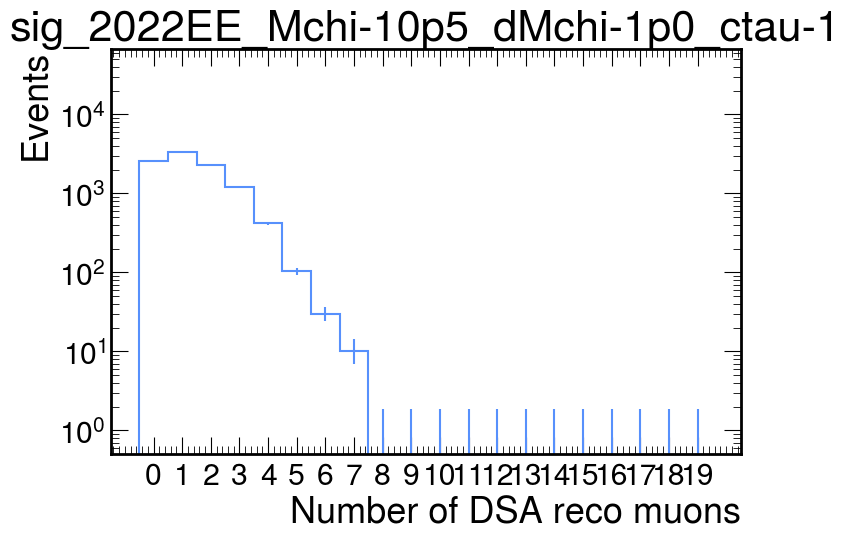

Saved: outputs/muonReco_dsaID_checks/plots/n_dsa_muons_sig_2022EE_Mchi-10p5_dMchi-1p0_ctau-1.png
Saved: outputs/muonReco_dsaID_checks/plots/n_dsa_muons_sig_2022EE_Mchi-10p5_dMchi-1p0_ctau-1.pdf


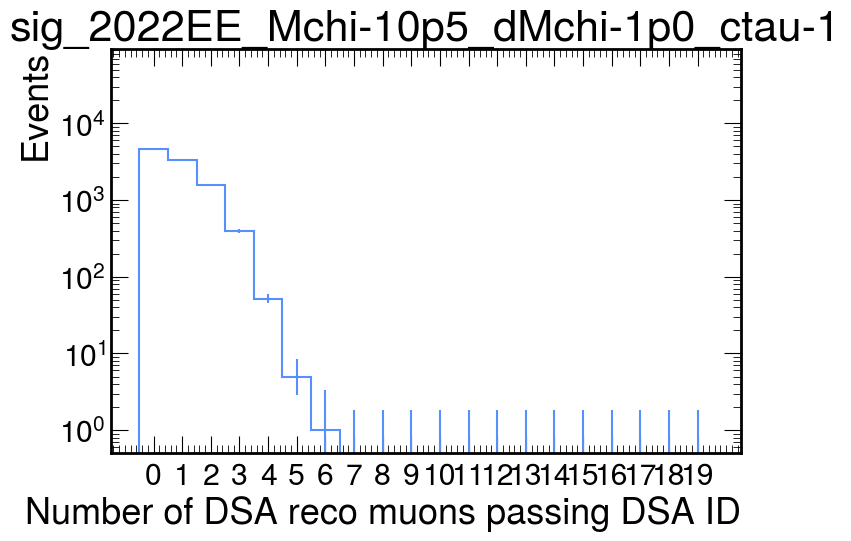

Saved: outputs/muonReco_dsaID_checks/plots/n_dsa_muons_pass_id_sig_2022EE_Mchi-10p5_dMchi-1p0_ctau-1.png
Saved: outputs/muonReco_dsaID_checks/plots/n_dsa_muons_pass_id_sig_2022EE_Mchi-10p5_dMchi-1p0_ctau-1.pdf


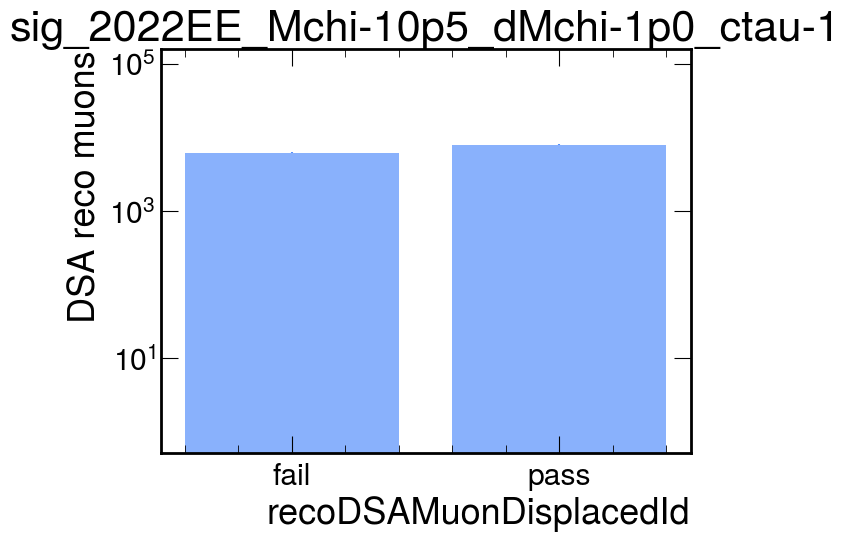

Saved: outputs/muonReco_dsaID_checks/plots/dsa_muon_pass_id_sig_2022EE_Mchi-10p5_dMchi-1p0_ctau-1.png
Saved: outputs/muonReco_dsaID_checks/plots/dsa_muon_pass_id_sig_2022EE_Mchi-10p5_dMchi-1p0_ctau-1.pdf


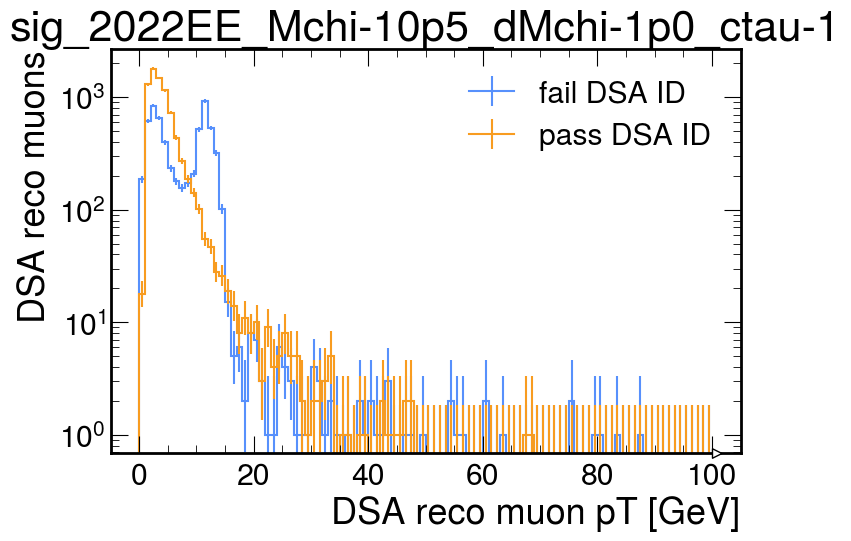

Saved: outputs/muonReco_dsaID_checks/plots/dsa_muon_pt_pass_id_sig_2022EE_Mchi-10p5_dMchi-1p0_ctau-1.png
Saved: outputs/muonReco_dsaID_checks/plots/dsa_muon_pt_pass_id_sig_2022EE_Mchi-10p5_dMchi-1p0_ctau-1.pdf

Done
Coffea file:  outputs/muonReco_dsaID_checks/muonReco_dsaID_checks.coffea
CSV outputs:  outputs/muonReco_dsaID_checks/csv
Plots:        outputs/muonReco_dsaID_checks/plots


In [4]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import coffea.util as util

# Optional but nicer if available
try:
    import mplhep as hep
    hep.style.use("CMS")
    HAS_MPLHEP = True
except Exception:
    HAS_MPLHEP = False

# -----------------------------
# Output directories
# -----------------------------
outdir = "outputs/muonReco_dsaID_checks"
plotdir = f"{outdir}/plots"
csvdir = f"{outdir}/csv"

os.makedirs(plotdir, exist_ok=True)
os.makedirs(csvdir, exist_ok=True)

# -----------------------------
# Run Coffea analyzer
# -----------------------------
t0 = time.time()

ana = Analyzer(
    fileList="configs/sample_configs/signal_2022EE_iDMmu_aEM.json",
    histoList="dummy.py",
    cuts="dummyCuts.py",
    max_samples=1,
    max_files_per_samp=2,
)

out = ana.process(
    treename="ntuples/outT",
    execr="futures",
    workers=4,
    procType="muonReco",
    gen_pt_min=3.0,
    gen_eta_max=2.4,
    reco_pt_min=0.0,
    dr_max=0.1,
    require_dsa_id=False,
)

dt = time.time() - t0

# -----------------------------
# Unwrap coffea output
# -----------------------------
if isinstance(out, tuple):
    histos = out[0]
    metrics = out[1]
else:
    histos = out
    metrics = None

# Save the coffea object too
util.save(histos, f"{outdir}/muonReco_dsaID_checks.coffea")

# -----------------------------
# Check expected histograms
# -----------------------------
expected_hists = [
    "muon_reco_counts",
    "muon_reco_pt",
    "muon_reco_abseta",
    "muon_reco_eta",
    "muon_reco_vxy",
    "muon_reco_vz",
    "n_dsa_muons",
    "n_dsa_muons_pass_id",
    "dsa_muon_pass_id",
    "dsa_muon_pt_pass_id",
]

print("=" * 100)
print("Checking expected histograms")
print("=" * 100)

missing_hists = []
for hname in expected_hists:
    exists = hname in histos
    print(f"{hname:35s} {'OK' if exists else 'MISSING'}")
    if not exists:
        missing_hists.append(hname)

if missing_hists:
    raise RuntimeError(f"Missing histograms: {missing_hists}")

counts_h = histos["muon_reco_counts"]

axis_names = [ax.name for ax in counts_h.axes]
samp_axis = "samp" if "samp" in axis_names else "sample"
quantity_axis = "quantity"

expected_quantities = [
    "n_events",
    "n_events_ge2_gen_mu",
    "n_gen_mu_den",
    "n_prompt_matched",
    "n_dsa_matched",
    "n_either_matched",
    "n_events_both_prompt",
    "n_events_both_dsa",
    "n_events_both_either",
    "n_dsa_reco_muons",
    "n_dsa_reco_muons_pass_id",
    "n_events_with_dsa",
    "n_events_with_dsa_pass_id",
    "n_events_0_dsa",
    "n_events_1_dsa",
    "n_events_ge2_dsa",
    "n_events_0_dsa_pass_id",
    "n_events_1_dsa_pass_id",
    "n_events_ge2_dsa_pass_id",
]

available_quantities = list(counts_h.axes[quantity_axis])

print("\n" + "=" * 100)
print("Checking expected count categories")
print("=" * 100)

missing_quantities = []
for q in expected_quantities:
    exists = q in available_quantities
    print(f"{q:35s} {'OK' if exists else 'MISSING'}")
    if not exists:
        missing_quantities.append(q)

if missing_quantities:
    raise RuntimeError(f"Missing count categories: {missing_quantities}")

# -----------------------------
# Build summary dataframe
# -----------------------------
summary_rows = []
samples = list(counts_h.axes[samp_axis])

for samp in samples:
    vals = {}

    for q in available_quantities:
        vals[q] = float(counts_h[{samp_axis: samp, quantity_axis: q}].value)

    n_events = vals.get("n_events", 0.0)
    n_dsa = vals.get("n_dsa_reco_muons", 0.0)
    n_dsa_pass = vals.get("n_dsa_reco_muons_pass_id", 0.0)

    n_evt_with_dsa = vals.get("n_events_with_dsa", 0.0)
    n_evt_with_dsa_pass = vals.get("n_events_with_dsa_pass_id", 0.0)

    n_gen = vals.get("n_gen_mu_den", 0.0)
    n_prompt_matched = vals.get("n_prompt_matched", 0.0)
    n_dsa_matched = vals.get("n_dsa_matched", 0.0)
    n_either_matched = vals.get("n_either_matched", 0.0)

    row = {
        "sample": samp,
        **vals,
        "dsa_object_id_pass_fraction": n_dsa_pass / n_dsa if n_dsa > 0 else np.nan,
        "dsa_event_id_pass_fraction": n_evt_with_dsa_pass / n_evt_with_dsa if n_evt_with_dsa > 0 else np.nan,
        "frac_events_0_dsa": vals.get("n_events_0_dsa", 0.0) / n_events if n_events > 0 else np.nan,
        "frac_events_1_dsa": vals.get("n_events_1_dsa", 0.0) / n_events if n_events > 0 else np.nan,
        "frac_events_ge2_dsa": vals.get("n_events_ge2_dsa", 0.0) / n_events if n_events > 0 else np.nan,
        "frac_events_0_dsa_pass_id": vals.get("n_events_0_dsa_pass_id", 0.0) / n_events if n_events > 0 else np.nan,
        "frac_events_1_dsa_pass_id": vals.get("n_events_1_dsa_pass_id", 0.0) / n_events if n_events > 0 else np.nan,
        "frac_events_ge2_dsa_pass_id": vals.get("n_events_ge2_dsa_pass_id", 0.0) / n_events if n_events > 0 else np.nan,
        "prompt_muon_reco_eff": n_prompt_matched / n_gen if n_gen > 0 else np.nan,
        "dsa_muon_reco_eff": n_dsa_matched / n_gen if n_gen > 0 else np.nan,
        "either_muon_reco_eff": n_either_matched / n_gen if n_gen > 0 else np.nan,
    }

    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)

summary_csv = f"{csvdir}/muonReco_dsaID_summary.csv"
summary_df.to_csv(summary_csv, index=False)

print("\n" + "=" * 100)
print("DSA-ID summary")
print("=" * 100)
print(summary_df.to_string(index=False))

print("\n" + "=" * 100)
print("Run summary")
print("=" * 100)
print(f"Processed events: {int(summary_df['n_events'].sum())}")
print(f"Time taken:       {dt:.2f} s = {dt/60:.2f} min")
print(f"Saved summary CSV: {summary_csv}")

# -----------------------------
# Helper plotting functions
# -----------------------------
def savefig(path):
    plt.tight_layout()
    plt.savefig(path, dpi=200)
    plt.savefig(path.replace(".png", ".pdf"))
    plt.show()
    print(f"Saved: {path}")
    print(f"Saved: {path.replace('.png', '.pdf')}")


def get_values_and_edges(h1d):
    values = h1d.values()
    variances = h1d.variances()
    errors = np.sqrt(variances) if variances is not None else np.sqrt(values)
    edges = h1d.axes[0].edges
    centers = 0.5 * (edges[:-1] + edges[1:])
    return np.asarray(values), np.asarray(errors), np.asarray(edges), np.asarray(centers)


def get_category_values(h1d):
    values = h1d.values()
    variances = h1d.variances()
    errors = np.sqrt(variances) if variances is not None else np.sqrt(values)
    cats = list(h1d.axes[0])
    return cats, np.asarray(values), np.asarray(errors)


def export_1d_numeric_hist_to_csv(h, hist_name, axis_name, csv_path):
    rows = []

    for samp in h.axes[samp_axis]:
        h_s = h[{samp_axis: samp}]
        values, errors, edges, centers = get_values_and_edges(h_s)

        for i in range(len(values)):
            rows.append({
                "sample": samp,
                "histogram": hist_name,
                "axis": axis_name,
                "bin": i,
                "bin_low": edges[i],
                "bin_high": edges[i + 1],
                "bin_center": centers[i],
                "value": values[i],
                "error": errors[i],
            })

    df = pd.DataFrame(rows)
    df.to_csv(csv_path, index=False)
    print(f"Saved CSV: {csv_path}")
    return df


def export_1d_category_hist_to_csv(h, hist_name, axis_name, csv_path):
    rows = []

    for samp in h.axes[samp_axis]:
        h_s = h[{samp_axis: samp}]
        cats, values, errors = get_category_values(h_s)

        for i, cat in enumerate(cats):
            rows.append({
                "sample": samp,
                "histogram": hist_name,
                "axis": axis_name,
                "category": cat,
                "value": values[i],
                "error": errors[i],
            })

    df = pd.DataFrame(rows)
    df.to_csv(csv_path, index=False)
    print(f"Saved CSV: {csv_path}")
    return df


def plot_numeric_hist_per_sample(h, hist_name, xlabel, ylabel, logy=True):
    for samp in h.axes[samp_axis]:
        h_s = h[{samp_axis: samp}]
        values, errors, edges, centers = get_values_and_edges(h_s)

        plt.figure(figsize=(8, 6))

        if HAS_MPLHEP:
            hep.histplot(h_s, yerr=True)
        else:
            widths = np.diff(edges)
            plt.bar(centers, values, width=widths, align="center", alpha=0.7)
            plt.errorbar(centers, values, yerr=errors, fmt="none")

        if logy:
            plt.yscale("log")
            ymax = max(np.max(values), 1.0)
            plt.ylim(0.5, ymax * 20)

        plt.xlabel(xlabel)
        plt.ylabel(ylabel)
        plt.title(samp)

        safe_samp = str(samp).replace("/", "_").replace(" ", "_")
        savefig(f"{plotdir}/{hist_name}_{safe_samp}.png")


def plot_category_hist_per_sample(h, hist_name, xlabel, ylabel, logy=True, category_labels=None):
    for samp in h.axes[samp_axis]:
        h_s = h[{samp_axis: samp}]
        cats, values, errors = get_category_values(h_s)

        x = np.arange(len(cats))

        plt.figure(figsize=(7, 6))
        plt.bar(x, values, alpha=0.7)
        plt.errorbar(x, values, yerr=errors, fmt="none")

        if category_labels is None:
            labels = [str(c) for c in cats]
        else:
            labels = [category_labels.get(c, str(c)) for c in cats]

        plt.xticks(x, labels)

        if logy:
            plt.yscale("log")
            ymax = max(np.max(values), 1.0)
            plt.ylim(0.5, ymax * 20)

        plt.xlabel(xlabel)
        plt.ylabel(ylabel)
        plt.title(samp)

        safe_samp = str(samp).replace("/", "_").replace(" ", "_")
        savefig(f"{plotdir}/{hist_name}_{safe_samp}.png")


# -----------------------------
# Export histogram contents to CSV
# -----------------------------
n_dsa_df = export_1d_numeric_hist_to_csv(
    histos["n_dsa_muons"],
    hist_name="n_dsa_muons",
    axis_name="n_dsa",
    csv_path=f"{csvdir}/n_dsa_muons_bins.csv",
)

n_dsa_pass_df = export_1d_numeric_hist_to_csv(
    histos["n_dsa_muons_pass_id"],
    hist_name="n_dsa_muons_pass_id",
    axis_name="n_dsa_pass_id",
    csv_path=f"{csvdir}/n_dsa_muons_pass_id_bins.csv",
)

dsa_pass_id_df = export_1d_category_hist_to_csv(
    histos["dsa_muon_pass_id"],
    hist_name="dsa_muon_pass_id",
    axis_name="pass_id",
    csv_path=f"{csvdir}/dsa_muon_pass_id_bins.csv",
)

# Export pT split by pass/fail
pt_rows = []
h_pt = histos["dsa_muon_pt_pass_id"]

for samp in h_pt.axes[samp_axis]:
    for pass_id in h_pt.axes["pass_id"]:
        h_s = h_pt[{samp_axis: samp, "pass_id": pass_id}]
        values, errors, edges, centers = get_values_and_edges(h_s)

        for i in range(len(values)):
            pt_rows.append({
                "sample": samp,
                "pass_id": pass_id,
                "bin": i,
                "pt_low": edges[i],
                "pt_high": edges[i + 1],
                "pt_center": centers[i],
                "value": values[i],
                "error": errors[i],
            })

dsa_pt_df = pd.DataFrame(pt_rows)
dsa_pt_csv = f"{csvdir}/dsa_muon_pt_pass_id_bins.csv"
dsa_pt_df.to_csv(dsa_pt_csv, index=False)
print(f"Saved CSV: {dsa_pt_csv}")

# -----------------------------
# Save plots
# -----------------------------
plot_numeric_hist_per_sample(
    histos["n_dsa_muons"],
    hist_name="n_dsa_muons",
    xlabel="Number of DSA reco muons",
    ylabel="Events",
    logy=True,
)

plot_numeric_hist_per_sample(
    histos["n_dsa_muons_pass_id"],
    hist_name="n_dsa_muons_pass_id",
    xlabel="Number of DSA reco muons passing DSA ID",
    ylabel="Events",
    logy=True,
)

plot_category_hist_per_sample(
    histos["dsa_muon_pass_id"],
    hist_name="dsa_muon_pass_id",
    xlabel="recoDSAMuonDisplacedId",
    ylabel="DSA reco muons",
    logy=True,
    category_labels={0: "fail", 1: "pass"},
)

# DSA pT pass/fail overlay
h = histos["dsa_muon_pt_pass_id"]

for samp in h.axes[samp_axis]:
    safe_samp = str(samp).replace("/", "_").replace(" ", "_")

    plt.figure(figsize=(8, 6))

    h_fail = h[{samp_axis: samp, "pass_id": 0}]
    h_pass = h[{samp_axis: samp, "pass_id": 1}]

    if HAS_MPLHEP:
        hep.histplot([h_fail, h_pass], label=["fail DSA ID", "pass DSA ID"], yerr=True)
    else:
        for h_s, label in [(h_fail, "fail DSA ID"), (h_pass, "pass DSA ID")]:
            values, errors, edges, centers = get_values_and_edges(h_s)
            plt.step(edges[:-1], values, where="post", label=label)
            plt.errorbar(centers, values, yerr=errors, fmt="none")

    plt.yscale("log")
    plt.xlabel("DSA reco muon pT [GeV]")
    plt.ylabel("DSA reco muons")
    plt.title(samp)
    plt.legend()

    savefig(f"{plotdir}/dsa_muon_pt_pass_id_{safe_samp}.png")

print("\n" + "=" * 100)
print("Done")
print("=" * 100)
print(f"Coffea file:  {outdir}/muonReco_dsaID_checks.coffea")
print(f"CSV outputs:  {csvdir}")
print(f"Plots:        {plotdir}")
print("=" * 100)

Output()

Output()

Checking expected histograms
muon_reco_counts                    OK
muon_reco_pt                        OK
muon_reco_abseta                    OK
muon_reco_eta                       OK
muon_reco_vxy                       OK
muon_reco_vz                        OK
n_dsa_muons                         OK
n_dsa_muons_pass_id                 OK
dsa_muon_pass_id                    OK
dsa_muon_pt_pass_id                 OK

Checking expected count categories
n_events                            OK
n_events_ge2_gen_mu                 OK
n_gen_mu_den                        OK
n_prompt_matched                    OK
n_dsa_matched                       OK
n_either_matched                    OK
n_events_both_prompt                OK
n_events_both_dsa                   OK
n_events_both_either                OK
n_dsa_reco_muons                    OK
n_dsa_reco_muons_pass_id            OK
n_events_with_dsa                   OK
n_events_with_dsa_pass_id           OK
n_events_0_dsa                      OK

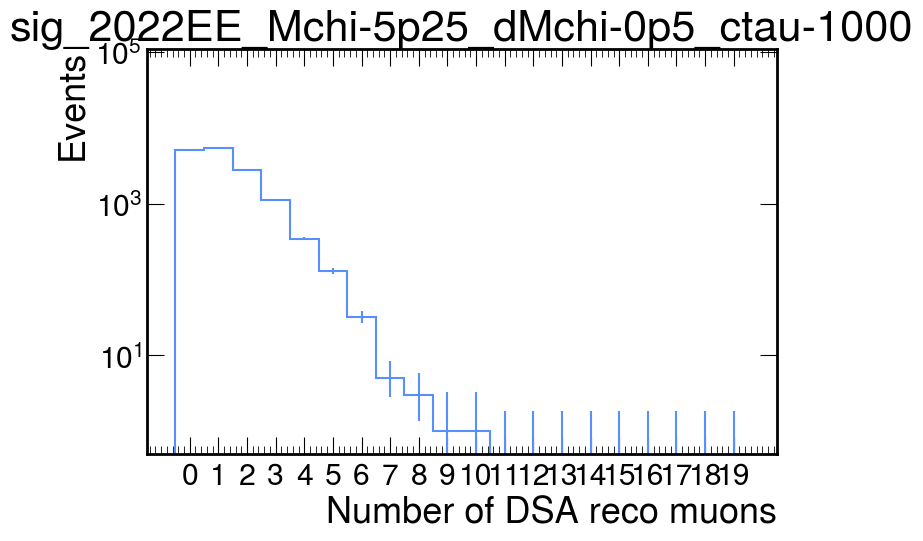

Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/n_dsa_muons_sig_2022EE_Mchi-5p25_dMchi-0p5_ctau-1000.png
Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/n_dsa_muons_sig_2022EE_Mchi-5p25_dMchi-0p5_ctau-1000.pdf


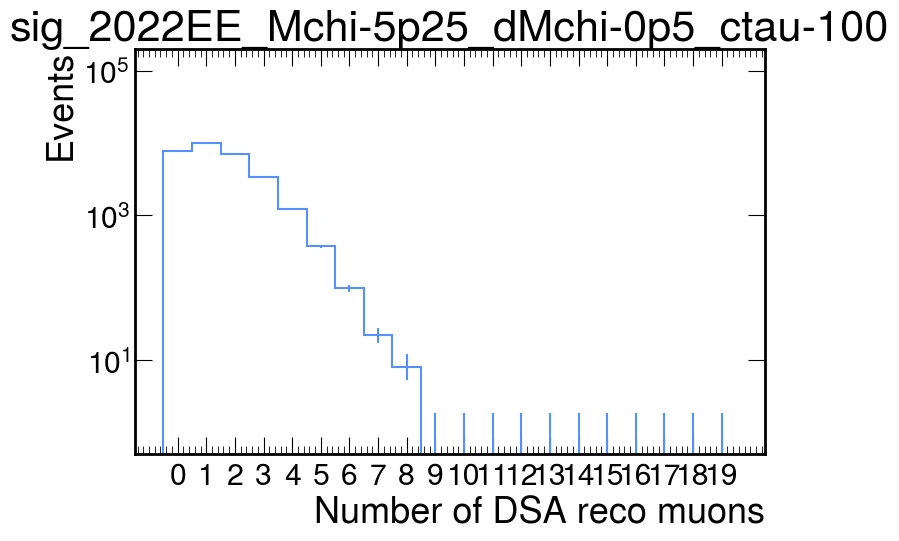

Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/n_dsa_muons_sig_2022EE_Mchi-5p25_dMchi-0p5_ctau-100.png
Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/n_dsa_muons_sig_2022EE_Mchi-5p25_dMchi-0p5_ctau-100.pdf


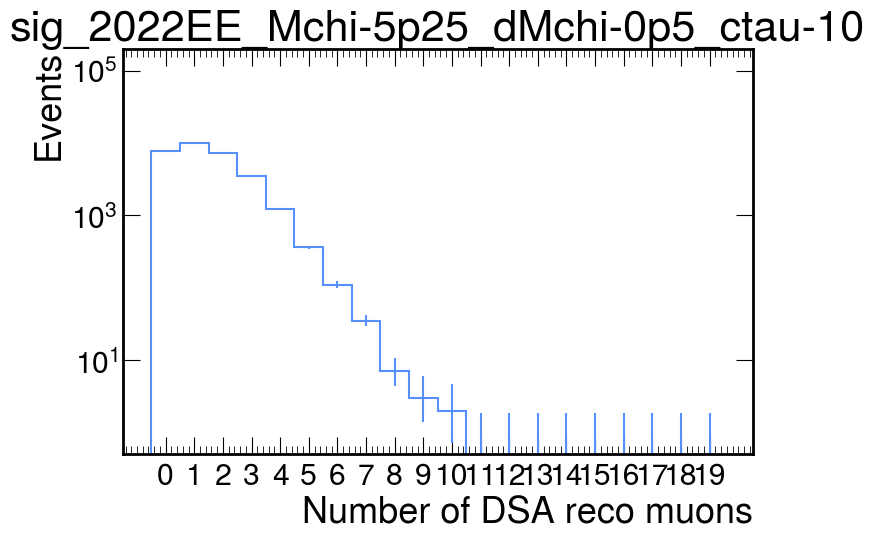

Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/n_dsa_muons_sig_2022EE_Mchi-5p25_dMchi-0p5_ctau-10.png
Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/n_dsa_muons_sig_2022EE_Mchi-5p25_dMchi-0p5_ctau-10.pdf


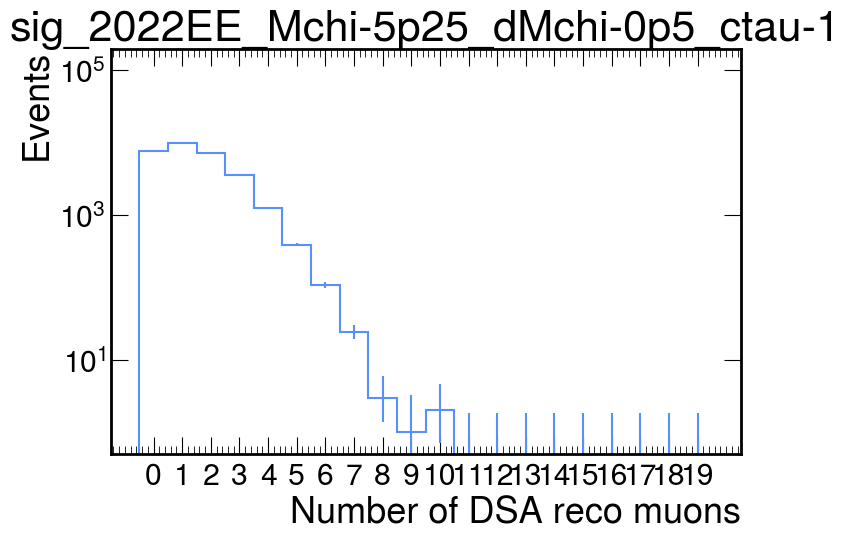

Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/n_dsa_muons_sig_2022EE_Mchi-5p25_dMchi-0p5_ctau-1.png
Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/n_dsa_muons_sig_2022EE_Mchi-5p25_dMchi-0p5_ctau-1.pdf


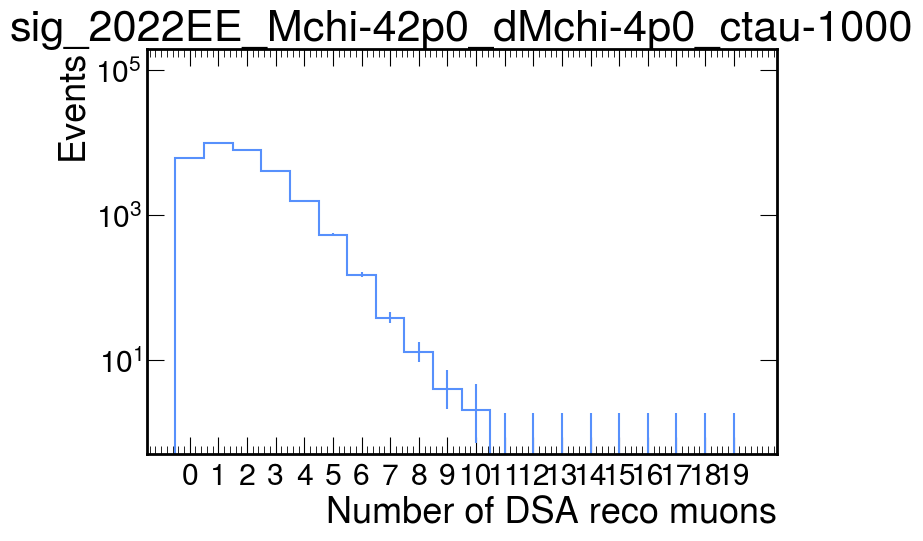

Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/n_dsa_muons_sig_2022EE_Mchi-42p0_dMchi-4p0_ctau-1000.png
Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/n_dsa_muons_sig_2022EE_Mchi-42p0_dMchi-4p0_ctau-1000.pdf


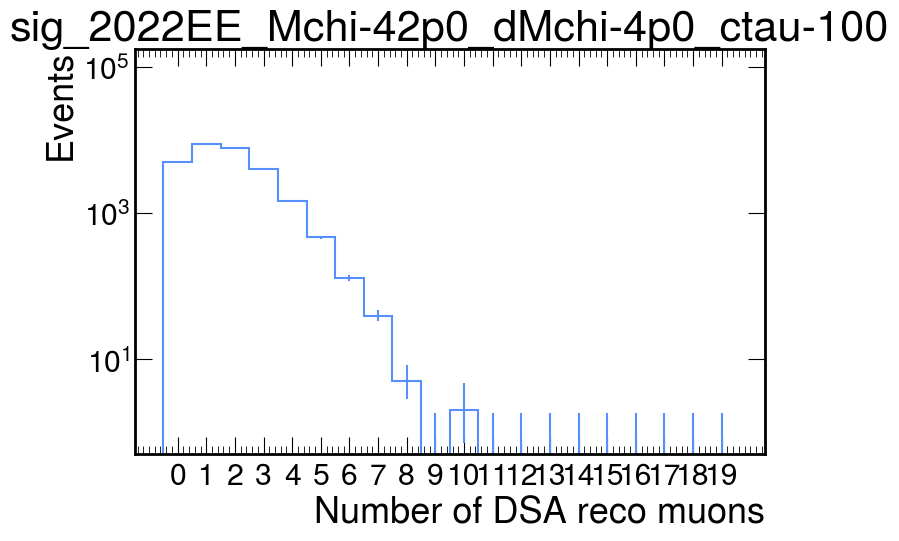

Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/n_dsa_muons_sig_2022EE_Mchi-42p0_dMchi-4p0_ctau-100.png
Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/n_dsa_muons_sig_2022EE_Mchi-42p0_dMchi-4p0_ctau-100.pdf


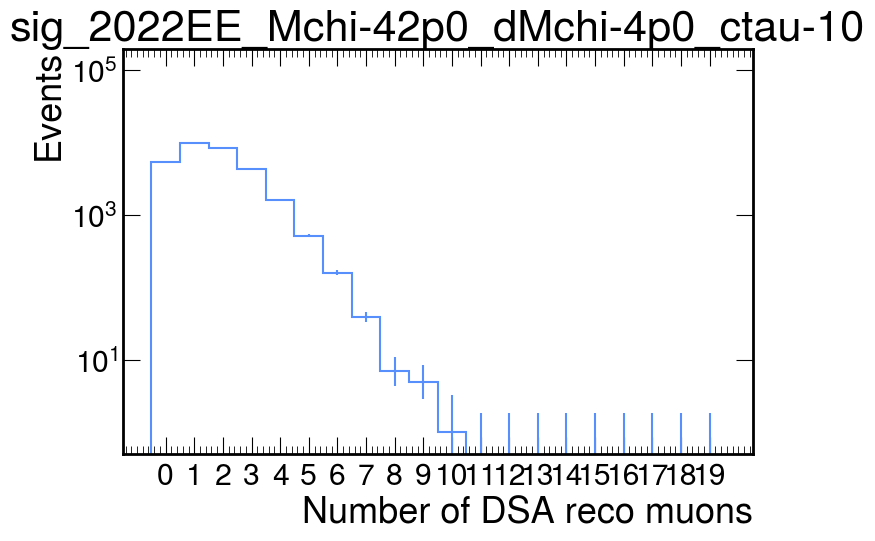

Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/n_dsa_muons_sig_2022EE_Mchi-42p0_dMchi-4p0_ctau-10.png
Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/n_dsa_muons_sig_2022EE_Mchi-42p0_dMchi-4p0_ctau-10.pdf


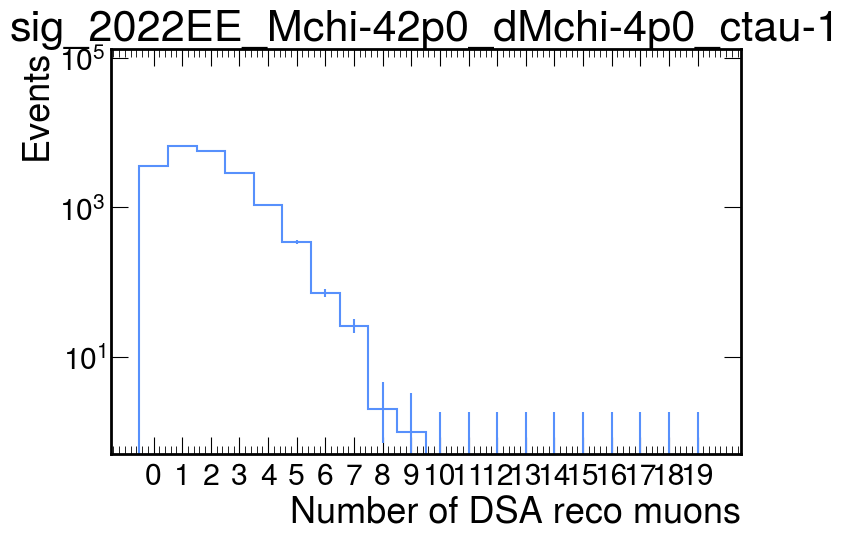

Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/n_dsa_muons_sig_2022EE_Mchi-42p0_dMchi-4p0_ctau-1.png
Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/n_dsa_muons_sig_2022EE_Mchi-42p0_dMchi-4p0_ctau-1.pdf


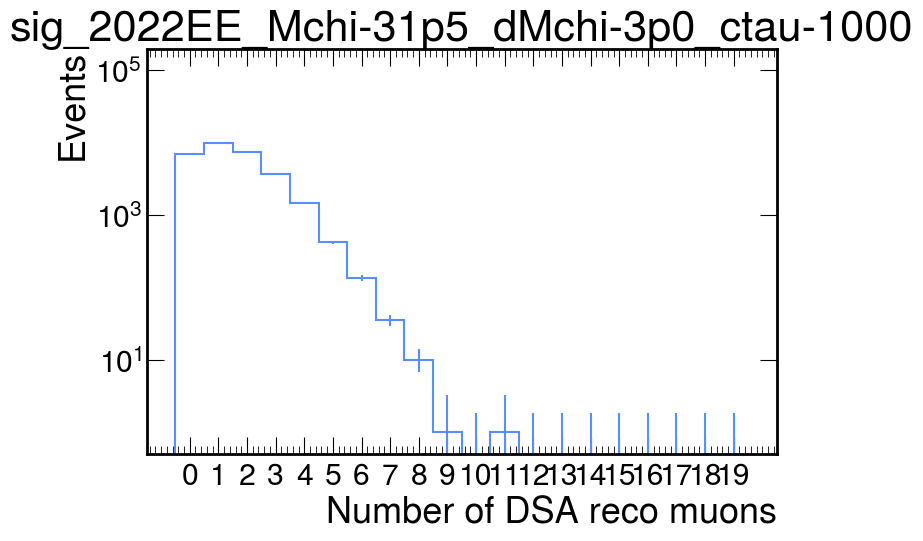

Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/n_dsa_muons_sig_2022EE_Mchi-31p5_dMchi-3p0_ctau-1000.png
Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/n_dsa_muons_sig_2022EE_Mchi-31p5_dMchi-3p0_ctau-1000.pdf


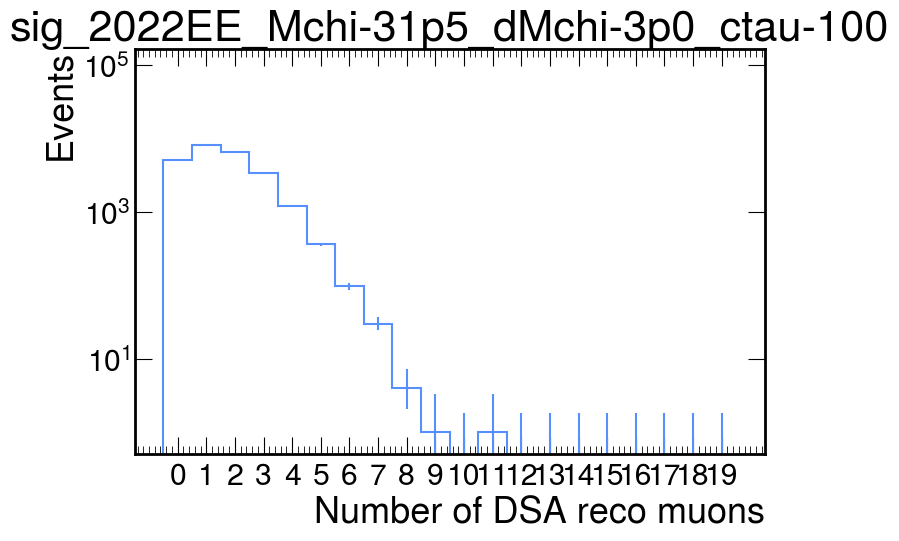

Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/n_dsa_muons_sig_2022EE_Mchi-31p5_dMchi-3p0_ctau-100.png
Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/n_dsa_muons_sig_2022EE_Mchi-31p5_dMchi-3p0_ctau-100.pdf


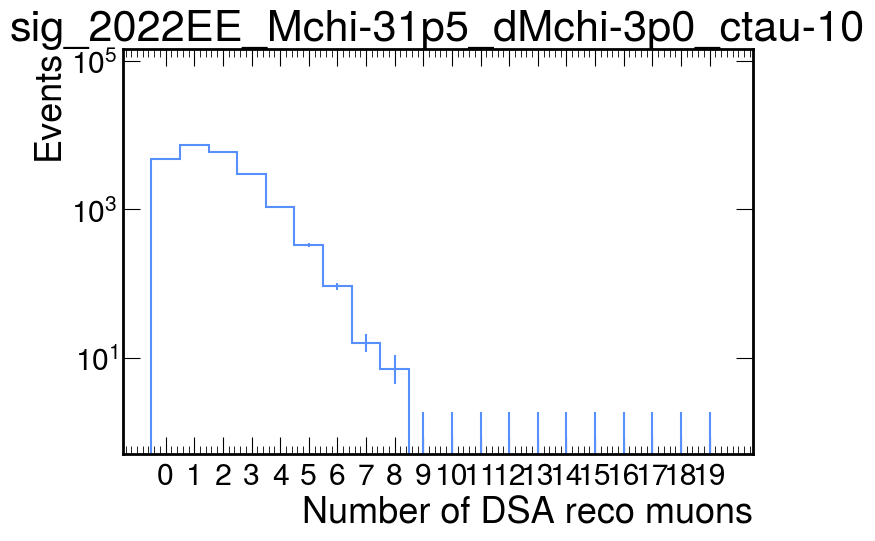

Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/n_dsa_muons_sig_2022EE_Mchi-31p5_dMchi-3p0_ctau-10.png
Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/n_dsa_muons_sig_2022EE_Mchi-31p5_dMchi-3p0_ctau-10.pdf


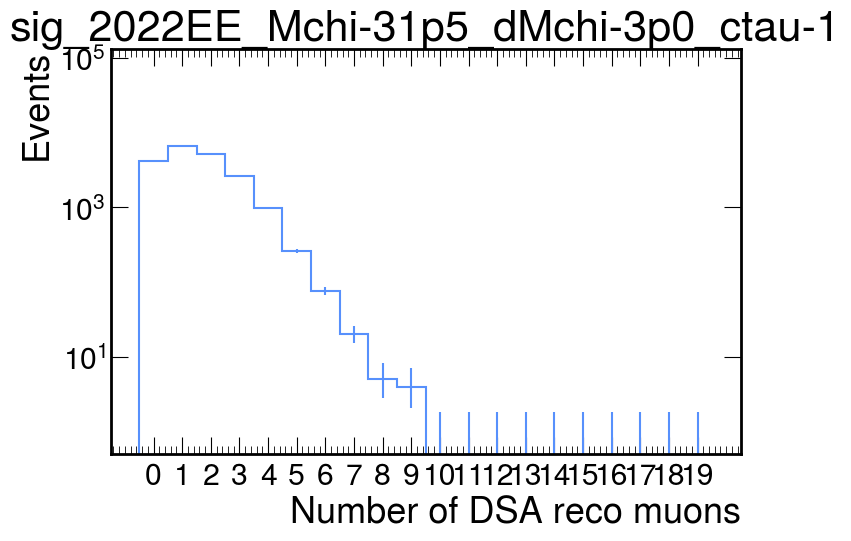

Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/n_dsa_muons_sig_2022EE_Mchi-31p5_dMchi-3p0_ctau-1.png
Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/n_dsa_muons_sig_2022EE_Mchi-31p5_dMchi-3p0_ctau-1.pdf


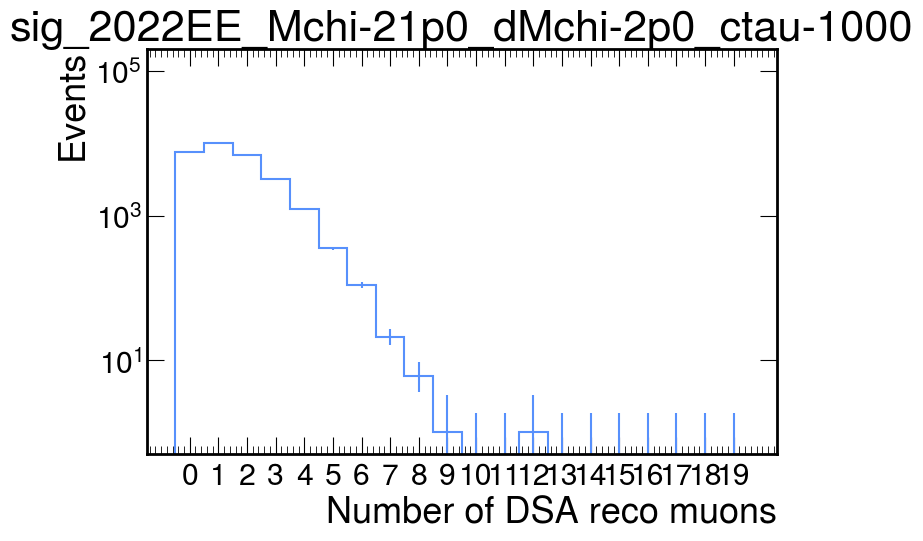

Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/n_dsa_muons_sig_2022EE_Mchi-21p0_dMchi-2p0_ctau-1000.png
Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/n_dsa_muons_sig_2022EE_Mchi-21p0_dMchi-2p0_ctau-1000.pdf


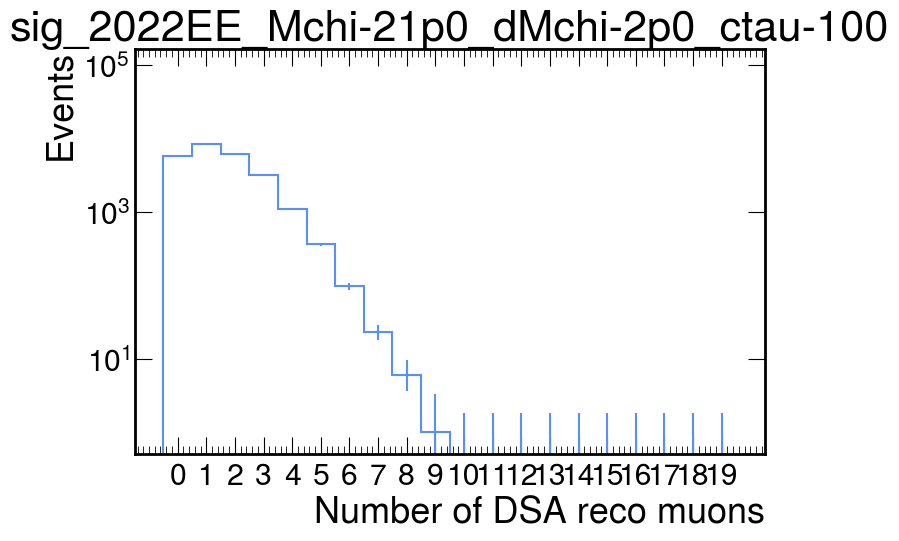

Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/n_dsa_muons_sig_2022EE_Mchi-21p0_dMchi-2p0_ctau-100.png
Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/n_dsa_muons_sig_2022EE_Mchi-21p0_dMchi-2p0_ctau-100.pdf


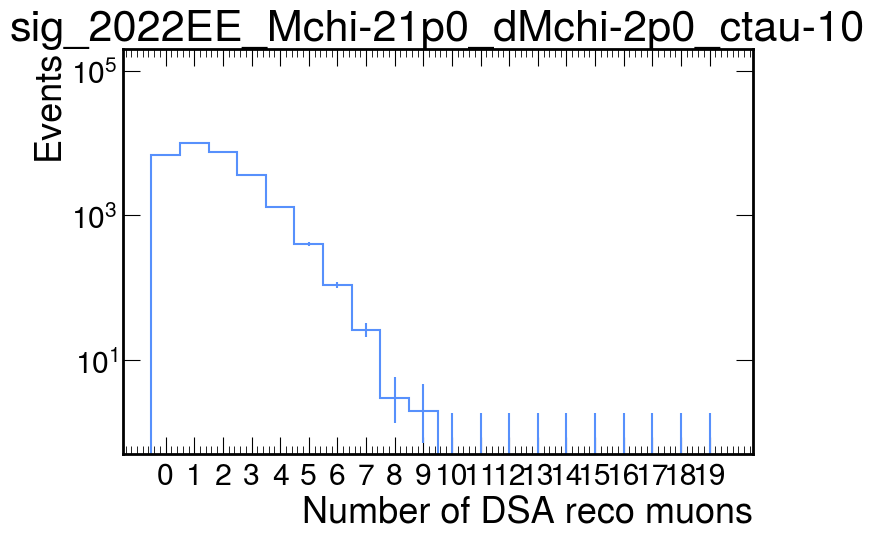

Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/n_dsa_muons_sig_2022EE_Mchi-21p0_dMchi-2p0_ctau-10.png
Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/n_dsa_muons_sig_2022EE_Mchi-21p0_dMchi-2p0_ctau-10.pdf


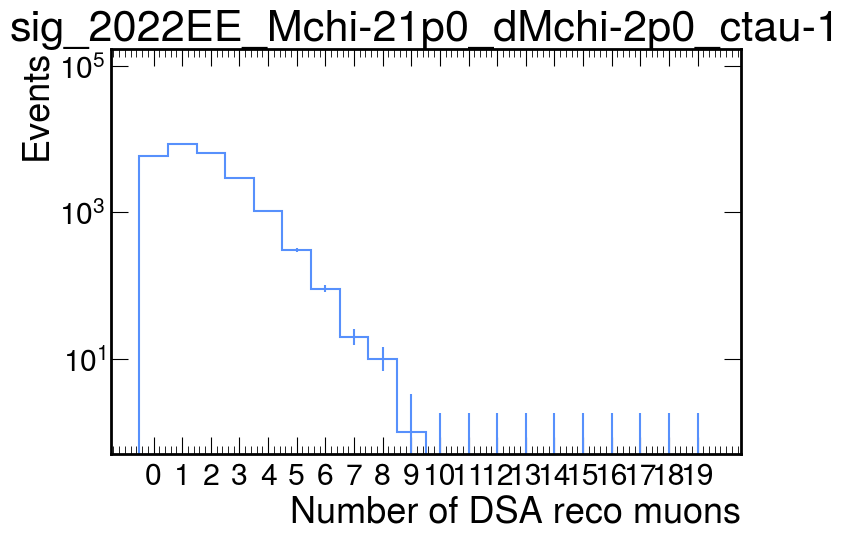

Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/n_dsa_muons_sig_2022EE_Mchi-21p0_dMchi-2p0_ctau-1.png
Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/n_dsa_muons_sig_2022EE_Mchi-21p0_dMchi-2p0_ctau-1.pdf


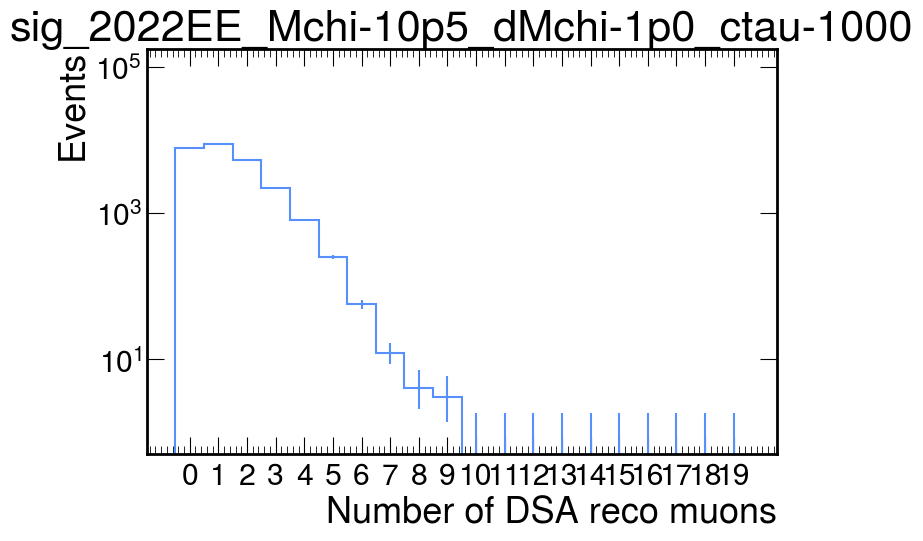

Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/n_dsa_muons_sig_2022EE_Mchi-10p5_dMchi-1p0_ctau-1000.png
Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/n_dsa_muons_sig_2022EE_Mchi-10p5_dMchi-1p0_ctau-1000.pdf


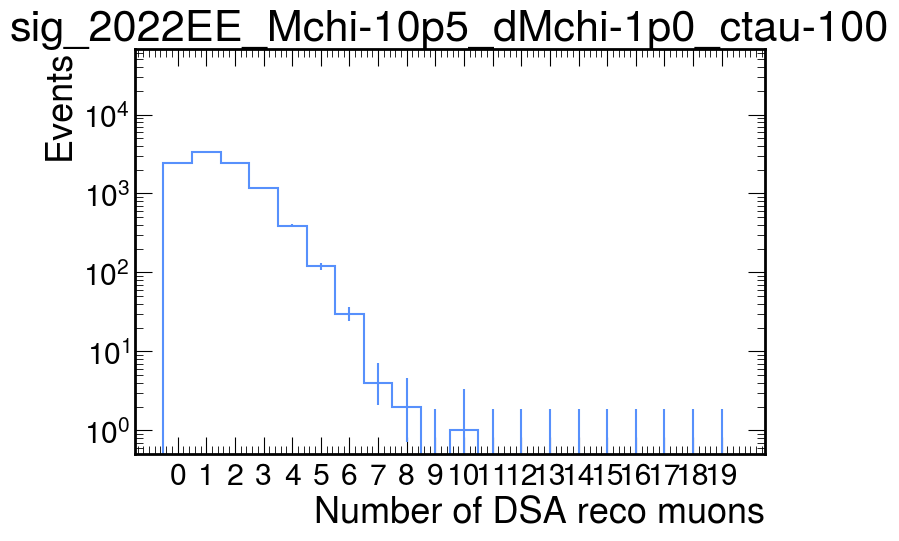

Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/n_dsa_muons_sig_2022EE_Mchi-10p5_dMchi-1p0_ctau-100.png
Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/n_dsa_muons_sig_2022EE_Mchi-10p5_dMchi-1p0_ctau-100.pdf


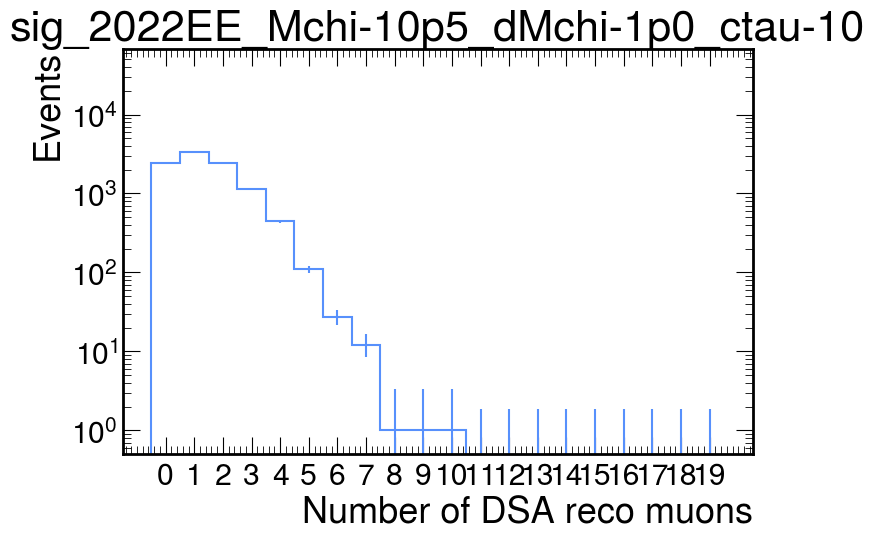

Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/n_dsa_muons_sig_2022EE_Mchi-10p5_dMchi-1p0_ctau-10.png
Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/n_dsa_muons_sig_2022EE_Mchi-10p5_dMchi-1p0_ctau-10.pdf


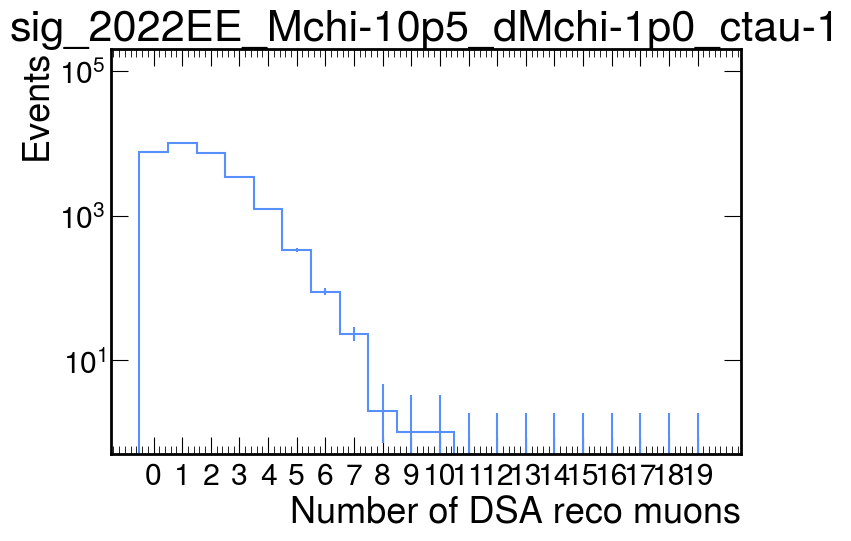

Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/n_dsa_muons_sig_2022EE_Mchi-10p5_dMchi-1p0_ctau-1.png
Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/n_dsa_muons_sig_2022EE_Mchi-10p5_dMchi-1p0_ctau-1.pdf


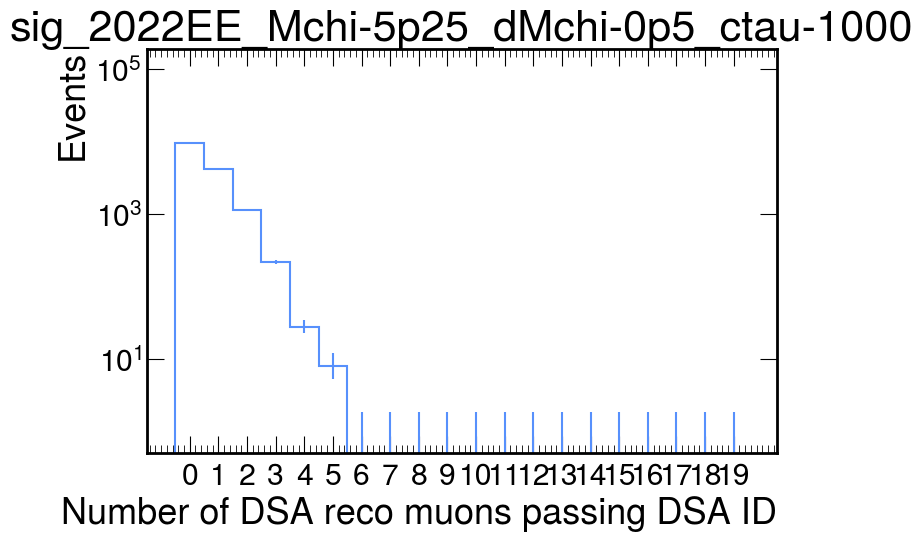

Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/n_dsa_muons_pass_id_sig_2022EE_Mchi-5p25_dMchi-0p5_ctau-1000.png
Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/n_dsa_muons_pass_id_sig_2022EE_Mchi-5p25_dMchi-0p5_ctau-1000.pdf


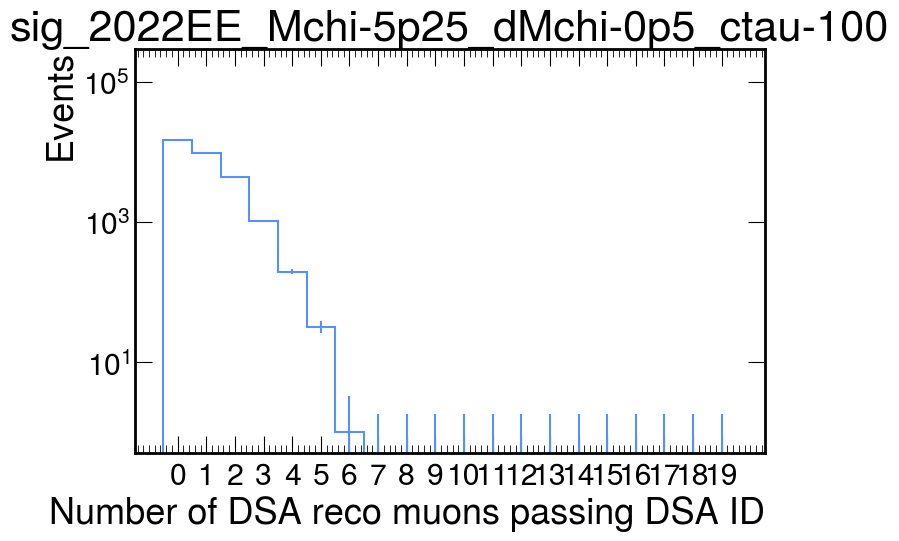

Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/n_dsa_muons_pass_id_sig_2022EE_Mchi-5p25_dMchi-0p5_ctau-100.png
Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/n_dsa_muons_pass_id_sig_2022EE_Mchi-5p25_dMchi-0p5_ctau-100.pdf


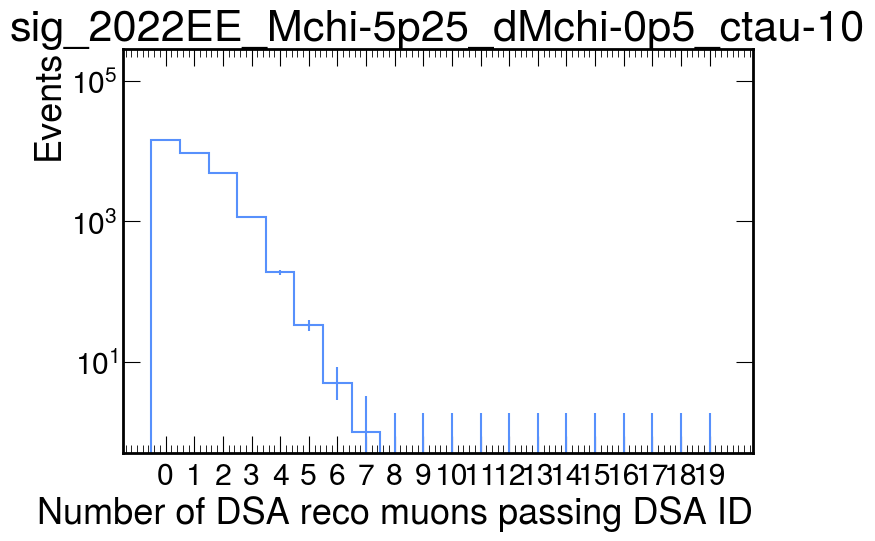

Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/n_dsa_muons_pass_id_sig_2022EE_Mchi-5p25_dMchi-0p5_ctau-10.png
Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/n_dsa_muons_pass_id_sig_2022EE_Mchi-5p25_dMchi-0p5_ctau-10.pdf


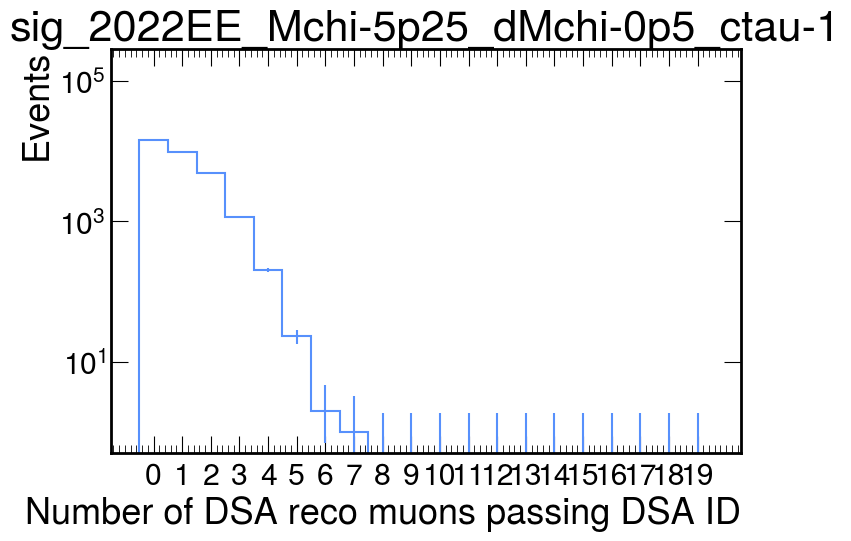

Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/n_dsa_muons_pass_id_sig_2022EE_Mchi-5p25_dMchi-0p5_ctau-1.png
Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/n_dsa_muons_pass_id_sig_2022EE_Mchi-5p25_dMchi-0p5_ctau-1.pdf


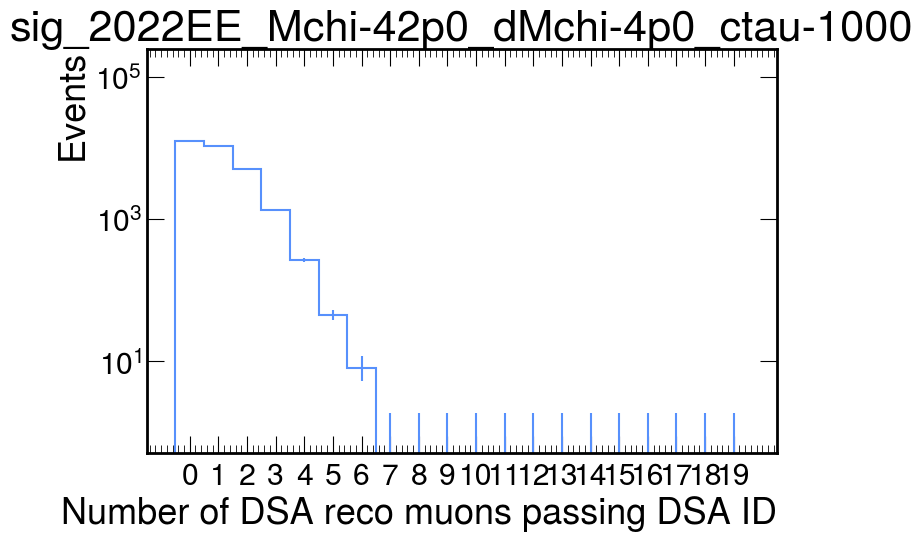

Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/n_dsa_muons_pass_id_sig_2022EE_Mchi-42p0_dMchi-4p0_ctau-1000.png
Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/n_dsa_muons_pass_id_sig_2022EE_Mchi-42p0_dMchi-4p0_ctau-1000.pdf


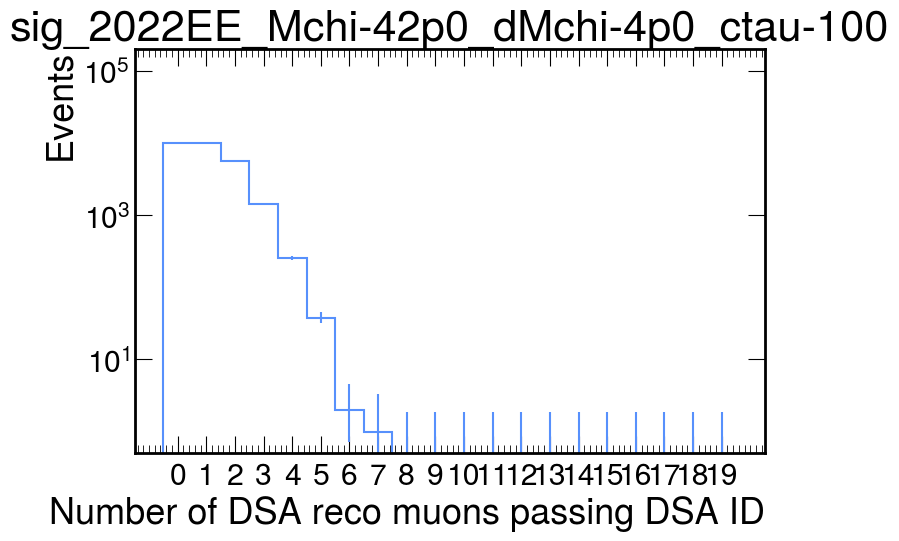

Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/n_dsa_muons_pass_id_sig_2022EE_Mchi-42p0_dMchi-4p0_ctau-100.png
Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/n_dsa_muons_pass_id_sig_2022EE_Mchi-42p0_dMchi-4p0_ctau-100.pdf


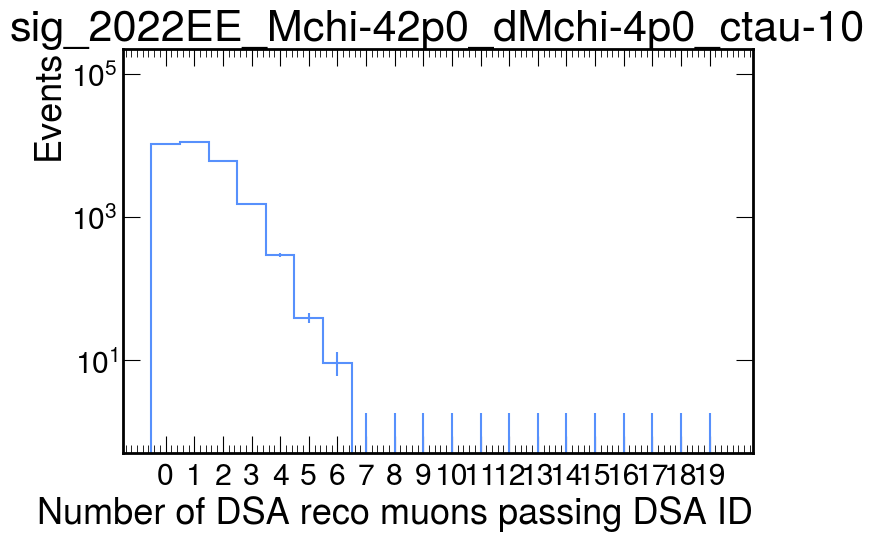

Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/n_dsa_muons_pass_id_sig_2022EE_Mchi-42p0_dMchi-4p0_ctau-10.png
Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/n_dsa_muons_pass_id_sig_2022EE_Mchi-42p0_dMchi-4p0_ctau-10.pdf


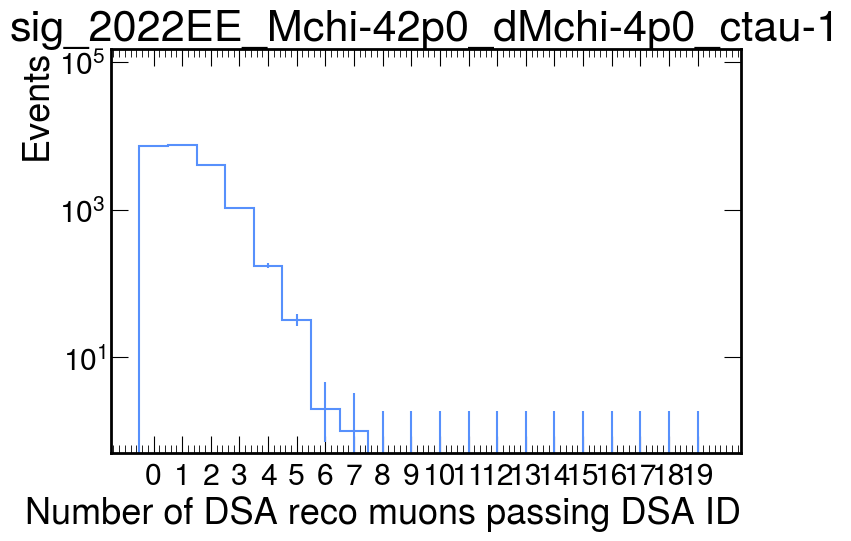

Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/n_dsa_muons_pass_id_sig_2022EE_Mchi-42p0_dMchi-4p0_ctau-1.png
Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/n_dsa_muons_pass_id_sig_2022EE_Mchi-42p0_dMchi-4p0_ctau-1.pdf


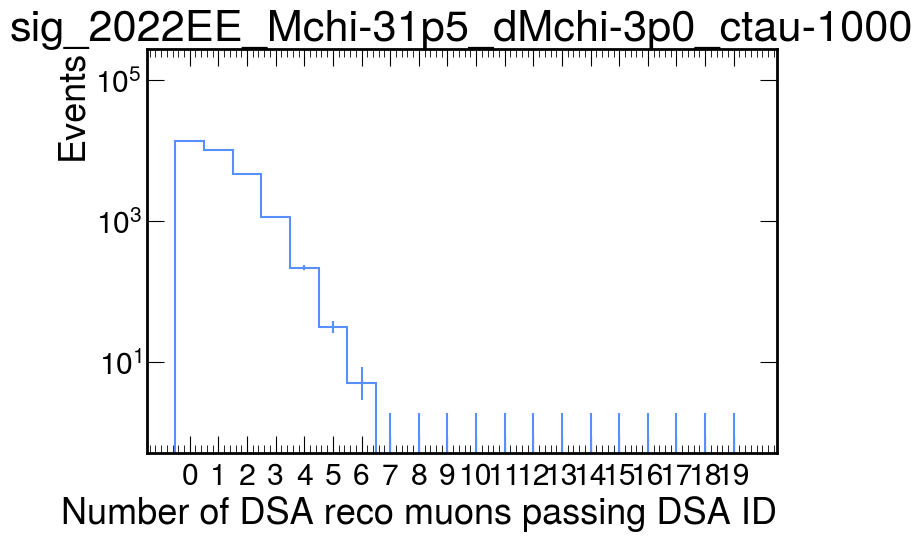

Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/n_dsa_muons_pass_id_sig_2022EE_Mchi-31p5_dMchi-3p0_ctau-1000.png
Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/n_dsa_muons_pass_id_sig_2022EE_Mchi-31p5_dMchi-3p0_ctau-1000.pdf


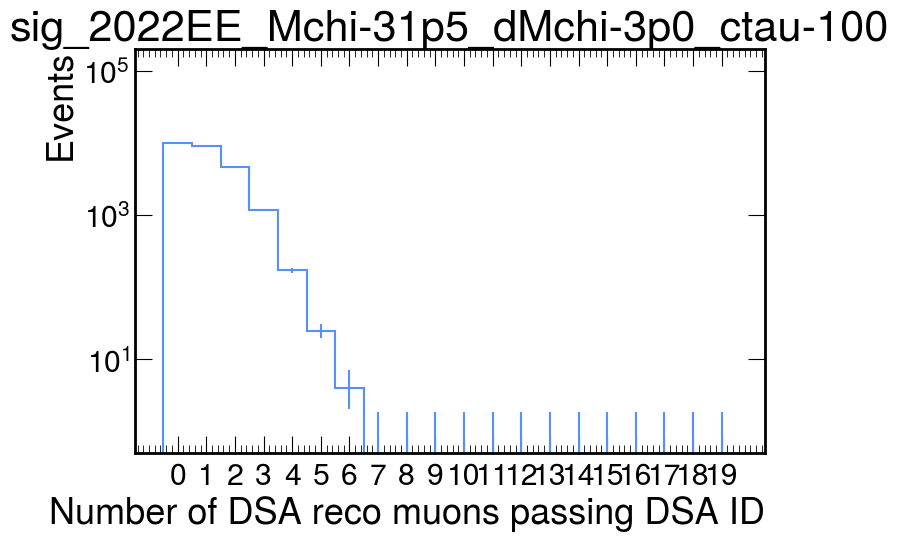

Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/n_dsa_muons_pass_id_sig_2022EE_Mchi-31p5_dMchi-3p0_ctau-100.png
Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/n_dsa_muons_pass_id_sig_2022EE_Mchi-31p5_dMchi-3p0_ctau-100.pdf


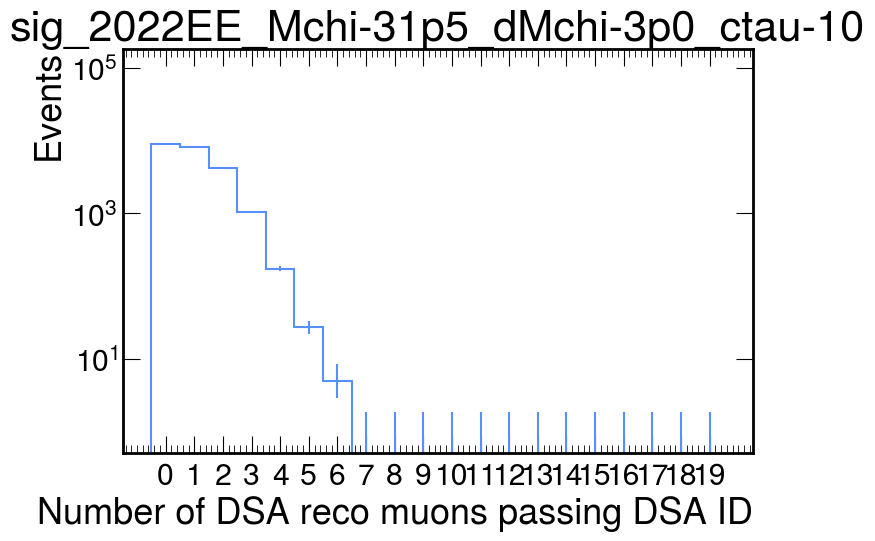

Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/n_dsa_muons_pass_id_sig_2022EE_Mchi-31p5_dMchi-3p0_ctau-10.png
Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/n_dsa_muons_pass_id_sig_2022EE_Mchi-31p5_dMchi-3p0_ctau-10.pdf


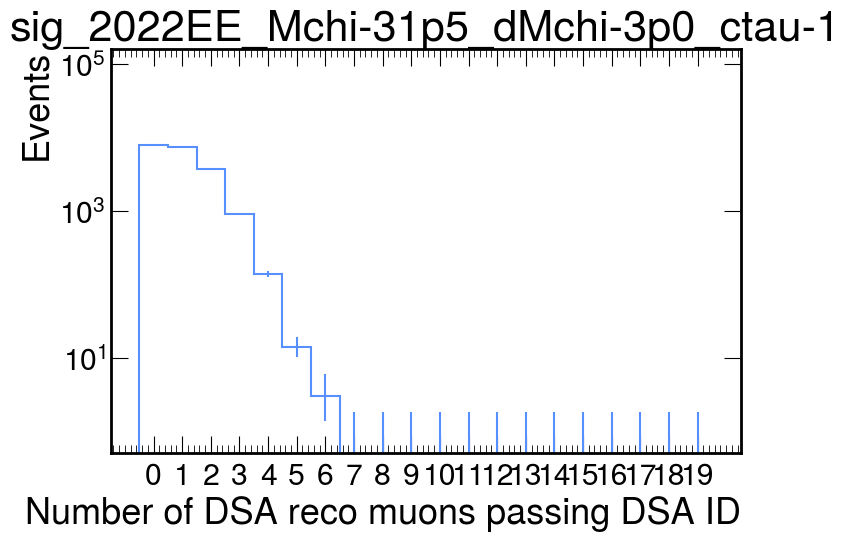

Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/n_dsa_muons_pass_id_sig_2022EE_Mchi-31p5_dMchi-3p0_ctau-1.png
Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/n_dsa_muons_pass_id_sig_2022EE_Mchi-31p5_dMchi-3p0_ctau-1.pdf


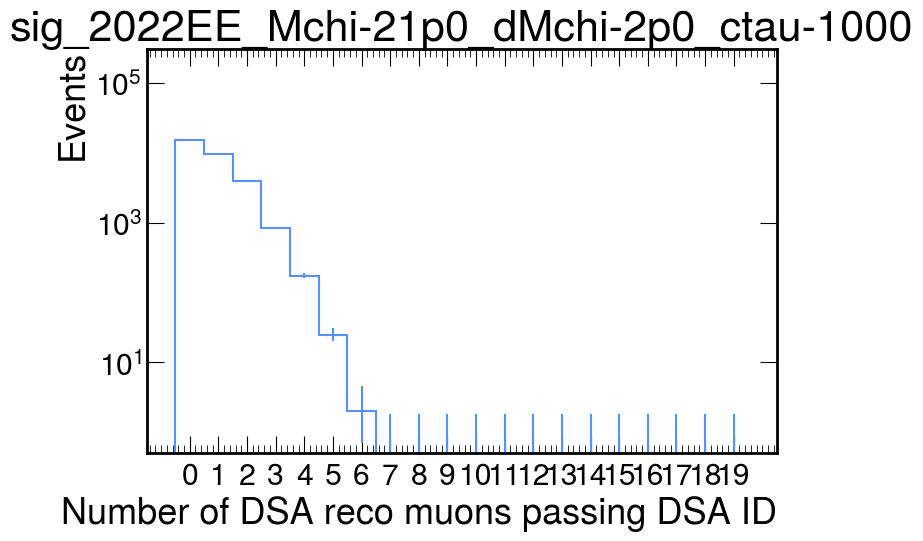

Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/n_dsa_muons_pass_id_sig_2022EE_Mchi-21p0_dMchi-2p0_ctau-1000.png
Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/n_dsa_muons_pass_id_sig_2022EE_Mchi-21p0_dMchi-2p0_ctau-1000.pdf


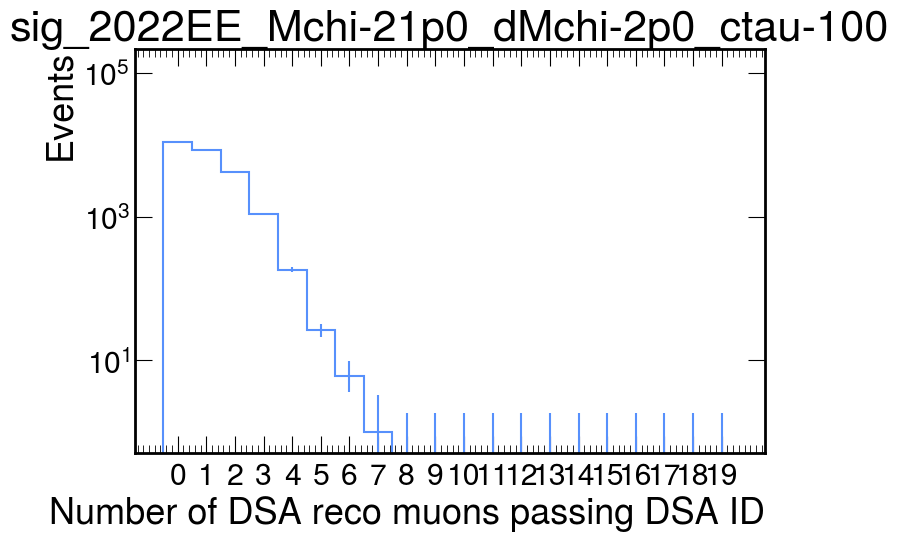

Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/n_dsa_muons_pass_id_sig_2022EE_Mchi-21p0_dMchi-2p0_ctau-100.png
Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/n_dsa_muons_pass_id_sig_2022EE_Mchi-21p0_dMchi-2p0_ctau-100.pdf


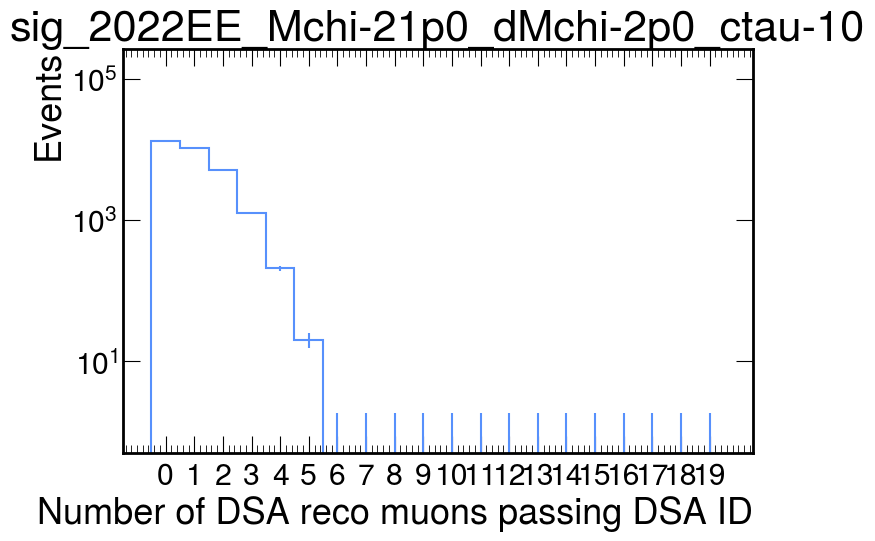

Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/n_dsa_muons_pass_id_sig_2022EE_Mchi-21p0_dMchi-2p0_ctau-10.png
Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/n_dsa_muons_pass_id_sig_2022EE_Mchi-21p0_dMchi-2p0_ctau-10.pdf


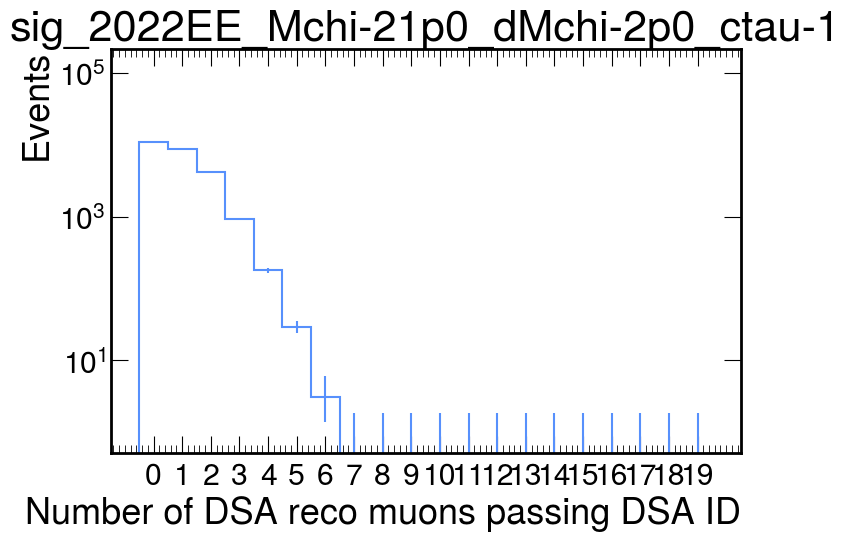

Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/n_dsa_muons_pass_id_sig_2022EE_Mchi-21p0_dMchi-2p0_ctau-1.png
Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/n_dsa_muons_pass_id_sig_2022EE_Mchi-21p0_dMchi-2p0_ctau-1.pdf


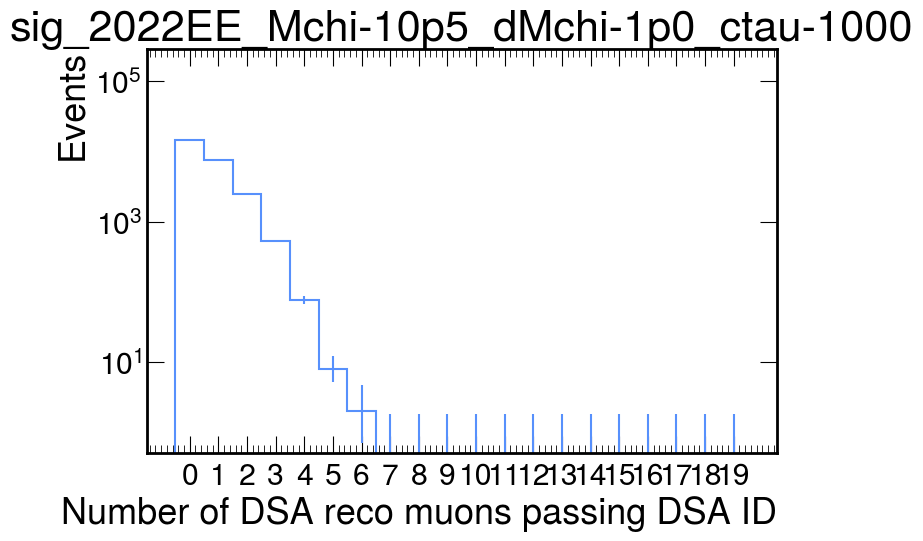

Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/n_dsa_muons_pass_id_sig_2022EE_Mchi-10p5_dMchi-1p0_ctau-1000.png
Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/n_dsa_muons_pass_id_sig_2022EE_Mchi-10p5_dMchi-1p0_ctau-1000.pdf


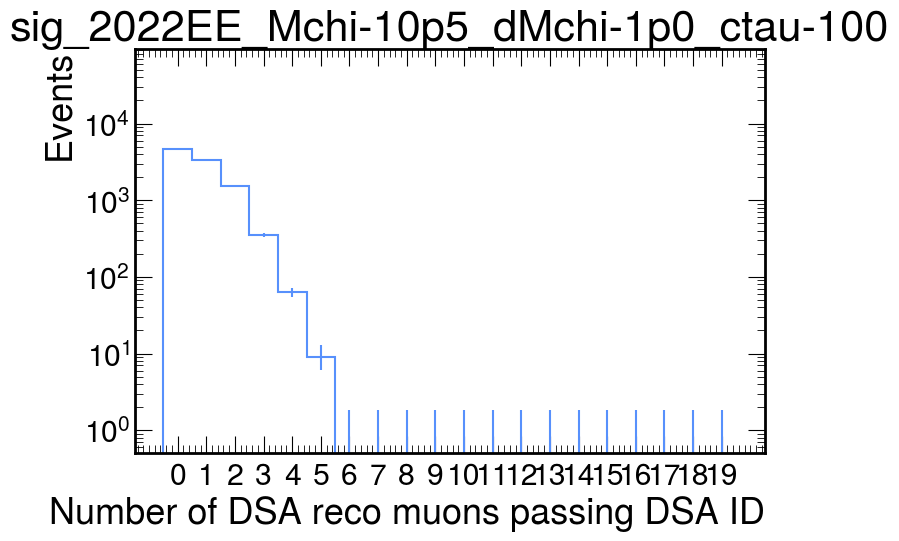

Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/n_dsa_muons_pass_id_sig_2022EE_Mchi-10p5_dMchi-1p0_ctau-100.png
Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/n_dsa_muons_pass_id_sig_2022EE_Mchi-10p5_dMchi-1p0_ctau-100.pdf


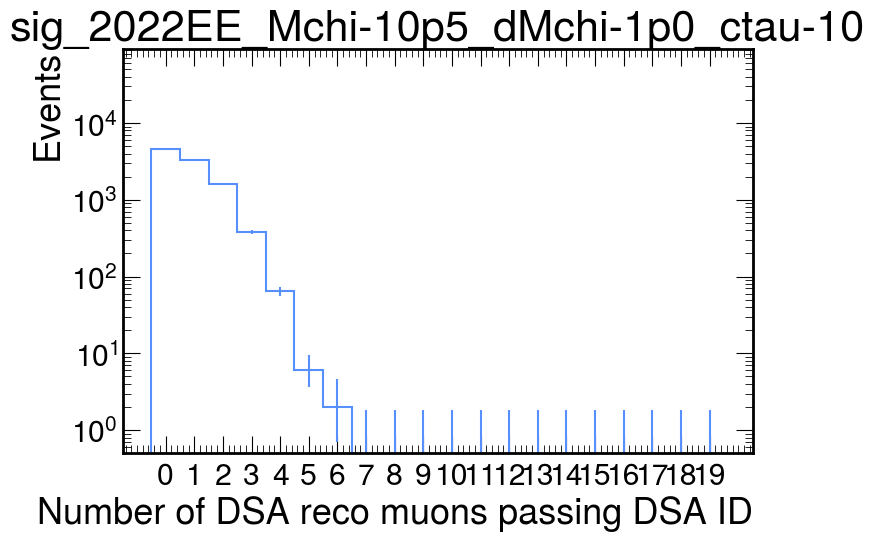

Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/n_dsa_muons_pass_id_sig_2022EE_Mchi-10p5_dMchi-1p0_ctau-10.png
Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/n_dsa_muons_pass_id_sig_2022EE_Mchi-10p5_dMchi-1p0_ctau-10.pdf


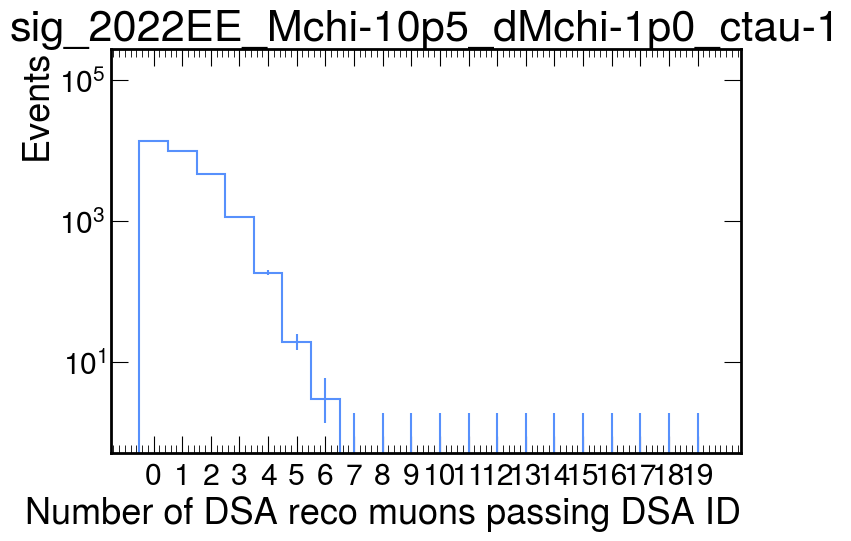

Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/n_dsa_muons_pass_id_sig_2022EE_Mchi-10p5_dMchi-1p0_ctau-1.png
Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/n_dsa_muons_pass_id_sig_2022EE_Mchi-10p5_dMchi-1p0_ctau-1.pdf


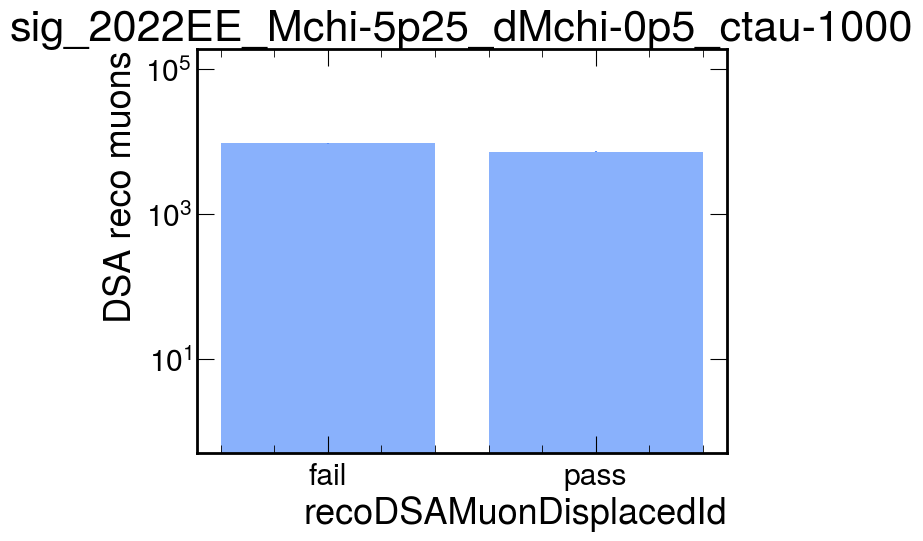

Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/dsa_muon_pass_id_sig_2022EE_Mchi-5p25_dMchi-0p5_ctau-1000.png
Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/dsa_muon_pass_id_sig_2022EE_Mchi-5p25_dMchi-0p5_ctau-1000.pdf


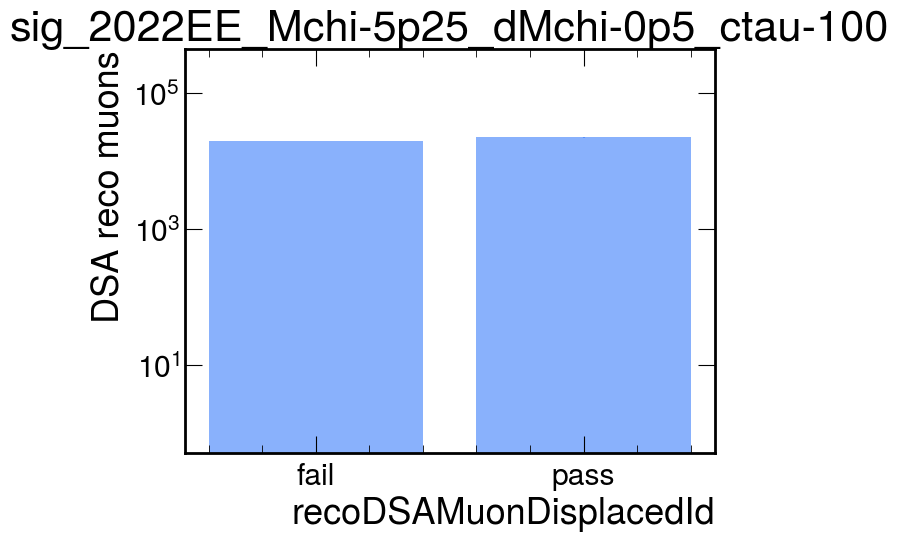

Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/dsa_muon_pass_id_sig_2022EE_Mchi-5p25_dMchi-0p5_ctau-100.png
Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/dsa_muon_pass_id_sig_2022EE_Mchi-5p25_dMchi-0p5_ctau-100.pdf


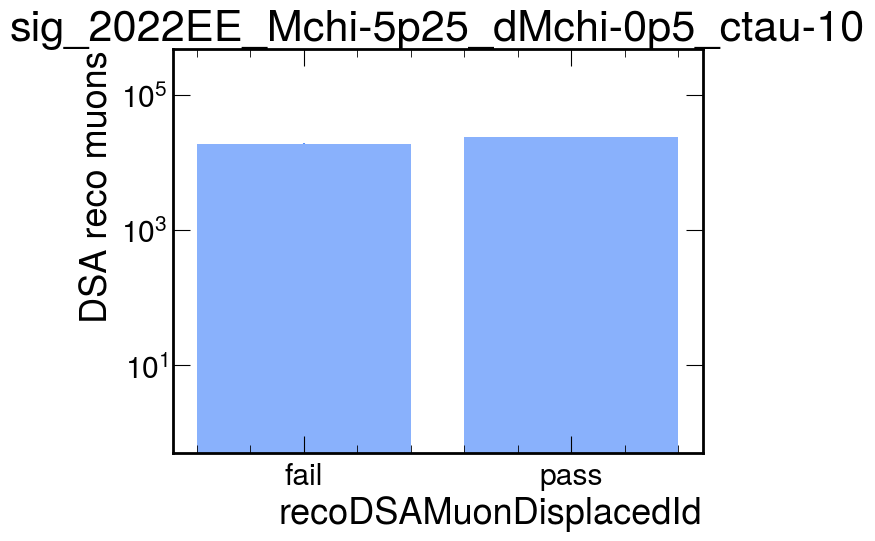

Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/dsa_muon_pass_id_sig_2022EE_Mchi-5p25_dMchi-0p5_ctau-10.png
Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/dsa_muon_pass_id_sig_2022EE_Mchi-5p25_dMchi-0p5_ctau-10.pdf


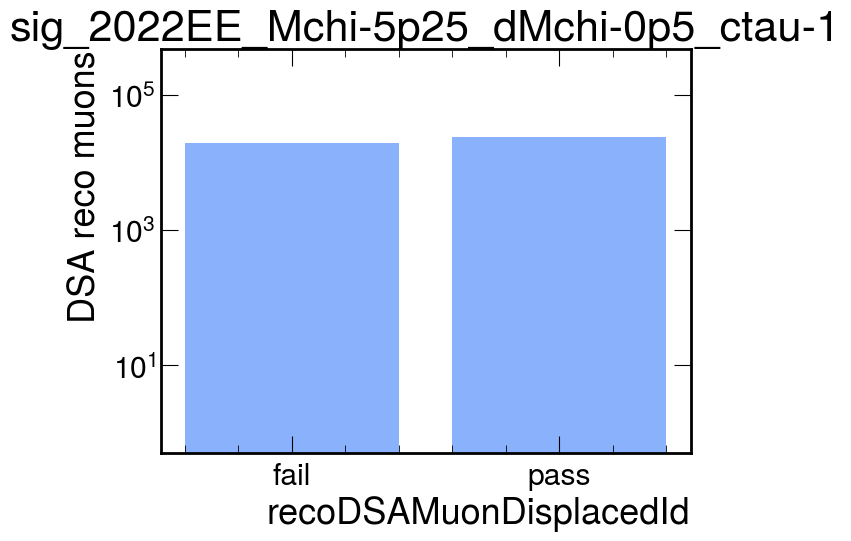

Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/dsa_muon_pass_id_sig_2022EE_Mchi-5p25_dMchi-0p5_ctau-1.png
Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/dsa_muon_pass_id_sig_2022EE_Mchi-5p25_dMchi-0p5_ctau-1.pdf


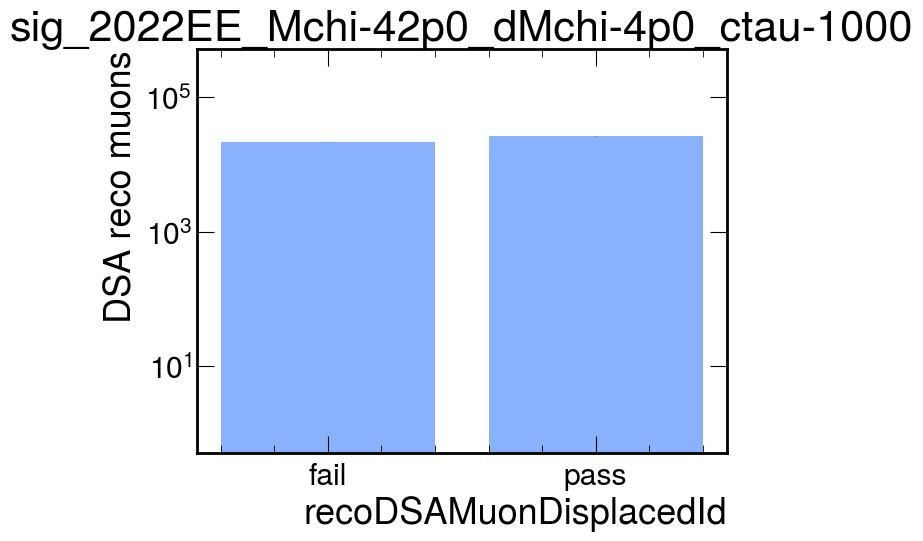

Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/dsa_muon_pass_id_sig_2022EE_Mchi-42p0_dMchi-4p0_ctau-1000.png
Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/dsa_muon_pass_id_sig_2022EE_Mchi-42p0_dMchi-4p0_ctau-1000.pdf


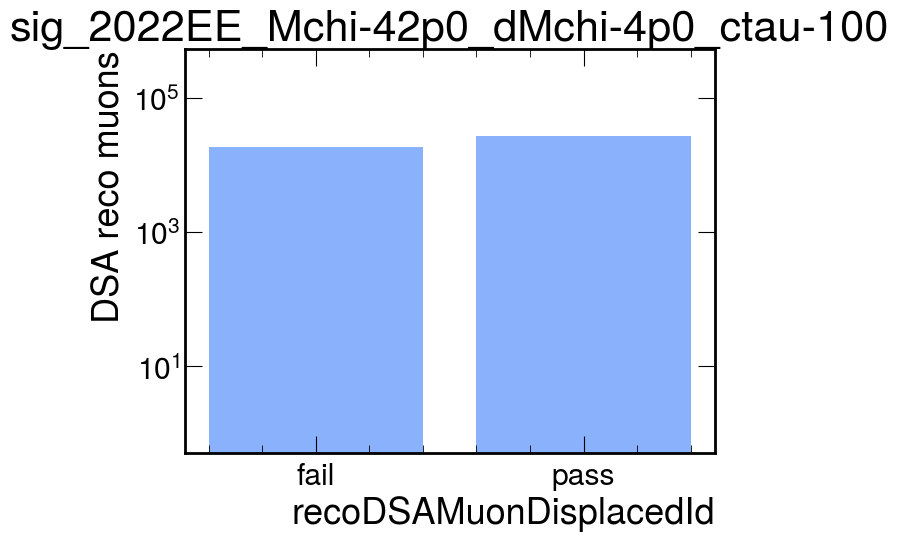

Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/dsa_muon_pass_id_sig_2022EE_Mchi-42p0_dMchi-4p0_ctau-100.png
Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/dsa_muon_pass_id_sig_2022EE_Mchi-42p0_dMchi-4p0_ctau-100.pdf


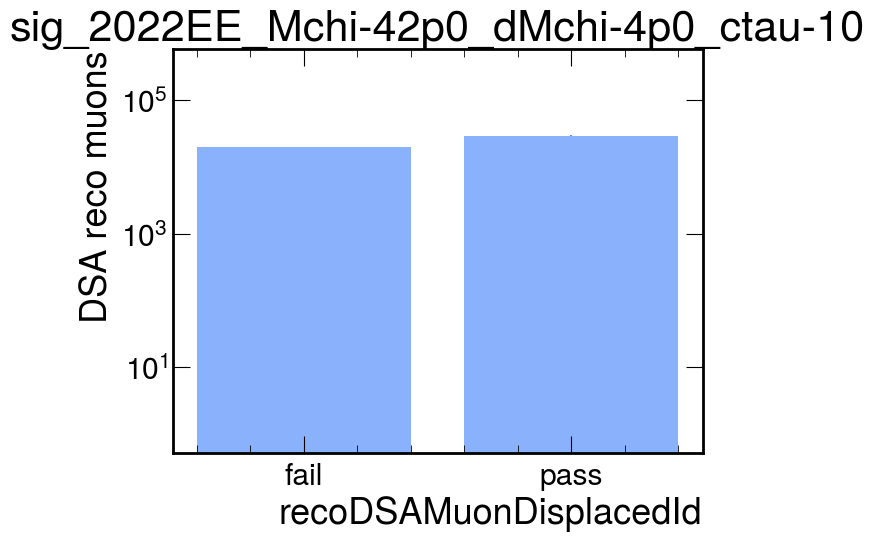

Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/dsa_muon_pass_id_sig_2022EE_Mchi-42p0_dMchi-4p0_ctau-10.png
Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/dsa_muon_pass_id_sig_2022EE_Mchi-42p0_dMchi-4p0_ctau-10.pdf


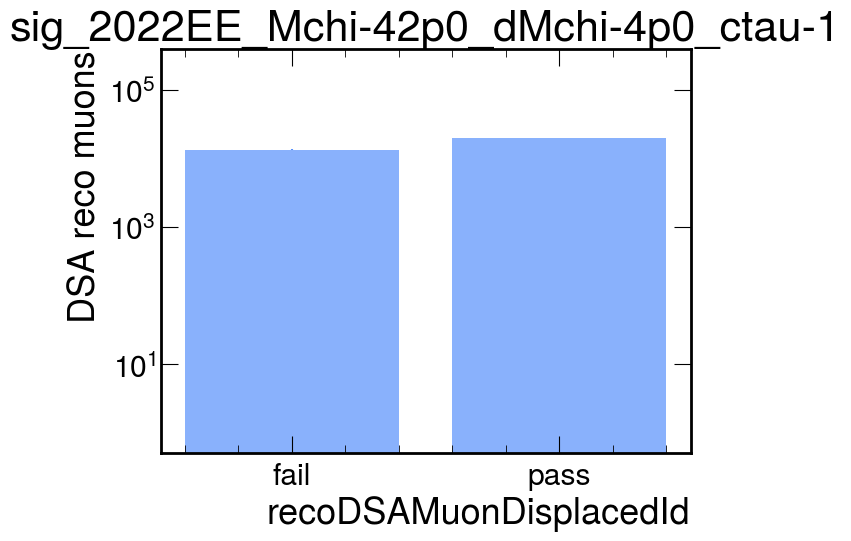

Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/dsa_muon_pass_id_sig_2022EE_Mchi-42p0_dMchi-4p0_ctau-1.png
Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/dsa_muon_pass_id_sig_2022EE_Mchi-42p0_dMchi-4p0_ctau-1.pdf


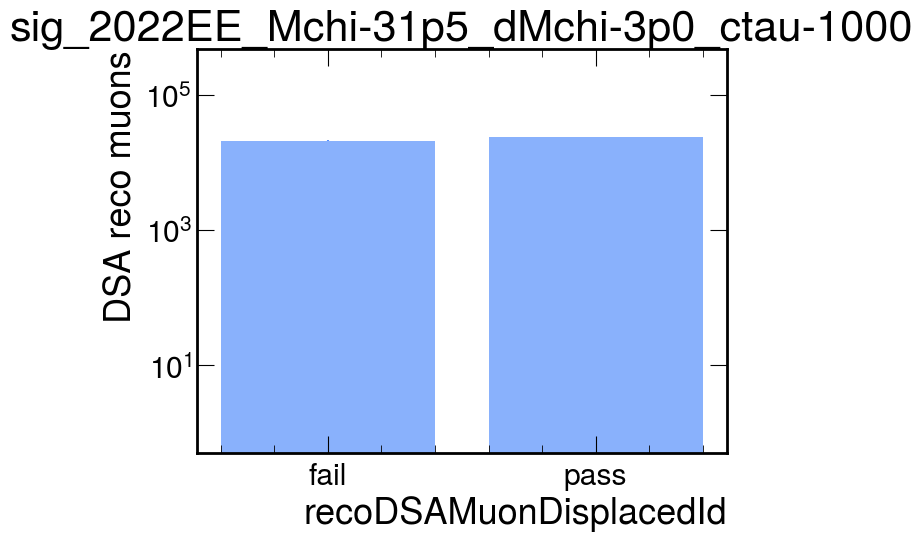

Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/dsa_muon_pass_id_sig_2022EE_Mchi-31p5_dMchi-3p0_ctau-1000.png
Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/dsa_muon_pass_id_sig_2022EE_Mchi-31p5_dMchi-3p0_ctau-1000.pdf


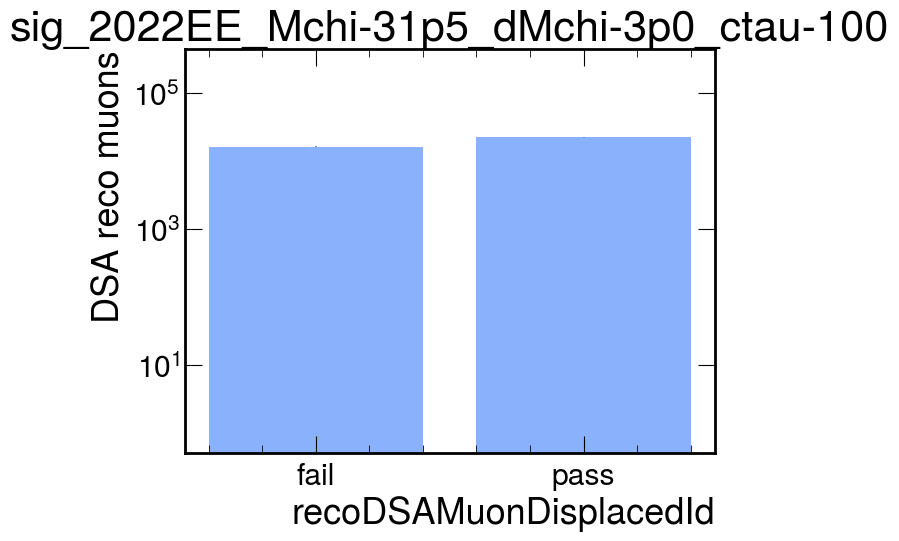

Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/dsa_muon_pass_id_sig_2022EE_Mchi-31p5_dMchi-3p0_ctau-100.png
Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/dsa_muon_pass_id_sig_2022EE_Mchi-31p5_dMchi-3p0_ctau-100.pdf


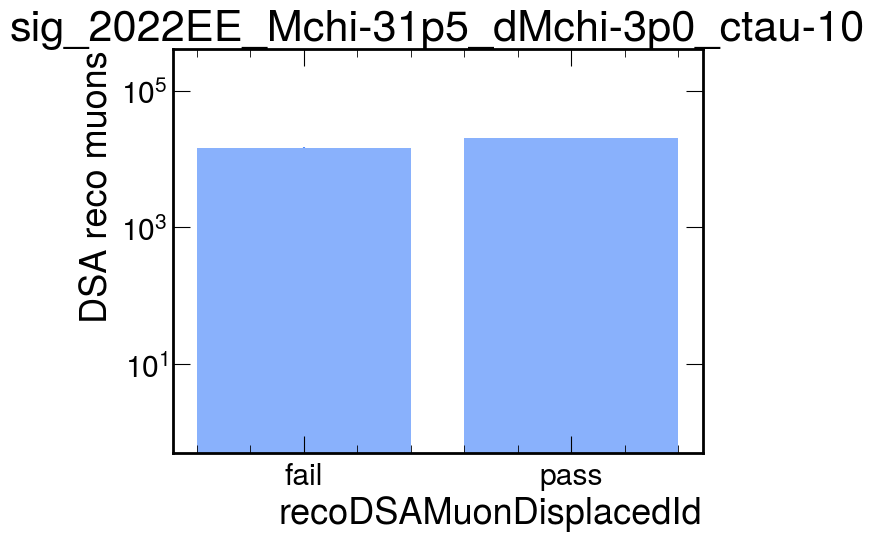

Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/dsa_muon_pass_id_sig_2022EE_Mchi-31p5_dMchi-3p0_ctau-10.png
Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/dsa_muon_pass_id_sig_2022EE_Mchi-31p5_dMchi-3p0_ctau-10.pdf


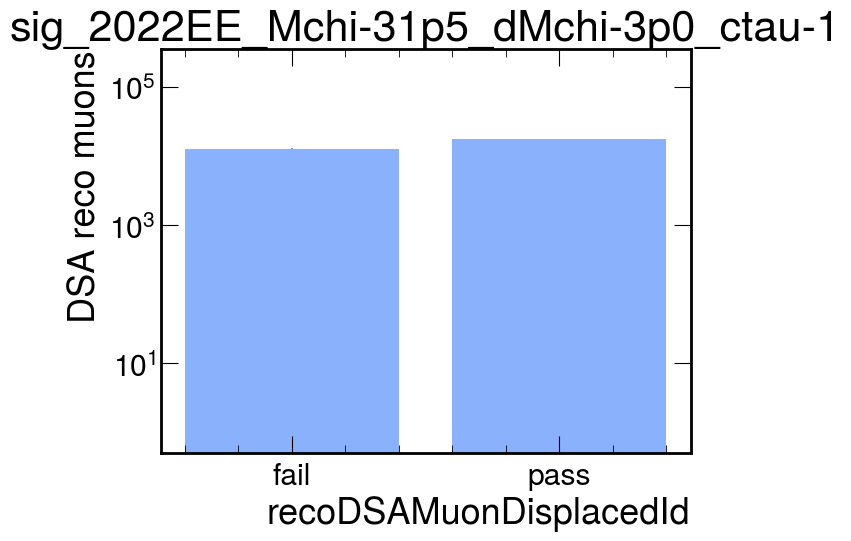

Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/dsa_muon_pass_id_sig_2022EE_Mchi-31p5_dMchi-3p0_ctau-1.png
Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/dsa_muon_pass_id_sig_2022EE_Mchi-31p5_dMchi-3p0_ctau-1.pdf


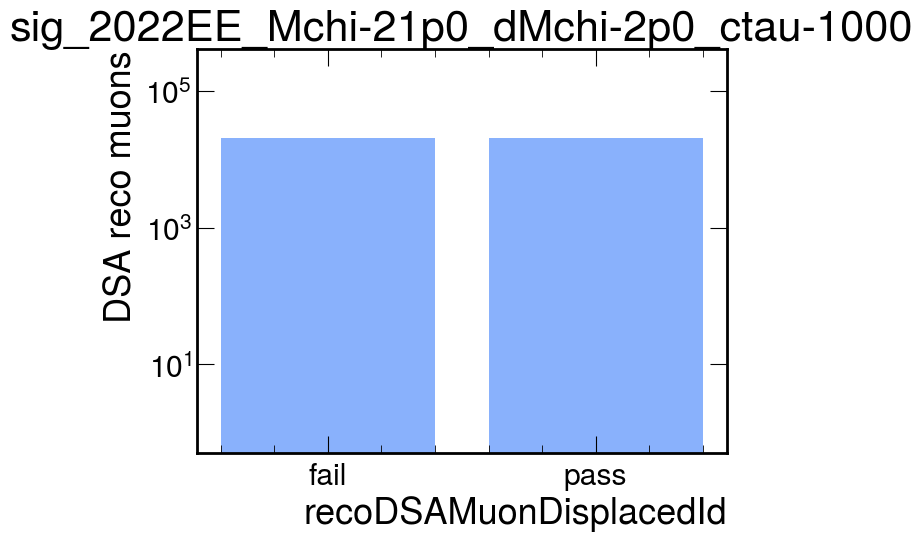

Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/dsa_muon_pass_id_sig_2022EE_Mchi-21p0_dMchi-2p0_ctau-1000.png
Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/dsa_muon_pass_id_sig_2022EE_Mchi-21p0_dMchi-2p0_ctau-1000.pdf


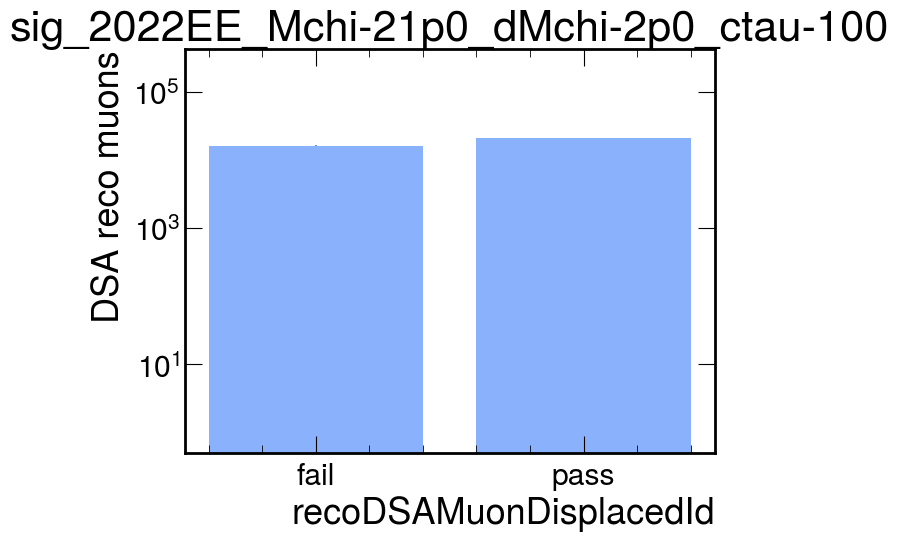

Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/dsa_muon_pass_id_sig_2022EE_Mchi-21p0_dMchi-2p0_ctau-100.png
Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/dsa_muon_pass_id_sig_2022EE_Mchi-21p0_dMchi-2p0_ctau-100.pdf


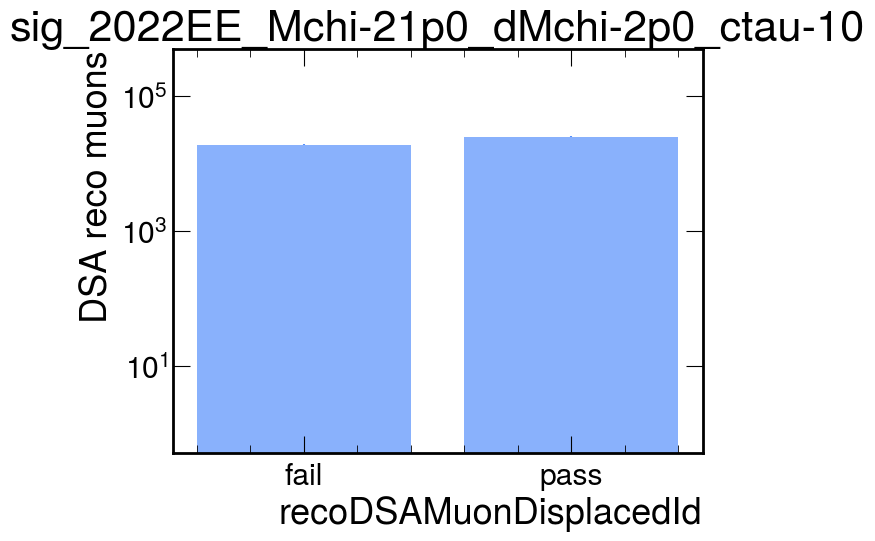

Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/dsa_muon_pass_id_sig_2022EE_Mchi-21p0_dMchi-2p0_ctau-10.png
Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/dsa_muon_pass_id_sig_2022EE_Mchi-21p0_dMchi-2p0_ctau-10.pdf


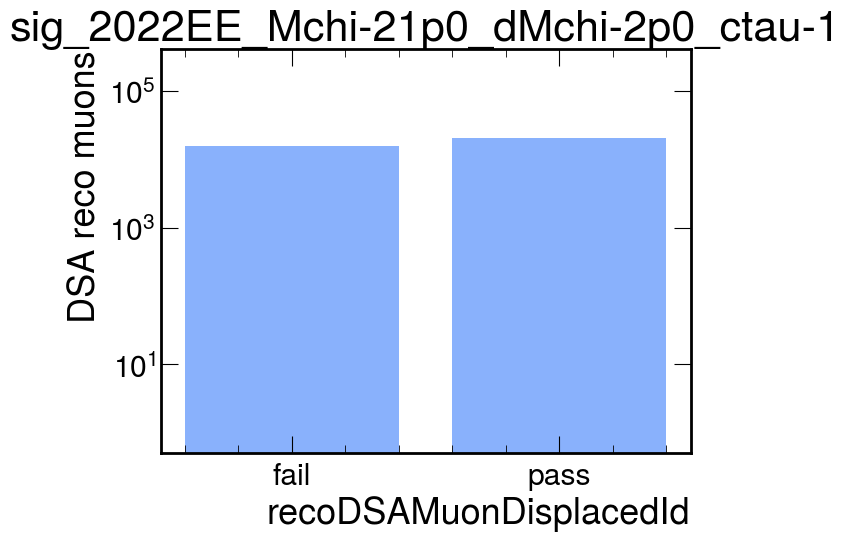

Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/dsa_muon_pass_id_sig_2022EE_Mchi-21p0_dMchi-2p0_ctau-1.png
Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/dsa_muon_pass_id_sig_2022EE_Mchi-21p0_dMchi-2p0_ctau-1.pdf


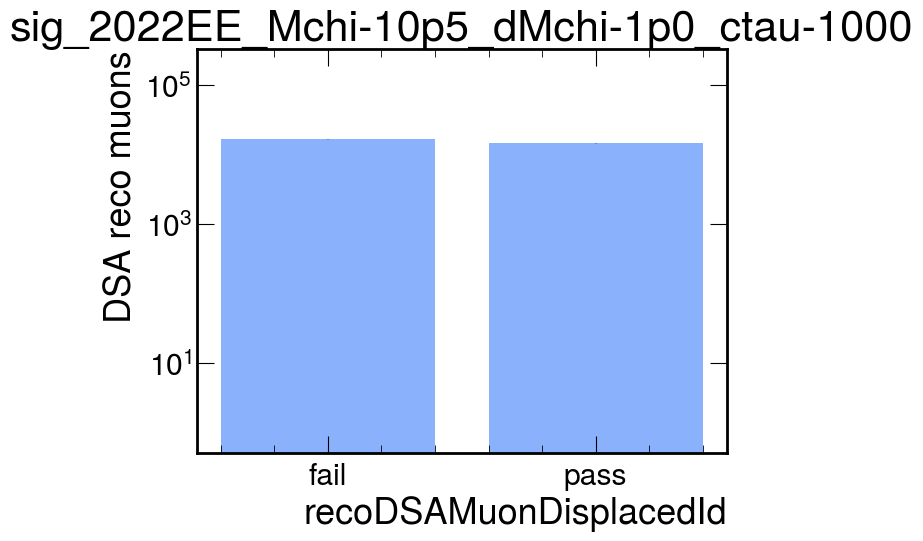

Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/dsa_muon_pass_id_sig_2022EE_Mchi-10p5_dMchi-1p0_ctau-1000.png
Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/dsa_muon_pass_id_sig_2022EE_Mchi-10p5_dMchi-1p0_ctau-1000.pdf


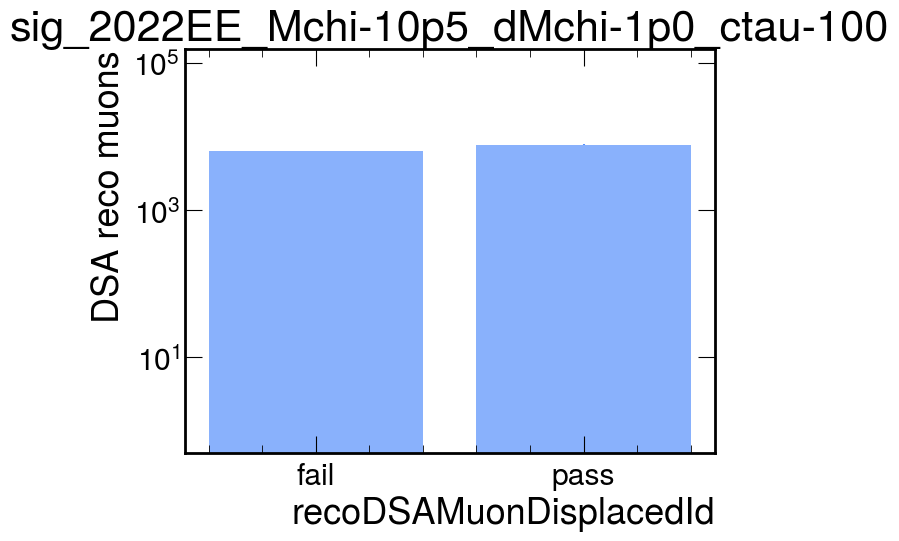

Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/dsa_muon_pass_id_sig_2022EE_Mchi-10p5_dMchi-1p0_ctau-100.png
Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/dsa_muon_pass_id_sig_2022EE_Mchi-10p5_dMchi-1p0_ctau-100.pdf


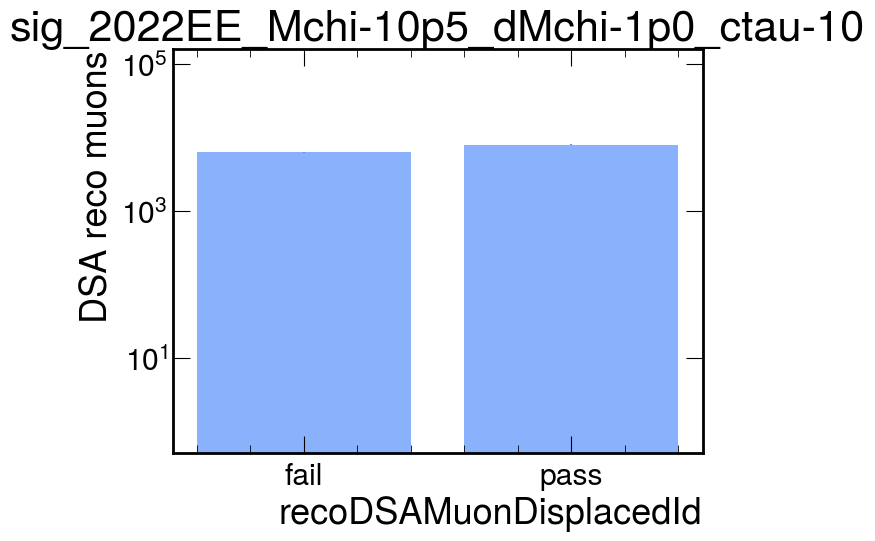

Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/dsa_muon_pass_id_sig_2022EE_Mchi-10p5_dMchi-1p0_ctau-10.png
Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/dsa_muon_pass_id_sig_2022EE_Mchi-10p5_dMchi-1p0_ctau-10.pdf


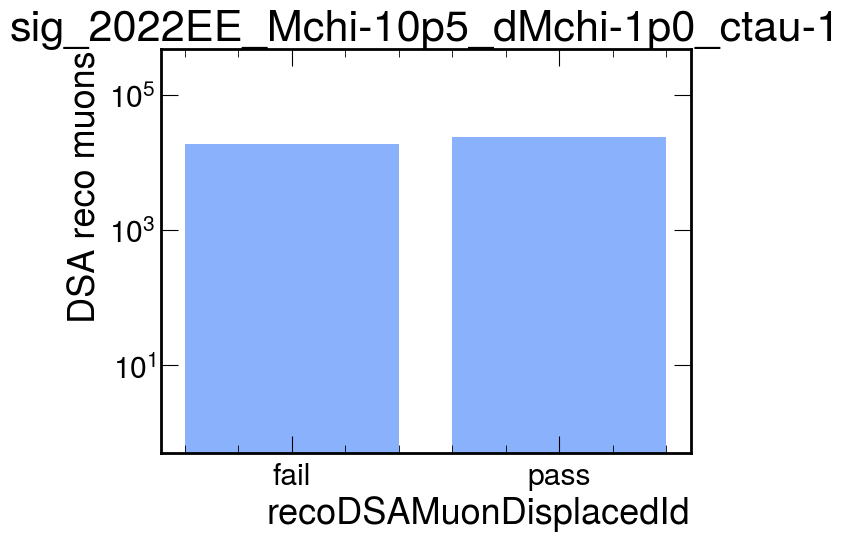

Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/dsa_muon_pass_id_sig_2022EE_Mchi-10p5_dMchi-1p0_ctau-1.png
Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/dsa_muon_pass_id_sig_2022EE_Mchi-10p5_dMchi-1p0_ctau-1.pdf


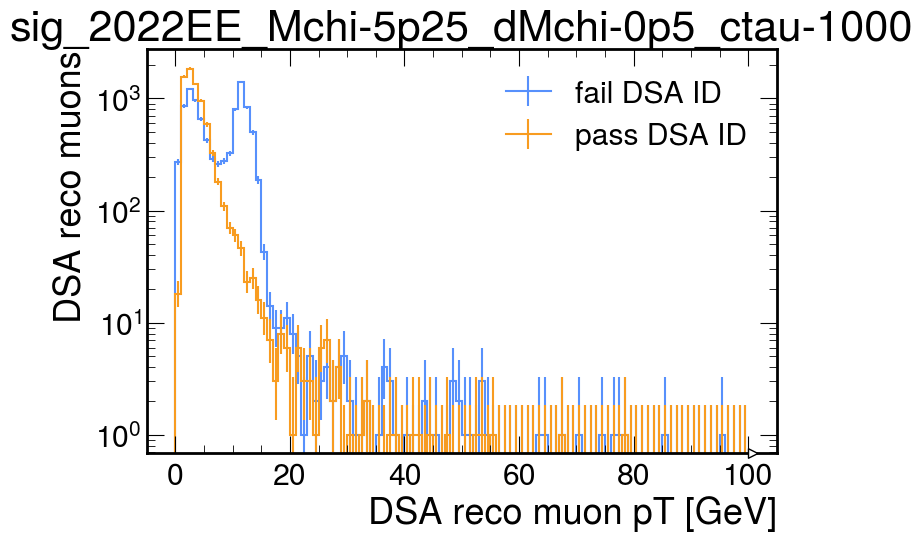

Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/dsa_muon_pt_pass_id_sig_2022EE_Mchi-5p25_dMchi-0p5_ctau-1000.png
Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/dsa_muon_pt_pass_id_sig_2022EE_Mchi-5p25_dMchi-0p5_ctau-1000.pdf


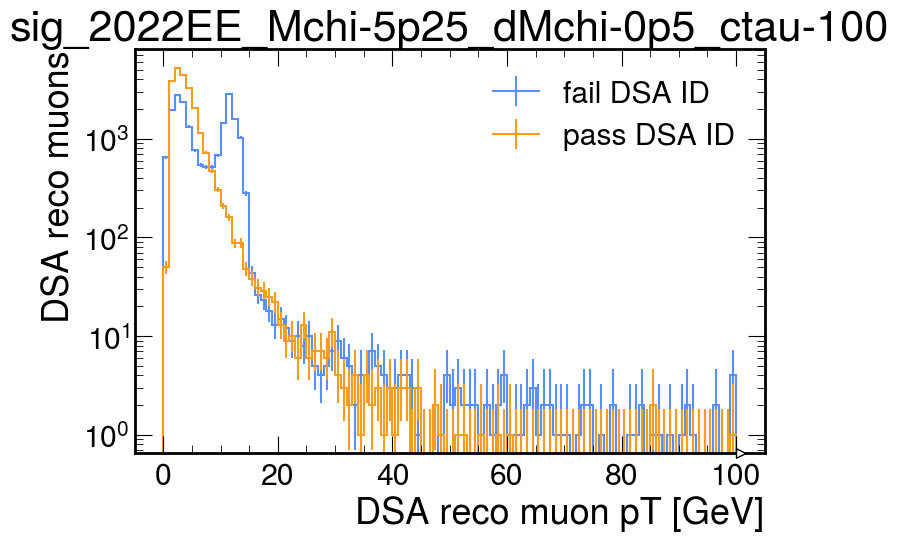

Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/dsa_muon_pt_pass_id_sig_2022EE_Mchi-5p25_dMchi-0p5_ctau-100.png
Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/dsa_muon_pt_pass_id_sig_2022EE_Mchi-5p25_dMchi-0p5_ctau-100.pdf


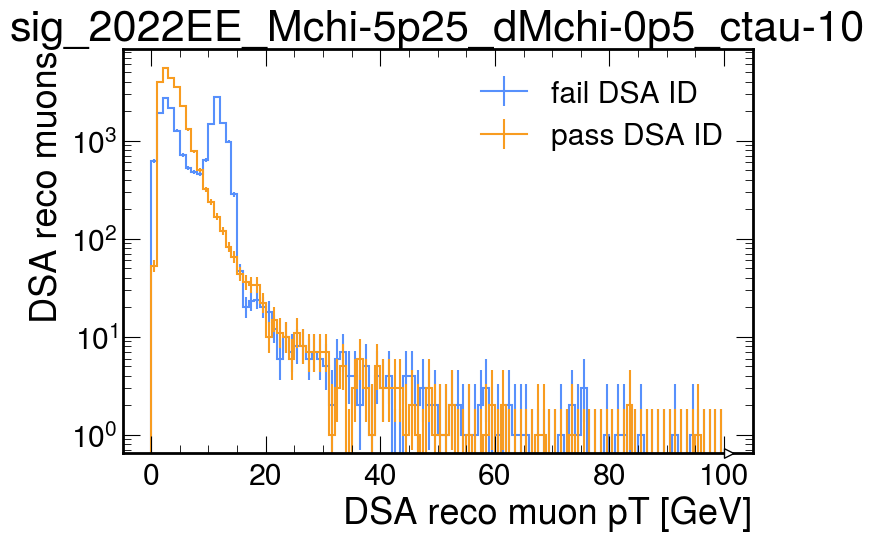

Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/dsa_muon_pt_pass_id_sig_2022EE_Mchi-5p25_dMchi-0p5_ctau-10.png
Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/dsa_muon_pt_pass_id_sig_2022EE_Mchi-5p25_dMchi-0p5_ctau-10.pdf


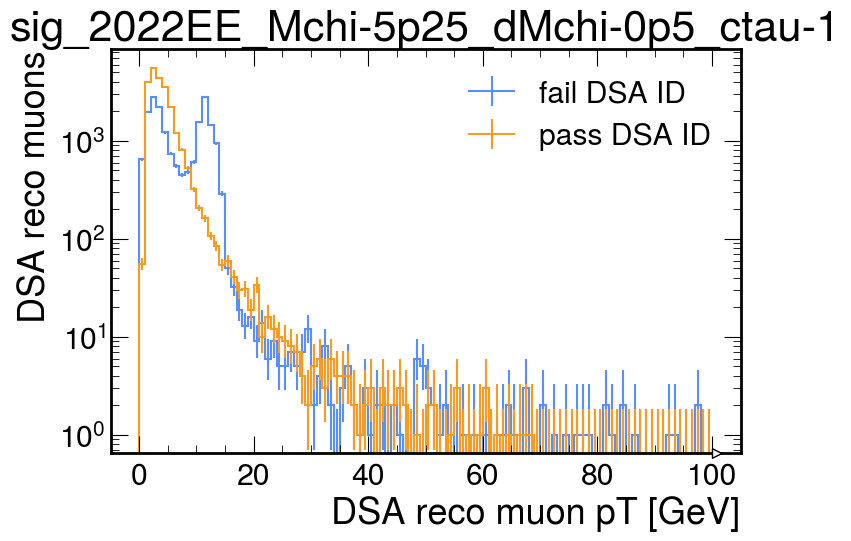

Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/dsa_muon_pt_pass_id_sig_2022EE_Mchi-5p25_dMchi-0p5_ctau-1.png
Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/dsa_muon_pt_pass_id_sig_2022EE_Mchi-5p25_dMchi-0p5_ctau-1.pdf


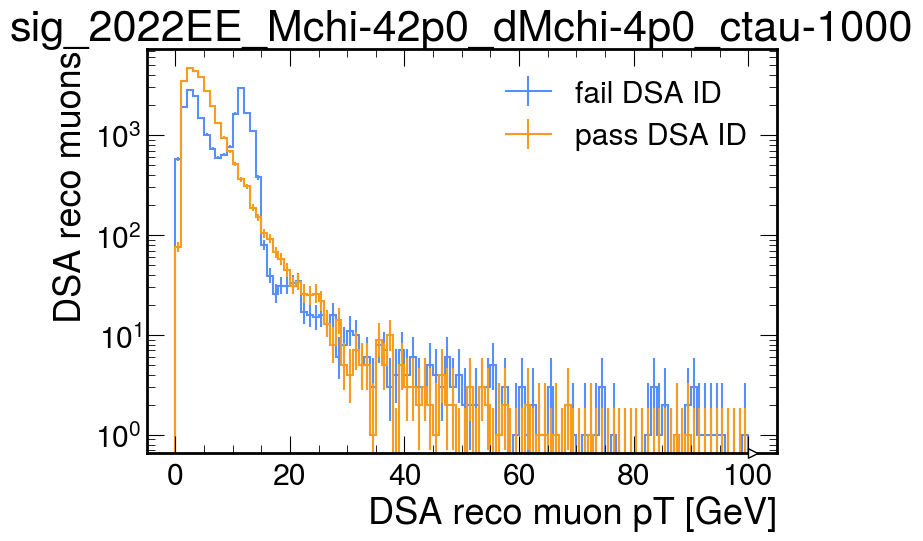

Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/dsa_muon_pt_pass_id_sig_2022EE_Mchi-42p0_dMchi-4p0_ctau-1000.png
Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/dsa_muon_pt_pass_id_sig_2022EE_Mchi-42p0_dMchi-4p0_ctau-1000.pdf


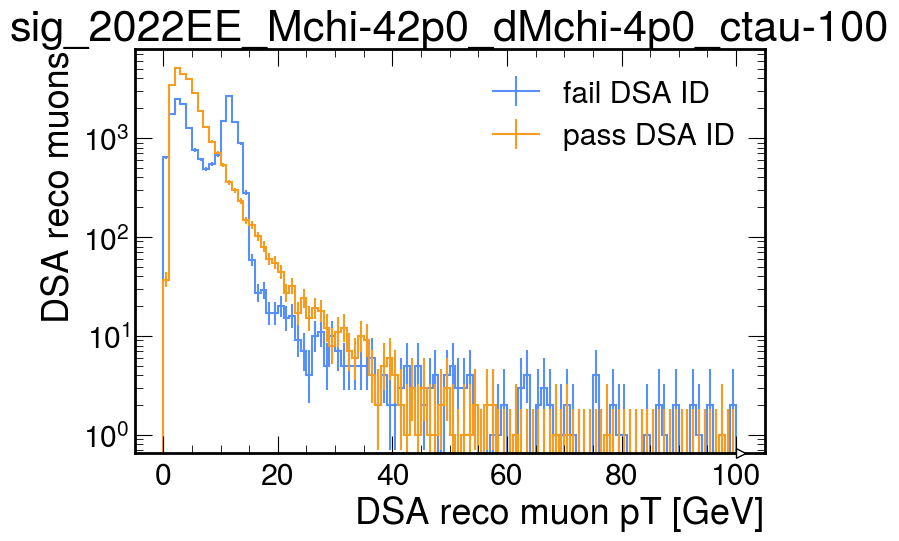

Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/dsa_muon_pt_pass_id_sig_2022EE_Mchi-42p0_dMchi-4p0_ctau-100.png
Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/dsa_muon_pt_pass_id_sig_2022EE_Mchi-42p0_dMchi-4p0_ctau-100.pdf


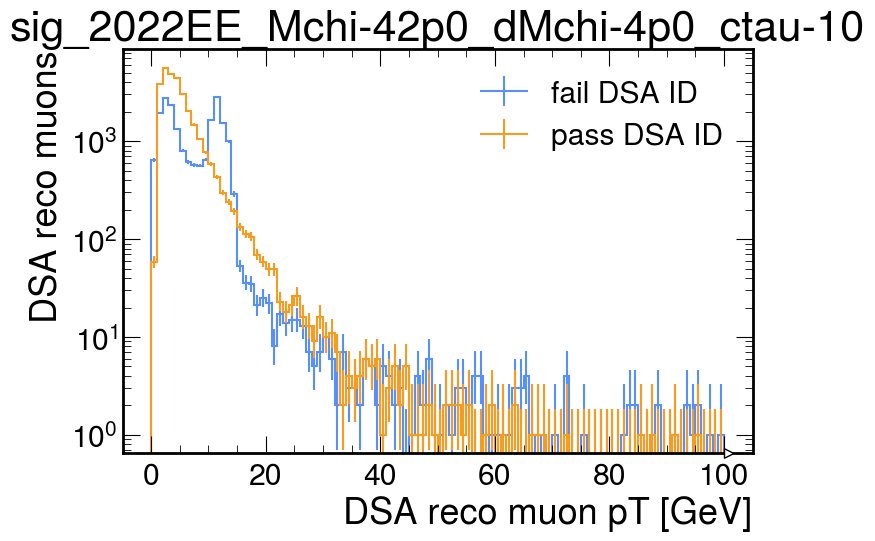

Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/dsa_muon_pt_pass_id_sig_2022EE_Mchi-42p0_dMchi-4p0_ctau-10.png
Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/dsa_muon_pt_pass_id_sig_2022EE_Mchi-42p0_dMchi-4p0_ctau-10.pdf


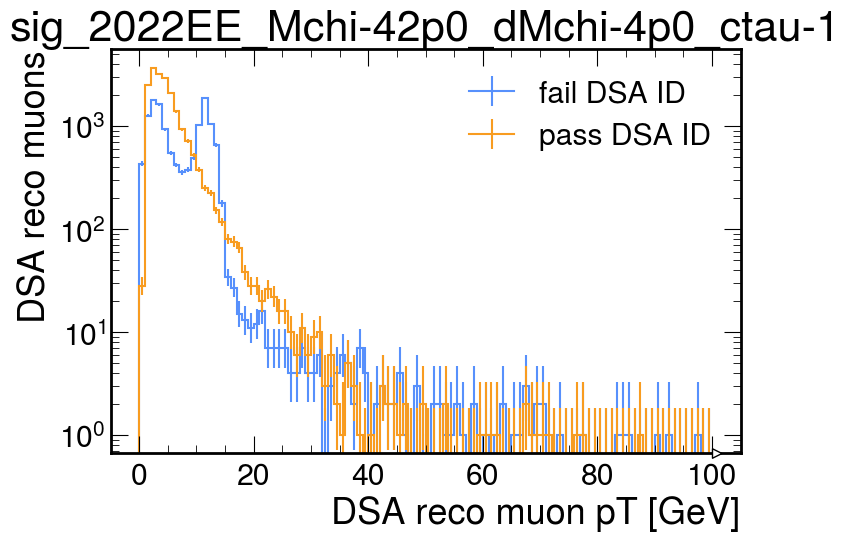

Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/dsa_muon_pt_pass_id_sig_2022EE_Mchi-42p0_dMchi-4p0_ctau-1.png
Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/dsa_muon_pt_pass_id_sig_2022EE_Mchi-42p0_dMchi-4p0_ctau-1.pdf


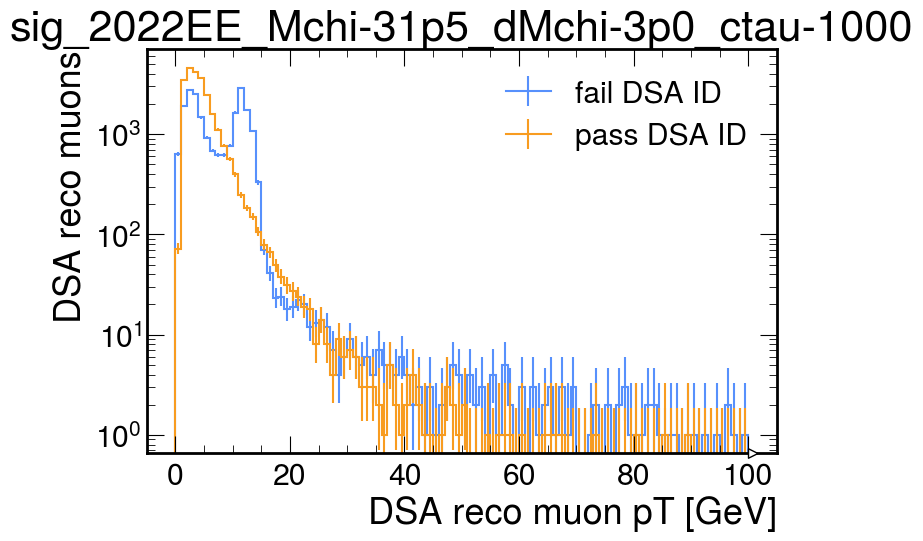

Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/dsa_muon_pt_pass_id_sig_2022EE_Mchi-31p5_dMchi-3p0_ctau-1000.png
Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/dsa_muon_pt_pass_id_sig_2022EE_Mchi-31p5_dMchi-3p0_ctau-1000.pdf


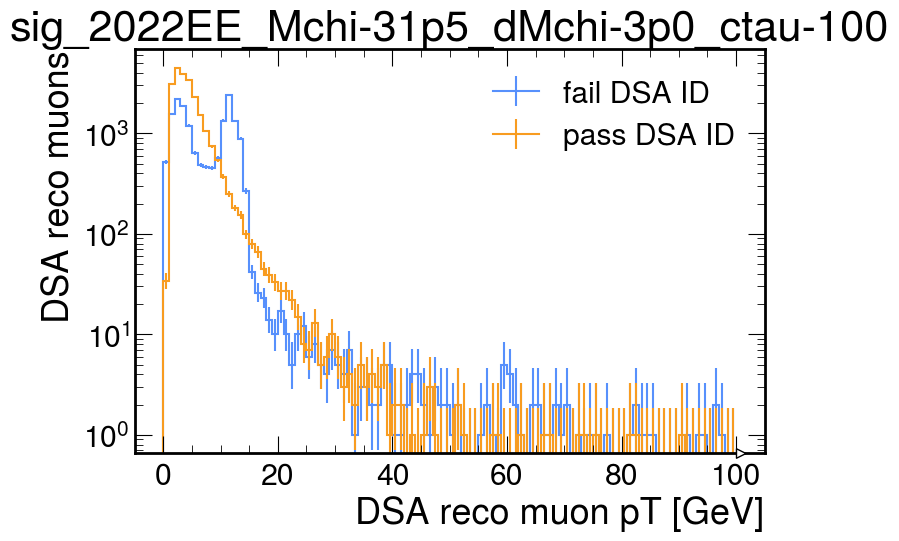

Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/dsa_muon_pt_pass_id_sig_2022EE_Mchi-31p5_dMchi-3p0_ctau-100.png
Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/dsa_muon_pt_pass_id_sig_2022EE_Mchi-31p5_dMchi-3p0_ctau-100.pdf


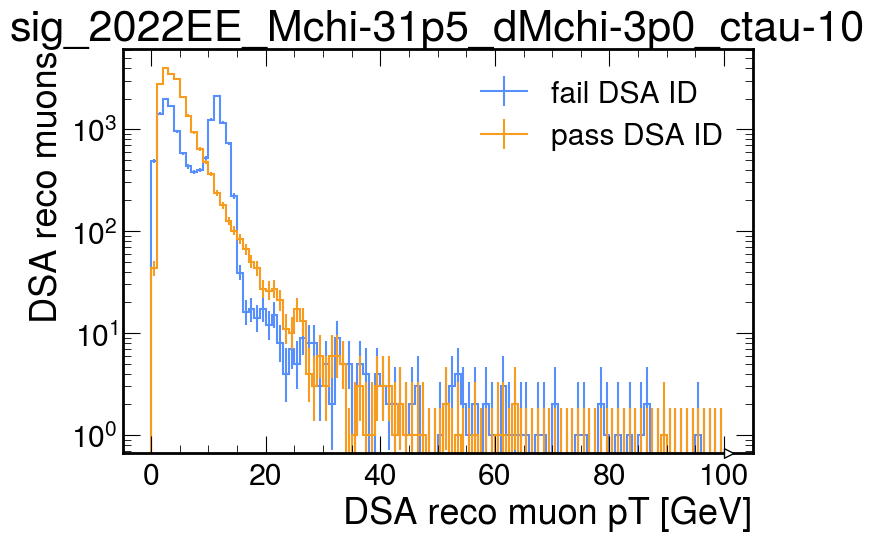

Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/dsa_muon_pt_pass_id_sig_2022EE_Mchi-31p5_dMchi-3p0_ctau-10.png
Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/dsa_muon_pt_pass_id_sig_2022EE_Mchi-31p5_dMchi-3p0_ctau-10.pdf


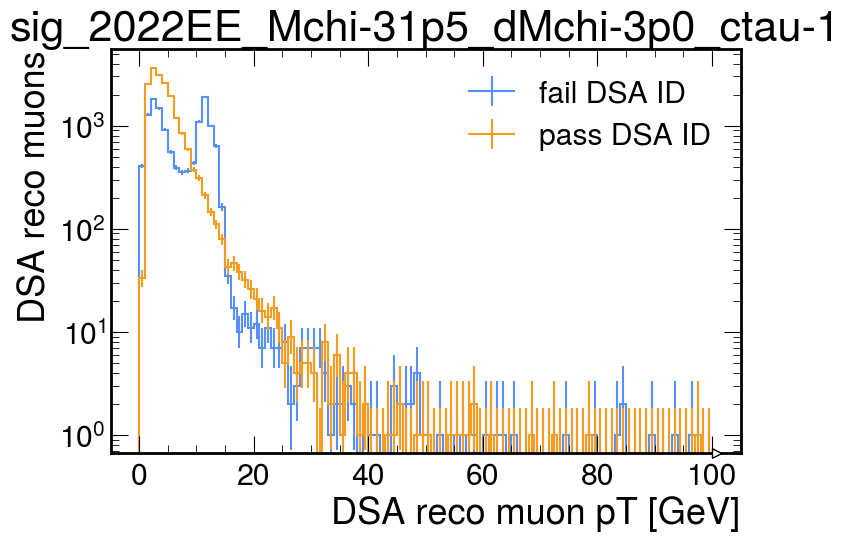

Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/dsa_muon_pt_pass_id_sig_2022EE_Mchi-31p5_dMchi-3p0_ctau-1.png
Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/dsa_muon_pt_pass_id_sig_2022EE_Mchi-31p5_dMchi-3p0_ctau-1.pdf


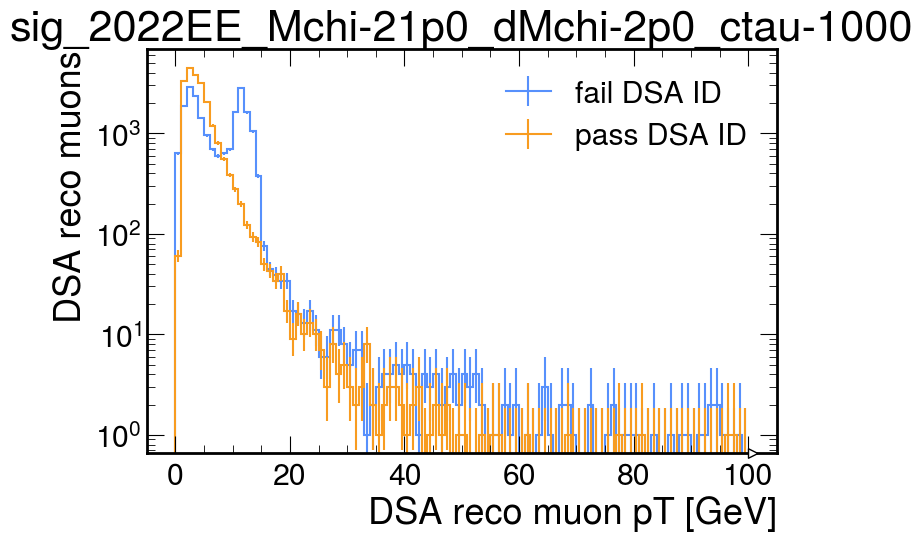

Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/dsa_muon_pt_pass_id_sig_2022EE_Mchi-21p0_dMchi-2p0_ctau-1000.png
Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/dsa_muon_pt_pass_id_sig_2022EE_Mchi-21p0_dMchi-2p0_ctau-1000.pdf


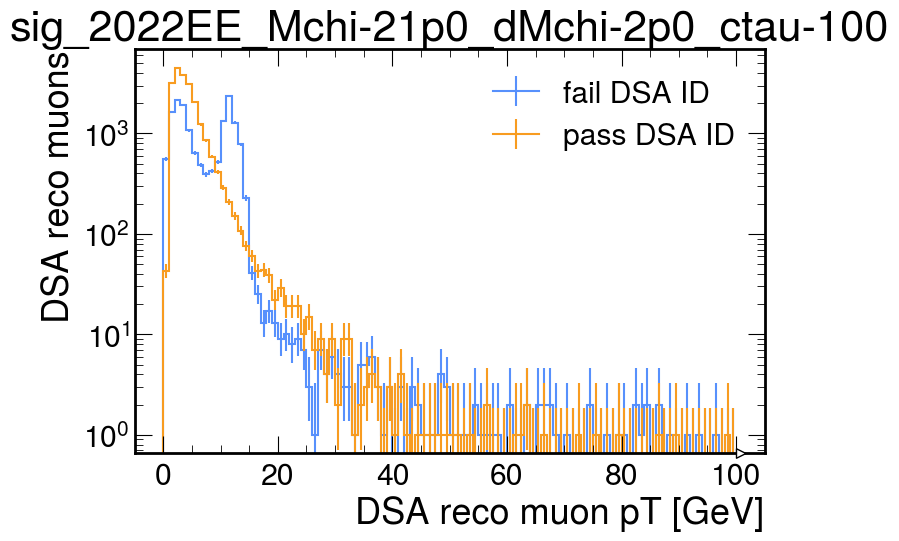

Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/dsa_muon_pt_pass_id_sig_2022EE_Mchi-21p0_dMchi-2p0_ctau-100.png
Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/dsa_muon_pt_pass_id_sig_2022EE_Mchi-21p0_dMchi-2p0_ctau-100.pdf


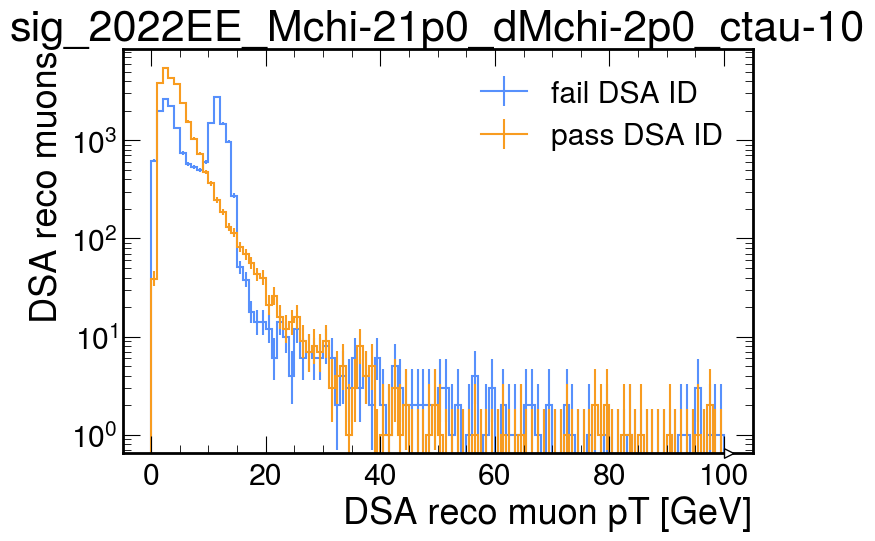

Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/dsa_muon_pt_pass_id_sig_2022EE_Mchi-21p0_dMchi-2p0_ctau-10.png
Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/dsa_muon_pt_pass_id_sig_2022EE_Mchi-21p0_dMchi-2p0_ctau-10.pdf


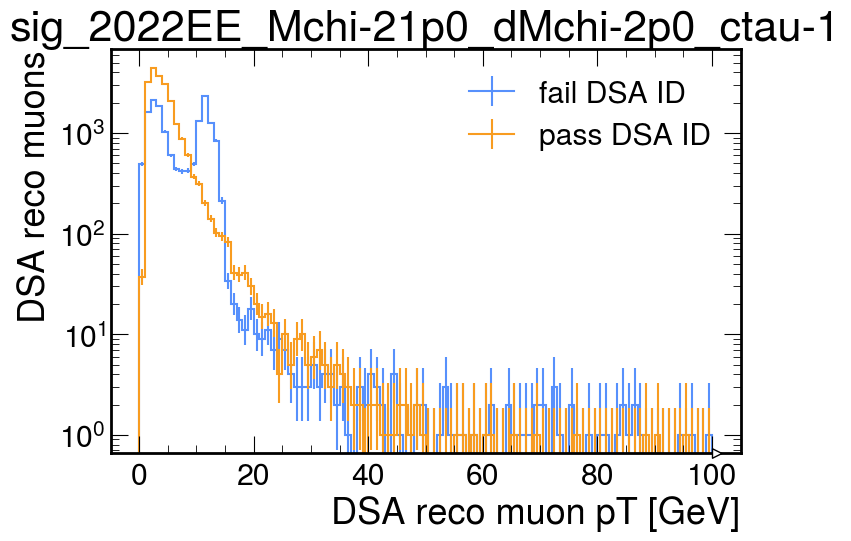

Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/dsa_muon_pt_pass_id_sig_2022EE_Mchi-21p0_dMchi-2p0_ctau-1.png
Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/dsa_muon_pt_pass_id_sig_2022EE_Mchi-21p0_dMchi-2p0_ctau-1.pdf


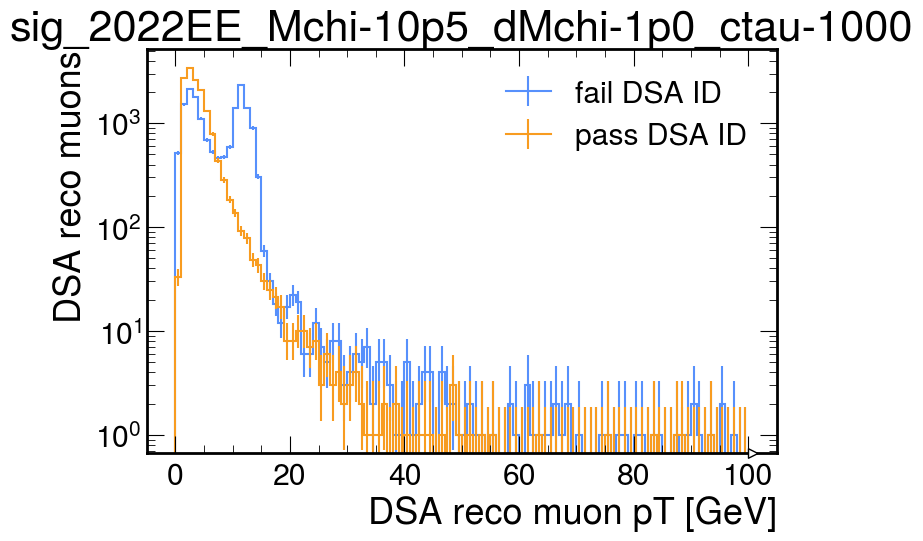

Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/dsa_muon_pt_pass_id_sig_2022EE_Mchi-10p5_dMchi-1p0_ctau-1000.png
Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/dsa_muon_pt_pass_id_sig_2022EE_Mchi-10p5_dMchi-1p0_ctau-1000.pdf


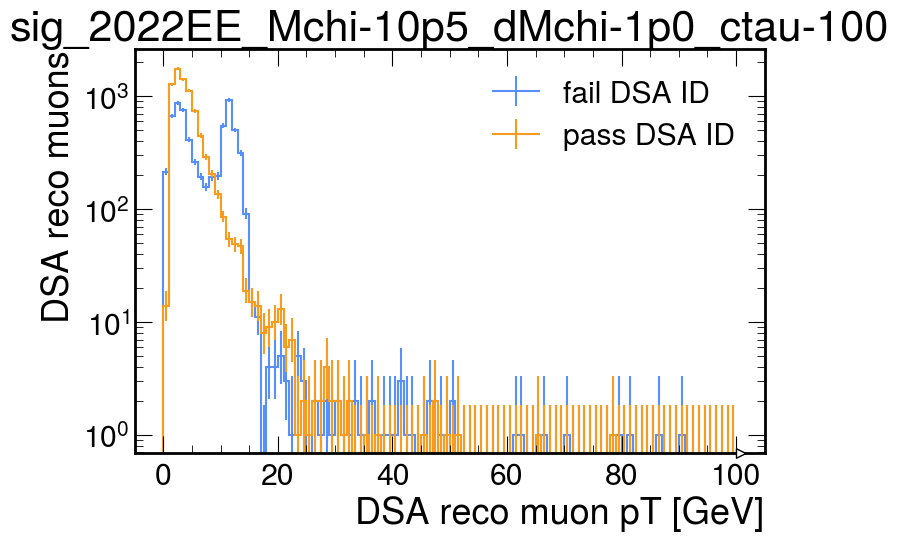

Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/dsa_muon_pt_pass_id_sig_2022EE_Mchi-10p5_dMchi-1p0_ctau-100.png
Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/dsa_muon_pt_pass_id_sig_2022EE_Mchi-10p5_dMchi-1p0_ctau-100.pdf


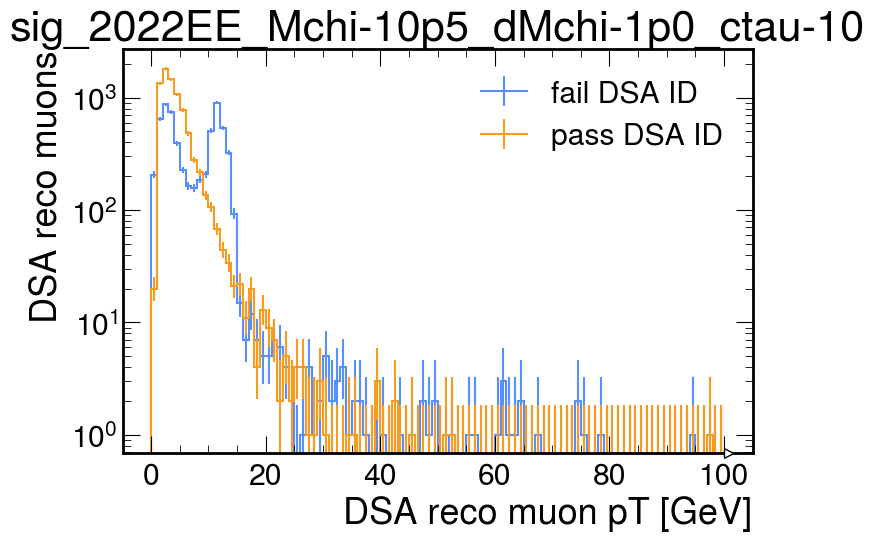

Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/dsa_muon_pt_pass_id_sig_2022EE_Mchi-10p5_dMchi-1p0_ctau-10.png
Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/dsa_muon_pt_pass_id_sig_2022EE_Mchi-10p5_dMchi-1p0_ctau-10.pdf


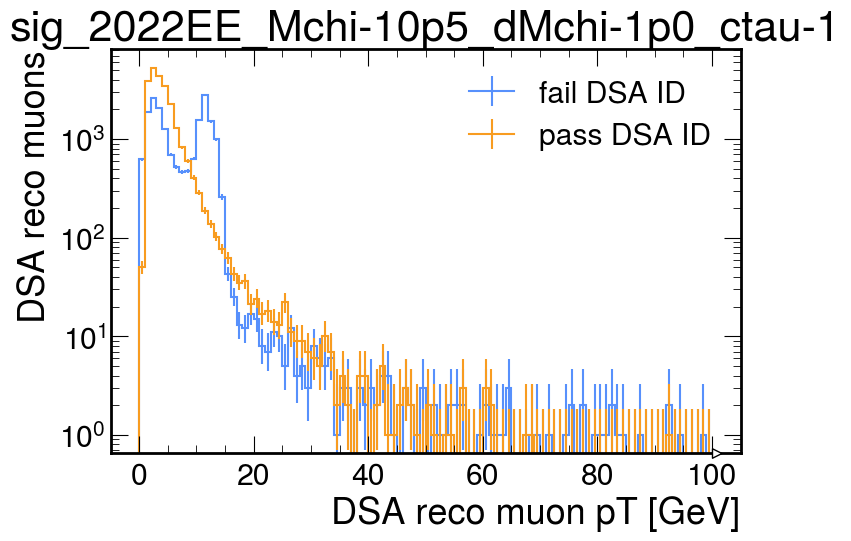

Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/dsa_muon_pt_pass_id_sig_2022EE_Mchi-10p5_dMchi-1p0_ctau-1.png
Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/dsa_muon_pt_pass_id_sig_2022EE_Mchi-10p5_dMchi-1p0_ctau-1.pdf


/tmp/ipykernel_820316/3921512460.py:271: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


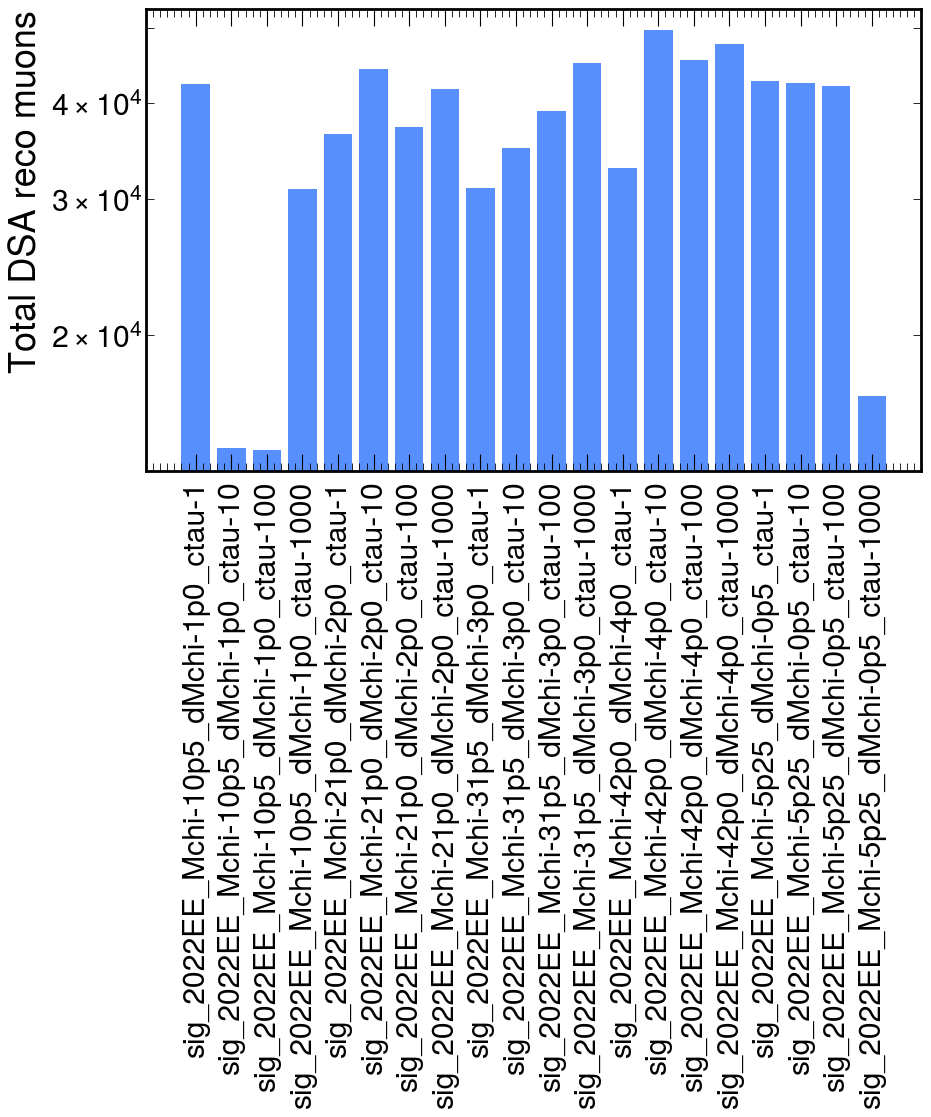

Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/summary_total_dsa_reco_muons.png
Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/summary_total_dsa_reco_muons.pdf


/tmp/ipykernel_820316/3921512460.py:271: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


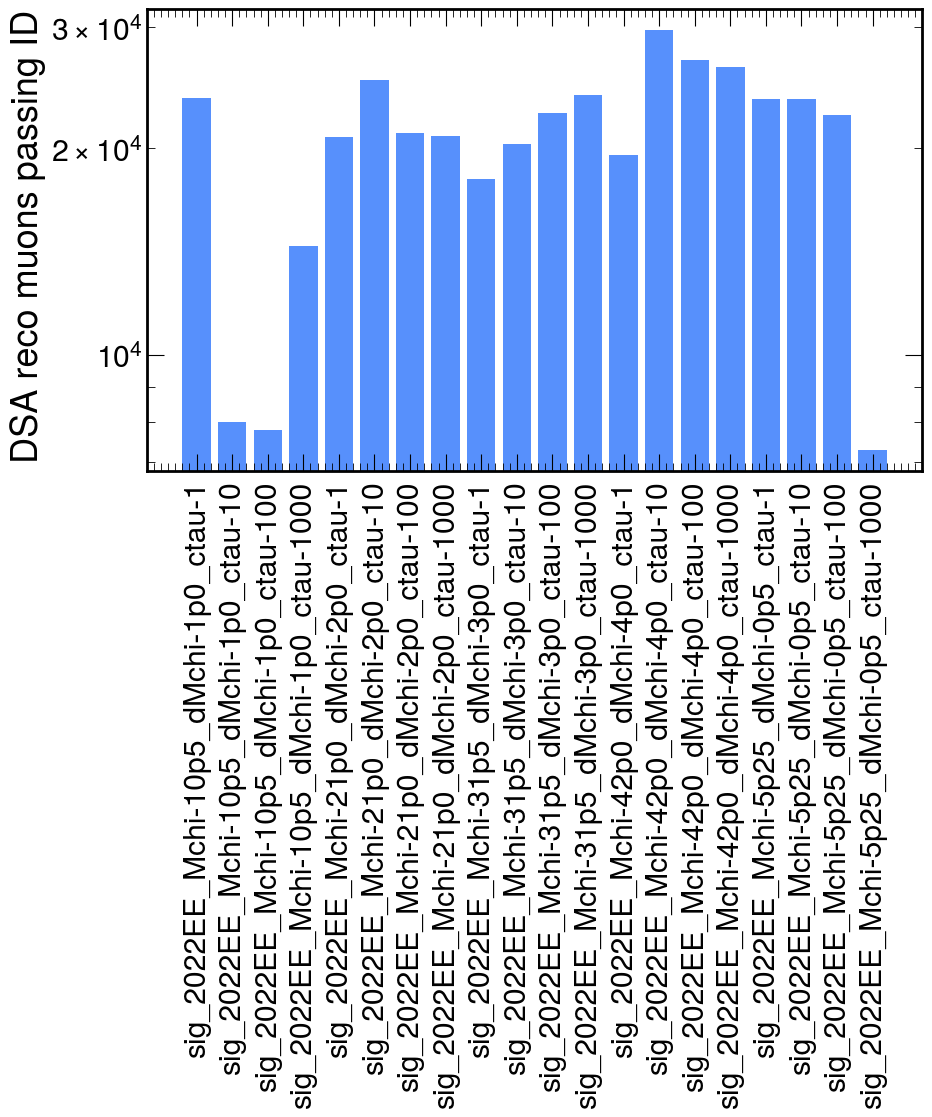

Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/summary_total_dsa_reco_muons_pass_id.png
Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/summary_total_dsa_reco_muons_pass_id.pdf


/tmp/ipykernel_820316/3921512460.py:271: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


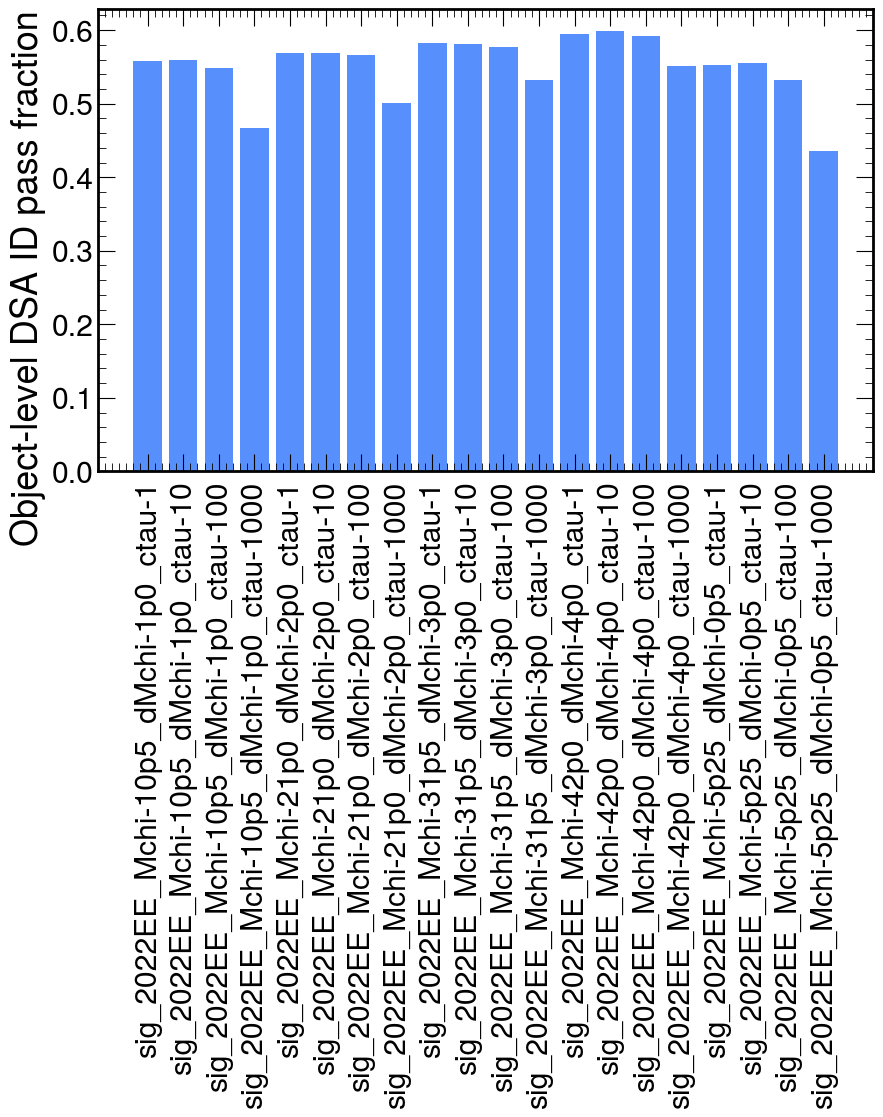

Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/summary_dsa_object_id_pass_fraction.png
Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/summary_dsa_object_id_pass_fraction.pdf


/tmp/ipykernel_820316/3921512460.py:271: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


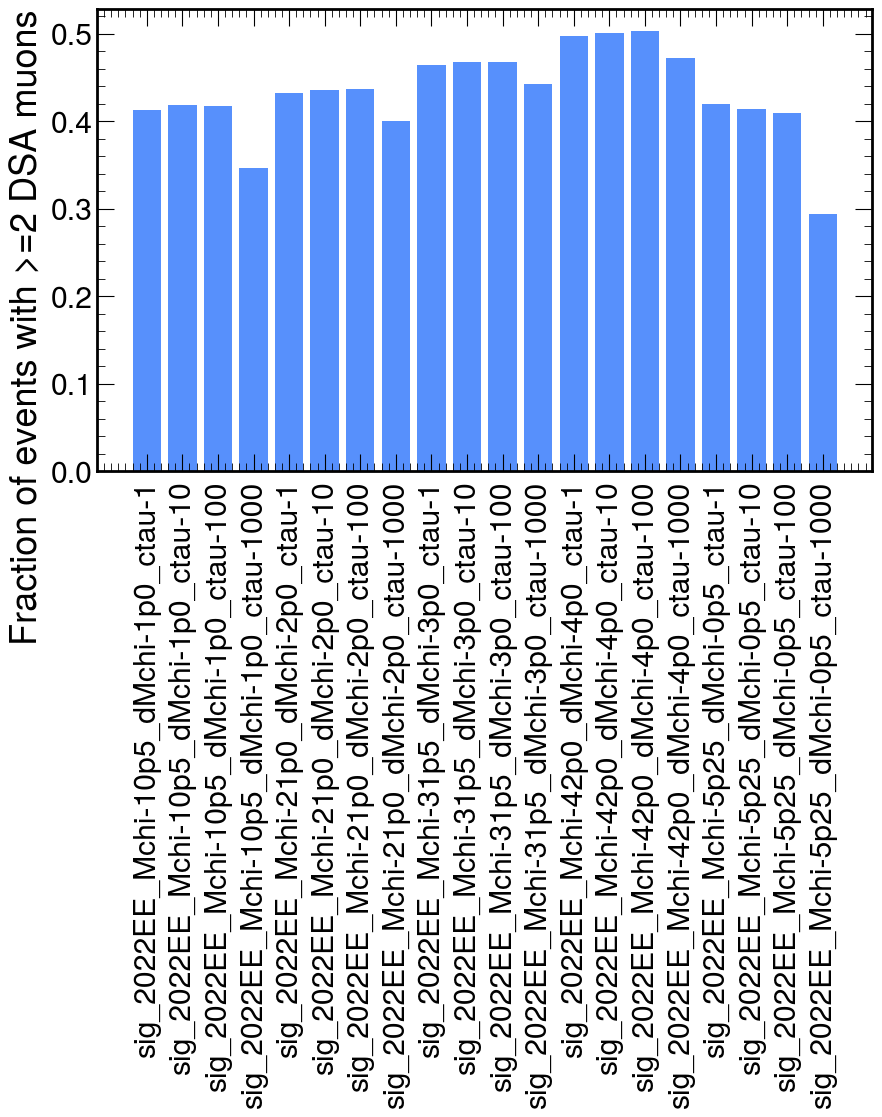

Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/summary_frac_events_ge2_dsa.png
Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/summary_frac_events_ge2_dsa.pdf


/tmp/ipykernel_820316/3921512460.py:271: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


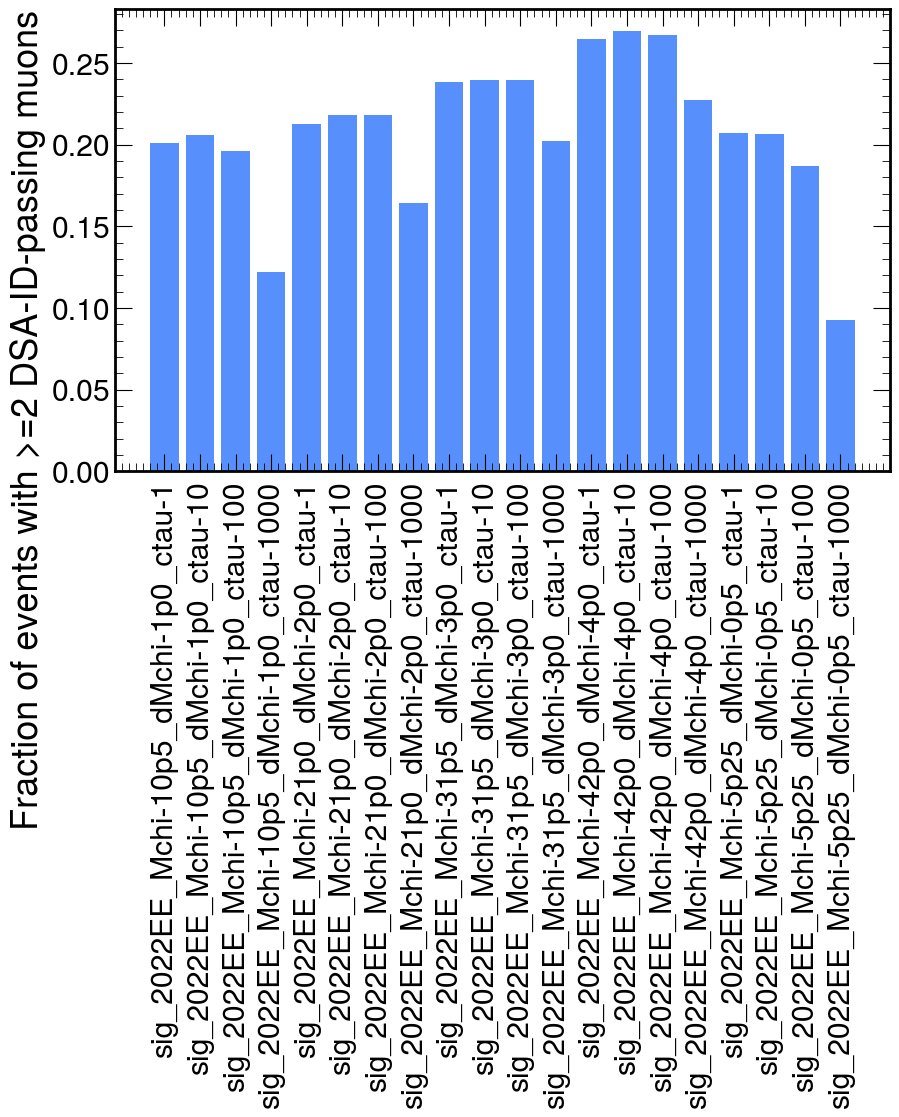

Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/summary_frac_events_ge2_dsa_pass_id.png
Saved: outputs/muonReco_dsaID_checks_allSamples_allEvents/plots/summary_frac_events_ge2_dsa_pass_id.pdf

Done: all samples, all files/events
Coffea file:          outputs/muonReco_dsaID_checks_allSamples_allEvents/muonReco_dsaID_checks_allSamples_allEvents.coffea
Per-sample CSV:       outputs/muonReco_dsaID_checks_allSamples_allEvents/csv/muonReco_dsaID_summary_allSamples_allEvents.csv
Total summary CSV:    outputs/muonReco_dsaID_checks_allSamples_allEvents/csv/muonReco_dsaID_total_summary_allSamples_allEvents.csv
Histogram CSVs:       outputs/muonReco_dsaID_checks_allSamples_allEvents/csv
Plots:                outputs/muonReco_dsaID_checks_allSamples_allEvents/plots
Processed events:     495000
Time taken:           47.48 s = 0.79 min


In [5]:
# ============================================================
# Run muonRecoProcessor over ALL iDMmu signal samples/files/events
# Make DSA-ID summaries, plots, CSVs, and save .coffea output
# ============================================================

import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import coffea.util as util

# Optional but nicer if available
try:
    import mplhep as hep
    hep.style.use("CMS")
    HAS_MPLHEP = True
except Exception:
    HAS_MPLHEP = False

# -----------------------------
# User settings
# -----------------------------
sample_json = "configs/sample_configs/signal_2022EE_iDMmu_aEM.json"

outdir = "outputs/muonReco_dsaID_checks_allSamples_allEvents"
plotdir = f"{outdir}/plots"
csvdir = f"{outdir}/csv"

workers = 4

gen_pt_min = 3.0
gen_eta_max = 2.4
reco_pt_min = 0.0
dr_max = 0.1
require_dsa_id = False

os.makedirs(plotdir, exist_ok=True)
os.makedirs(csvdir, exist_ok=True)

# -----------------------------
# Run Coffea analyzer on ALL samples/files/events
# -----------------------------
t0 = time.time()

ana = Analyzer(
    fileList=sample_json,
    histoList="dummy.py",
    cuts="dummyCuts.py",

    # IMPORTANT:
    # -1 means use all samples
    # -1 means use all files per sample
    max_samples=-1,
    max_files_per_samp=-1,
)

out = ana.process(
    treename="ntuples/outT",
    execr="futures",
    workers=workers,
    procType="muonReco",
    gen_pt_min=gen_pt_min,
    gen_eta_max=gen_eta_max,
    reco_pt_min=reco_pt_min,
    dr_max=dr_max,
    require_dsa_id=require_dsa_id,
)

dt = time.time() - t0

# -----------------------------
# Unwrap Coffea output
# -----------------------------
if isinstance(out, tuple):
    histos = out[0]
    metrics = out[1]
else:
    histos = out
    metrics = None

coffea_out = f"{outdir}/muonReco_dsaID_checks_allSamples_allEvents.coffea"
util.save(histos, coffea_out)

# -----------------------------
# Check expected histograms
# -----------------------------
expected_hists = [
    "muon_reco_counts",
    "muon_reco_pt",
    "muon_reco_abseta",
    "muon_reco_eta",
    "muon_reco_vxy",
    "muon_reco_vz",
    "n_dsa_muons",
    "n_dsa_muons_pass_id",
    "dsa_muon_pass_id",
    "dsa_muon_pt_pass_id",
]

print("=" * 100)
print("Checking expected histograms")
print("=" * 100)

missing_hists = []
for hname in expected_hists:
    exists = hname in histos
    print(f"{hname:35s} {'OK' if exists else 'MISSING'}")
    if not exists:
        missing_hists.append(hname)

if missing_hists:
    raise RuntimeError(f"Missing histograms: {missing_hists}")

counts_h = histos["muon_reco_counts"]

axis_names = [ax.name for ax in counts_h.axes]
samp_axis = "samp" if "samp" in axis_names else "sample"
quantity_axis = "quantity"

expected_quantities = [
    "n_events",
    "n_events_ge2_gen_mu",
    "n_gen_mu_den",
    "n_prompt_matched",
    "n_dsa_matched",
    "n_either_matched",
    "n_events_both_prompt",
    "n_events_both_dsa",
    "n_events_both_either",
    "n_dsa_reco_muons",
    "n_dsa_reco_muons_pass_id",
    "n_events_with_dsa",
    "n_events_with_dsa_pass_id",
    "n_events_0_dsa",
    "n_events_1_dsa",
    "n_events_ge2_dsa",
    "n_events_0_dsa_pass_id",
    "n_events_1_dsa_pass_id",
    "n_events_ge2_dsa_pass_id",
]

available_quantities = list(counts_h.axes[quantity_axis])

print("\n" + "=" * 100)
print("Checking expected count categories")
print("=" * 100)

missing_quantities = []
for q in expected_quantities:
    exists = q in available_quantities
    print(f"{q:35s} {'OK' if exists else 'MISSING'}")
    if not exists:
        missing_quantities.append(q)

if missing_quantities:
    raise RuntimeError(f"Missing count categories: {missing_quantities}")

# -----------------------------
# Build per-sample summary dataframe
# -----------------------------
summary_rows = []
samples = list(counts_h.axes[samp_axis])

for samp in samples:
    vals = {}

    for q in available_quantities:
        vals[q] = float(counts_h[{samp_axis: samp, quantity_axis: q}].value)

    n_events = vals.get("n_events", 0.0)
    n_dsa = vals.get("n_dsa_reco_muons", 0.0)
    n_dsa_pass = vals.get("n_dsa_reco_muons_pass_id", 0.0)

    n_evt_with_dsa = vals.get("n_events_with_dsa", 0.0)
    n_evt_with_dsa_pass = vals.get("n_events_with_dsa_pass_id", 0.0)

    n_gen = vals.get("n_gen_mu_den", 0.0)
    n_prompt_matched = vals.get("n_prompt_matched", 0.0)
    n_dsa_matched = vals.get("n_dsa_matched", 0.0)
    n_either_matched = vals.get("n_either_matched", 0.0)

    row = {
        "sample": samp,
        **vals,
        "dsa_object_id_pass_fraction": n_dsa_pass / n_dsa if n_dsa > 0 else np.nan,
        "dsa_event_id_pass_fraction": n_evt_with_dsa_pass / n_evt_with_dsa if n_evt_with_dsa > 0 else np.nan,
        "frac_events_0_dsa": vals.get("n_events_0_dsa", 0.0) / n_events if n_events > 0 else np.nan,
        "frac_events_1_dsa": vals.get("n_events_1_dsa", 0.0) / n_events if n_events > 0 else np.nan,
        "frac_events_ge2_dsa": vals.get("n_events_ge2_dsa", 0.0) / n_events if n_events > 0 else np.nan,
        "frac_events_0_dsa_pass_id": vals.get("n_events_0_dsa_pass_id", 0.0) / n_events if n_events > 0 else np.nan,
        "frac_events_1_dsa_pass_id": vals.get("n_events_1_dsa_pass_id", 0.0) / n_events if n_events > 0 else np.nan,
        "frac_events_ge2_dsa_pass_id": vals.get("n_events_ge2_dsa_pass_id", 0.0) / n_events if n_events > 0 else np.nan,
        "prompt_muon_reco_eff": n_prompt_matched / n_gen if n_gen > 0 else np.nan,
        "dsa_muon_reco_eff": n_dsa_matched / n_gen if n_gen > 0 else np.nan,
        "either_muon_reco_eff": n_either_matched / n_gen if n_gen > 0 else np.nan,
    }

    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)

summary_csv = f"{csvdir}/muonReco_dsaID_summary_allSamples_allEvents.csv"
summary_df.to_csv(summary_csv, index=False)

print("\n" + "=" * 100)
print("DSA-ID summary: all samples")
print("=" * 100)
print(summary_df.to_string(index=False))

# -----------------------------
# Build total summary row
# -----------------------------
total = {}
for q in available_quantities:
    total[q] = summary_df[q].sum() if q in summary_df.columns else 0.0

total_n_events = total.get("n_events", 0.0)
total_n_dsa = total.get("n_dsa_reco_muons", 0.0)
total_n_dsa_pass = total.get("n_dsa_reco_muons_pass_id", 0.0)
total_evt_with_dsa = total.get("n_events_with_dsa", 0.0)
total_evt_with_dsa_pass = total.get("n_events_with_dsa_pass_id", 0.0)
total_n_gen = total.get("n_gen_mu_den", 0.0)

total_summary = {
    "processed_events": total_n_events,
    "dsa_reco_muons": total_n_dsa,
    "dsa_reco_muons_pass_id": total_n_dsa_pass,
    "events_with_dsa": total_evt_with_dsa,
    "events_with_dsa_pass_id": total_evt_with_dsa_pass,
    "dsa_object_id_pass_fraction": total_n_dsa_pass / total_n_dsa if total_n_dsa > 0 else np.nan,
    "dsa_event_id_pass_fraction": total_evt_with_dsa_pass / total_evt_with_dsa if total_evt_with_dsa > 0 else np.nan,
    "events_0_dsa": total.get("n_events_0_dsa", 0.0),
    "events_1_dsa": total.get("n_events_1_dsa", 0.0),
    "events_ge2_dsa": total.get("n_events_ge2_dsa", 0.0),
    "events_0_dsa_pass_id": total.get("n_events_0_dsa_pass_id", 0.0),
    "events_1_dsa_pass_id": total.get("n_events_1_dsa_pass_id", 0.0),
    "events_ge2_dsa_pass_id": total.get("n_events_ge2_dsa_pass_id", 0.0),
    "gen_muon_denominator": total_n_gen,
    "prompt_matched": total.get("n_prompt_matched", 0.0),
    "dsa_matched": total.get("n_dsa_matched", 0.0),
    "either_matched": total.get("n_either_matched", 0.0),
    "prompt_muon_reco_eff": total.get("n_prompt_matched", 0.0) / total_n_gen if total_n_gen > 0 else np.nan,
    "dsa_muon_reco_eff": total.get("n_dsa_matched", 0.0) / total_n_gen if total_n_gen > 0 else np.nan,
    "either_muon_reco_eff": total.get("n_either_matched", 0.0) / total_n_gen if total_n_gen > 0 else np.nan,
    "time_seconds": dt,
    "time_minutes": dt / 60.0,
}

total_summary_df = pd.DataFrame([total_summary])
total_summary_csv = f"{csvdir}/muonReco_dsaID_total_summary_allSamples_allEvents.csv"
total_summary_df.to_csv(total_summary_csv, index=False)

print("\n" + "=" * 100)
print("Total run summary")
print("=" * 100)
for k, v in total_summary.items():
    if isinstance(v, float):
        print(f"{k:35s} {v:.6g}")
    else:
        print(f"{k:35s} {v}")

print(f"\nSaved per-sample summary CSV: {summary_csv}")
print(f"Saved total summary CSV:      {total_summary_csv}")
print(f"Saved Coffea file:            {coffea_out}")

# -----------------------------
# Helper plotting functions
# -----------------------------
def savefig(path):
    plt.tight_layout()
    plt.savefig(path, dpi=200)
    plt.savefig(path.replace(".png", ".pdf"))
    plt.show()
    print(f"Saved: {path}")
    print(f"Saved: {path.replace('.png', '.pdf')}")


def get_values_and_edges(h1d):
    values = h1d.values()
    variances = h1d.variances()
    errors = np.sqrt(variances) if variances is not None else np.sqrt(values)
    edges = h1d.axes[0].edges
    centers = 0.5 * (edges[:-1] + edges[1:])
    return np.asarray(values), np.asarray(errors), np.asarray(edges), np.asarray(centers)


def get_category_values(h1d):
    values = h1d.values()
    variances = h1d.variances()
    errors = np.sqrt(variances) if variances is not None else np.sqrt(values)
    cats = list(h1d.axes[0])
    return cats, np.asarray(values), np.asarray(errors)


def sanitize_name(x):
    return str(x).replace("/", "_").replace(" ", "_").replace(".", "p")


def export_1d_numeric_hist_to_csv(h, hist_name, axis_name, csv_path):
    rows = []

    for samp in h.axes[samp_axis]:
        h_s = h[{samp_axis: samp}]
        values, errors, edges, centers = get_values_and_edges(h_s)

        for i in range(len(values)):
            rows.append({
                "sample": samp,
                "histogram": hist_name,
                "axis": axis_name,
                "bin": i,
                "bin_low": edges[i],
                "bin_high": edges[i + 1],
                "bin_center": centers[i],
                "value": values[i],
                "error": errors[i],
            })

    df = pd.DataFrame(rows)
    df.to_csv(csv_path, index=False)
    print(f"Saved CSV: {csv_path}")
    return df


def export_1d_category_hist_to_csv(h, hist_name, axis_name, csv_path):
    rows = []

    for samp in h.axes[samp_axis]:
        h_s = h[{samp_axis: samp}]
        cats, values, errors = get_category_values(h_s)

        for i, cat in enumerate(cats):
            rows.append({
                "sample": samp,
                "histogram": hist_name,
                "axis": axis_name,
                "category": cat,
                "value": values[i],
                "error": errors[i],
            })

    df = pd.DataFrame(rows)
    df.to_csv(csv_path, index=False)
    print(f"Saved CSV: {csv_path}")
    return df


def plot_numeric_hist_per_sample(h, hist_name, xlabel, ylabel, logy=True):
    for samp in h.axes[samp_axis]:
        h_s = h[{samp_axis: samp}]
        values, errors, edges, centers = get_values_and_edges(h_s)

        plt.figure(figsize=(8, 6))

        if HAS_MPLHEP:
            hep.histplot(h_s, yerr=True)
        else:
            widths = np.diff(edges)
            plt.bar(centers, values, width=widths, align="center", alpha=0.7)
            plt.errorbar(centers, values, yerr=errors, fmt="none")

        if logy:
            plt.yscale("log")
            ymax = max(np.max(values), 1.0)
            plt.ylim(0.5, ymax * 20)

        plt.xlabel(xlabel)
        plt.ylabel(ylabel)
        plt.title(samp)

        safe_samp = sanitize_name(samp)
        savefig(f"{plotdir}/{hist_name}_{safe_samp}.png")


def plot_category_hist_per_sample(h, hist_name, xlabel, ylabel, logy=True, category_labels=None):
    for samp in h.axes[samp_axis]:
        h_s = h[{samp_axis: samp}]
        cats, values, errors = get_category_values(h_s)

        x = np.arange(len(cats))

        plt.figure(figsize=(7, 6))
        plt.bar(x, values, alpha=0.7)
        plt.errorbar(x, values, yerr=errors, fmt="none")

        if category_labels is None:
            labels = [str(c) for c in cats]
        else:
            labels = [category_labels.get(c, str(c)) for c in cats]

        plt.xticks(x, labels)

        if logy:
            plt.yscale("log")
            ymax = max(np.max(values), 1.0)
            plt.ylim(0.5, ymax * 20)

        plt.xlabel(xlabel)
        plt.ylabel(ylabel)
        plt.title(samp)

        safe_samp = sanitize_name(samp)
        savefig(f"{plotdir}/{hist_name}_{safe_samp}.png")


# -----------------------------
# Export histogram contents to CSV
# -----------------------------
n_dsa_df = export_1d_numeric_hist_to_csv(
    histos["n_dsa_muons"],
    hist_name="n_dsa_muons",
    axis_name="n_dsa",
    csv_path=f"{csvdir}/n_dsa_muons_bins_allSamples_allEvents.csv",
)

n_dsa_pass_df = export_1d_numeric_hist_to_csv(
    histos["n_dsa_muons_pass_id"],
    hist_name="n_dsa_muons_pass_id",
    axis_name="n_dsa_pass_id",
    csv_path=f"{csvdir}/n_dsa_muons_pass_id_bins_allSamples_allEvents.csv",
)

dsa_pass_id_df = export_1d_category_hist_to_csv(
    histos["dsa_muon_pass_id"],
    hist_name="dsa_muon_pass_id",
    axis_name="pass_id",
    csv_path=f"{csvdir}/dsa_muon_pass_id_bins_allSamples_allEvents.csv",
)

# Export pT split by pass/fail
pt_rows = []
h_pt = histos["dsa_muon_pt_pass_id"]

for samp in h_pt.axes[samp_axis]:
    for pass_id in h_pt.axes["pass_id"]:
        h_s = h_pt[{samp_axis: samp, "pass_id": pass_id}]
        values, errors, edges, centers = get_values_and_edges(h_s)

        for i in range(len(values)):
            pt_rows.append({
                "sample": samp,
                "pass_id": pass_id,
                "bin": i,
                "pt_low": edges[i],
                "pt_high": edges[i + 1],
                "pt_center": centers[i],
                "value": values[i],
                "error": errors[i],
            })

dsa_pt_df = pd.DataFrame(pt_rows)
dsa_pt_csv = f"{csvdir}/dsa_muon_pt_pass_id_bins_allSamples_allEvents.csv"
dsa_pt_df.to_csv(dsa_pt_csv, index=False)
print(f"Saved CSV: {dsa_pt_csv}")

# -----------------------------
# Save per-sample plots
# -----------------------------
plot_numeric_hist_per_sample(
    histos["n_dsa_muons"],
    hist_name="n_dsa_muons",
    xlabel="Number of DSA reco muons",
    ylabel="Events",
    logy=True,
)

plot_numeric_hist_per_sample(
    histos["n_dsa_muons_pass_id"],
    hist_name="n_dsa_muons_pass_id",
    xlabel="Number of DSA reco muons passing DSA ID",
    ylabel="Events",
    logy=True,
)

plot_category_hist_per_sample(
    histos["dsa_muon_pass_id"],
    hist_name="dsa_muon_pass_id",
    xlabel="recoDSAMuonDisplacedId",
    ylabel="DSA reco muons",
    logy=True,
    category_labels={0: "fail", 1: "pass"},
)

# DSA pT pass/fail overlay, per sample
h = histos["dsa_muon_pt_pass_id"]

for samp in h.axes[samp_axis]:
    safe_samp = sanitize_name(samp)

    plt.figure(figsize=(8, 6))

    h_fail = h[{samp_axis: samp, "pass_id": 0}]
    h_pass = h[{samp_axis: samp, "pass_id": 1}]

    if HAS_MPLHEP:
        hep.histplot([h_fail, h_pass], label=["fail DSA ID", "pass DSA ID"], yerr=True)
    else:
        for h_s, label in [(h_fail, "fail DSA ID"), (h_pass, "pass DSA ID")]:
            values, errors, edges, centers = get_values_and_edges(h_s)
            plt.step(edges[:-1], values, where="post", label=label)
            plt.errorbar(centers, values, yerr=errors, fmt="none")

    plt.yscale("log")
    plt.xlabel("DSA reco muon pT [GeV]")
    plt.ylabel("DSA reco muons")
    plt.title(samp)
    plt.legend()

    savefig(f"{plotdir}/dsa_muon_pt_pass_id_{safe_samp}.png")

# -----------------------------
# Save compact summary plots across all samples
# -----------------------------
summary_sorted = summary_df.sort_values("sample").reset_index(drop=True)
x = np.arange(len(summary_sorted))
sample_labels = summary_sorted["sample"].astype(str).tolist()

def save_summary_bar(ycol, ylabel, filename, logy=False):
    plt.figure(figsize=(max(10, 0.5 * len(summary_sorted)), 6))
    plt.bar(x, summary_sorted[ycol].values)
    plt.xticks(x, sample_labels, rotation=90)
    plt.ylabel(ylabel)
    if logy:
        plt.yscale("log")
    savefig(f"{plotdir}/{filename}.png")

save_summary_bar(
    "n_dsa_reco_muons",
    "Total DSA reco muons",
    "summary_total_dsa_reco_muons",
    logy=True,
)

save_summary_bar(
    "n_dsa_reco_muons_pass_id",
    "DSA reco muons passing ID",
    "summary_total_dsa_reco_muons_pass_id",
    logy=True,
)

save_summary_bar(
    "dsa_object_id_pass_fraction",
    "Object-level DSA ID pass fraction",
    "summary_dsa_object_id_pass_fraction",
    logy=False,
)

save_summary_bar(
    "frac_events_ge2_dsa",
    "Fraction of events with >=2 DSA muons",
    "summary_frac_events_ge2_dsa",
    logy=False,
)

save_summary_bar(
    "frac_events_ge2_dsa_pass_id",
    "Fraction of events with >=2 DSA-ID-passing muons",
    "summary_frac_events_ge2_dsa_pass_id",
    logy=False,
)

print("\n" + "=" * 100)
print("Done: all samples, all files/events")
print("=" * 100)
print(f"Coffea file:          {coffea_out}")
print(f"Per-sample CSV:       {summary_csv}")
print(f"Total summary CSV:    {total_summary_csv}")
print(f"Histogram CSVs:       {csvdir}")
print(f"Plots:                {plotdir}")
print(f"Processed events:     {int(total_n_events)}")
print(f"Time taken:           {dt:.2f} s = {dt/60:.2f} min")
print("=" * 100)

[WARNING] Multiple samples matched Mchi-5p25_dMchi-0p5_ctau-1; using first:
  sig_2022EE_Mchi-5p25_dMchi-0p5_ctau-1000
  sig_2022EE_Mchi-5p25_dMchi-0p5_ctau-100
  sig_2022EE_Mchi-5p25_dMchi-0p5_ctau-10
  sig_2022EE_Mchi-5p25_dMchi-0p5_ctau-1
[WARNING] Multiple samples matched Mchi-42p0_dMchi-4p0_ctau-1; using first:
  sig_2022EE_Mchi-42p0_dMchi-4p0_ctau-1000
  sig_2022EE_Mchi-42p0_dMchi-4p0_ctau-100
  sig_2022EE_Mchi-42p0_dMchi-4p0_ctau-10
  sig_2022EE_Mchi-42p0_dMchi-4p0_ctau-1
Requested sample matching
Mchi-5p25_dMchi-0p5_ctau-1               -> sig_2022EE_Mchi-5p25_dMchi-0p5_ctau-1000
Mchi-5p25_dMchi-0p5_ctau-1000            -> sig_2022EE_Mchi-5p25_dMchi-0p5_ctau-1000
Mchi-42p0_dMchi-4p0_ctau-1               -> sig_2022EE_Mchi-42p0_dMchi-4p0_ctau-1000
Mchi-42p0_dMchi-4p0_ctau-1000            -> sig_2022EE_Mchi-42p0_dMchi-4p0_ctau-1000

Selected-sample DSA-ID summary
             requested_sample                            actual_sample  n_events  n_dsa_reco_muons  n_dsa_reco_muons_p

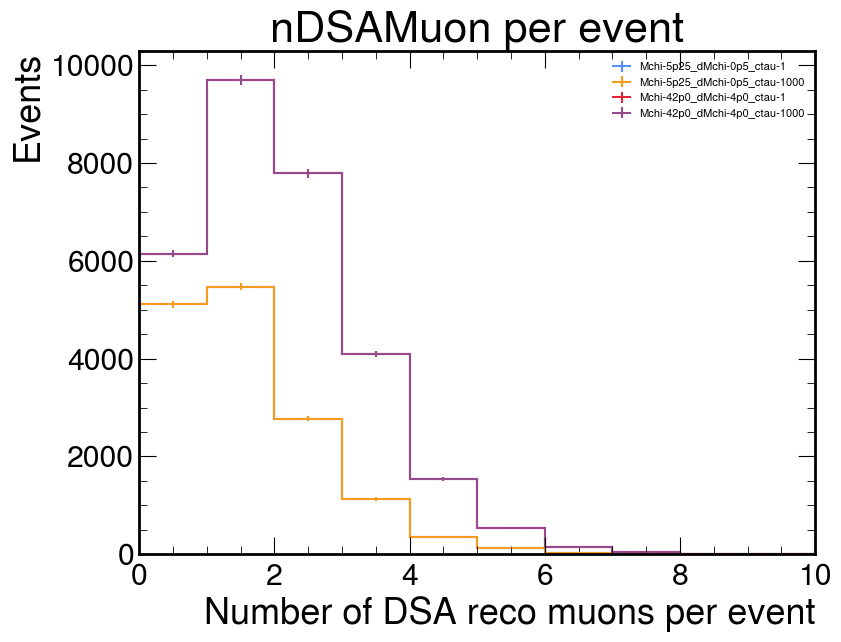

Saved: outputs/muonReco_dsaID_checks_selectedSamples_linear/plots/selectedSamples_nDSAMuon_per_event_linear_x0to10.png
Saved: outputs/muonReco_dsaID_checks_selectedSamples_linear/plots/selectedSamples_nDSAMuon_per_event_linear_x0to10.pdf


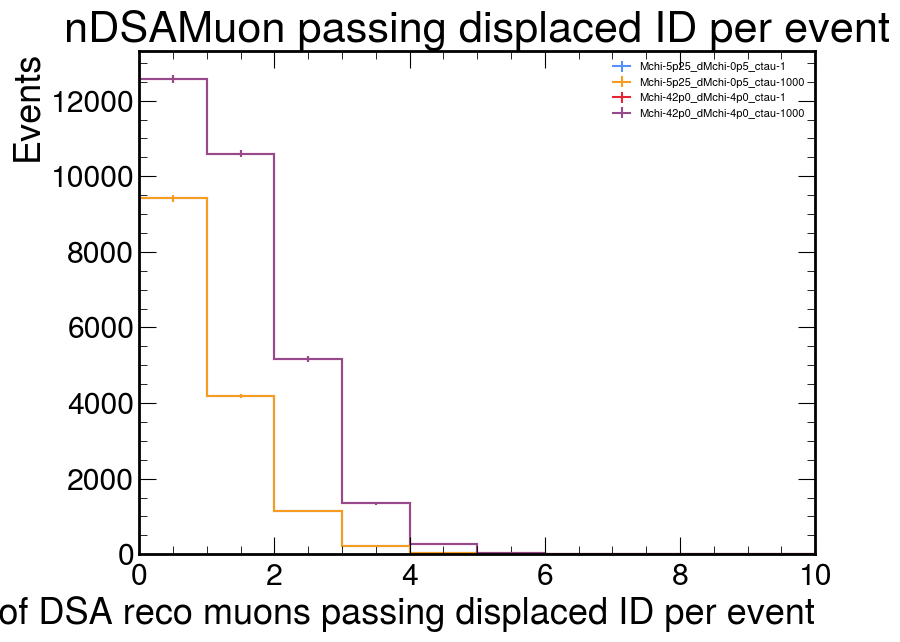

Saved: outputs/muonReco_dsaID_checks_selectedSamples_linear/plots/selectedSamples_nDSAMuon_passDisplacedID_per_event_linear_x0to10.png
Saved: outputs/muonReco_dsaID_checks_selectedSamples_linear/plots/selectedSamples_nDSAMuon_passDisplacedID_per_event_linear_x0to10.pdf


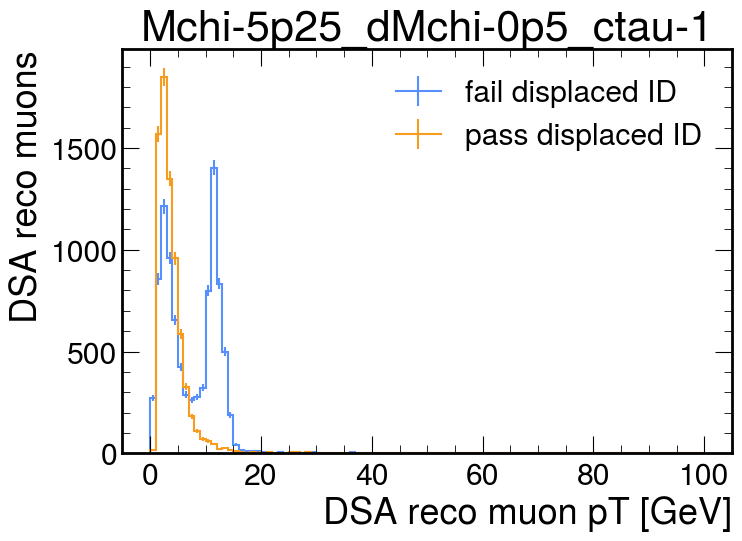

Saved: outputs/muonReco_dsaID_checks_selectedSamples_linear/plots/Mchi-5p25_dMchi-0p5_ctau-1_dsaMuon_pt_fail_vs_pass_displacedID_linear.png
Saved: outputs/muonReco_dsaID_checks_selectedSamples_linear/plots/Mchi-5p25_dMchi-0p5_ctau-1_dsaMuon_pt_fail_vs_pass_displacedID_linear.pdf


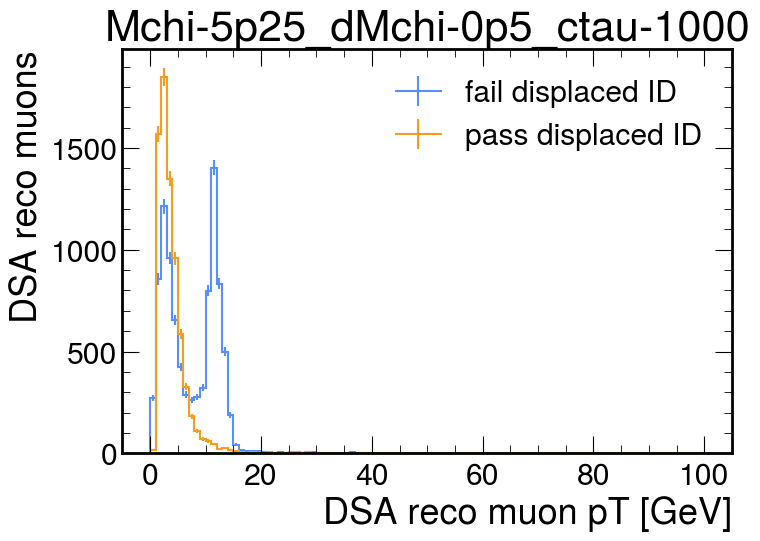

Saved: outputs/muonReco_dsaID_checks_selectedSamples_linear/plots/Mchi-5p25_dMchi-0p5_ctau-1000_dsaMuon_pt_fail_vs_pass_displacedID_linear.png
Saved: outputs/muonReco_dsaID_checks_selectedSamples_linear/plots/Mchi-5p25_dMchi-0p5_ctau-1000_dsaMuon_pt_fail_vs_pass_displacedID_linear.pdf


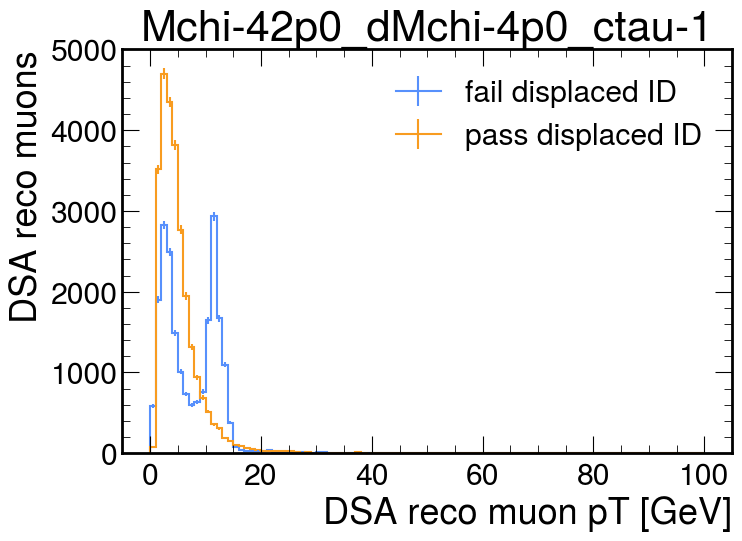

Saved: outputs/muonReco_dsaID_checks_selectedSamples_linear/plots/Mchi-42p0_dMchi-4p0_ctau-1_dsaMuon_pt_fail_vs_pass_displacedID_linear.png
Saved: outputs/muonReco_dsaID_checks_selectedSamples_linear/plots/Mchi-42p0_dMchi-4p0_ctau-1_dsaMuon_pt_fail_vs_pass_displacedID_linear.pdf


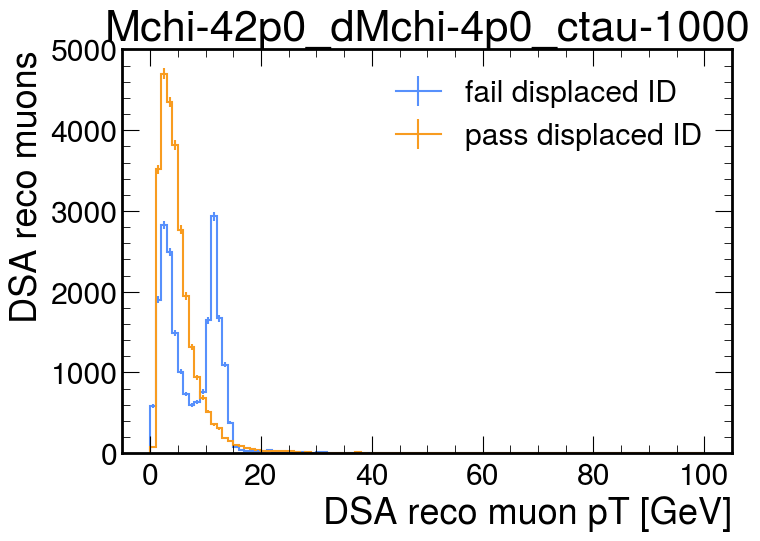

Saved: outputs/muonReco_dsaID_checks_selectedSamples_linear/plots/Mchi-42p0_dMchi-4p0_ctau-1000_dsaMuon_pt_fail_vs_pass_displacedID_linear.png
Saved: outputs/muonReco_dsaID_checks_selectedSamples_linear/plots/Mchi-42p0_dMchi-4p0_ctau-1000_dsaMuon_pt_fail_vs_pass_displacedID_linear.pdf
Saved pT histogram CSV: outputs/muonReco_dsaID_checks_selectedSamples_linear/csv/selectedSamples_dsaMuon_pt_fail_vs_pass_displacedID_bins.csv


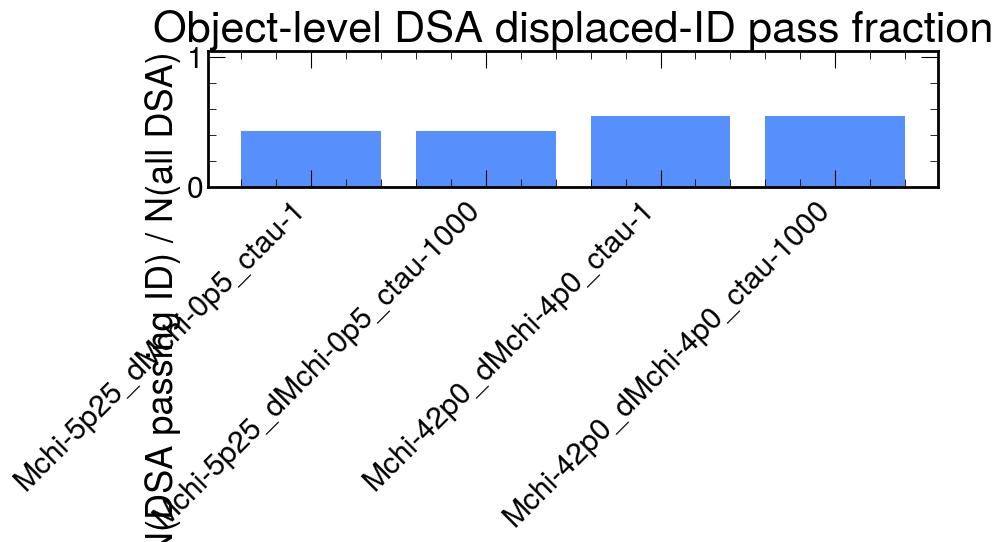

Saved: outputs/muonReco_dsaID_checks_selectedSamples_linear/plots/selectedSamples_objectLevel_dsaID_passFraction_linear.png
Saved: outputs/muonReco_dsaID_checks_selectedSamples_linear/plots/selectedSamples_objectLevel_dsaID_passFraction_linear.pdf


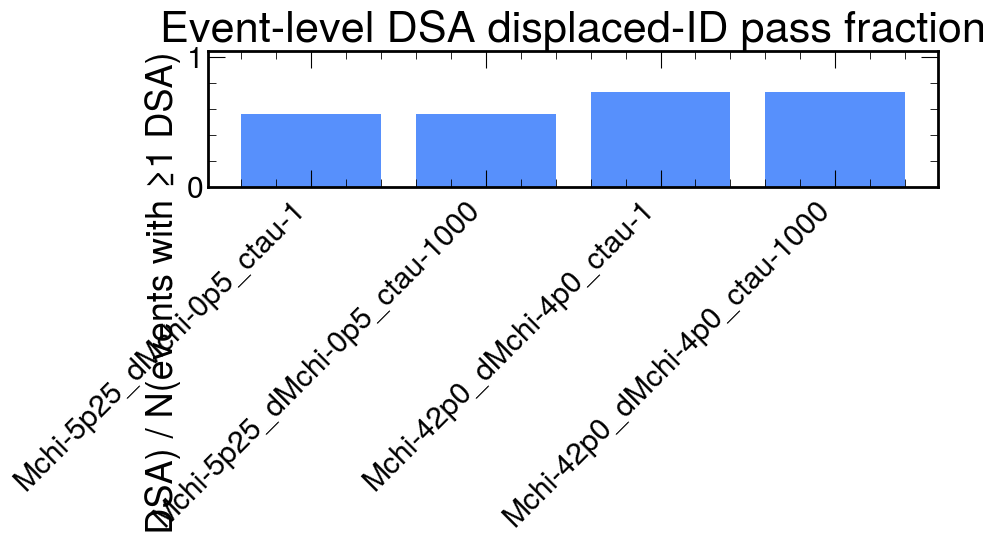

Saved: outputs/muonReco_dsaID_checks_selectedSamples_linear/plots/selectedSamples_eventLevel_dsaID_passFraction_linear.png
Saved: outputs/muonReco_dsaID_checks_selectedSamples_linear/plots/selectedSamples_eventLevel_dsaID_passFraction_linear.pdf


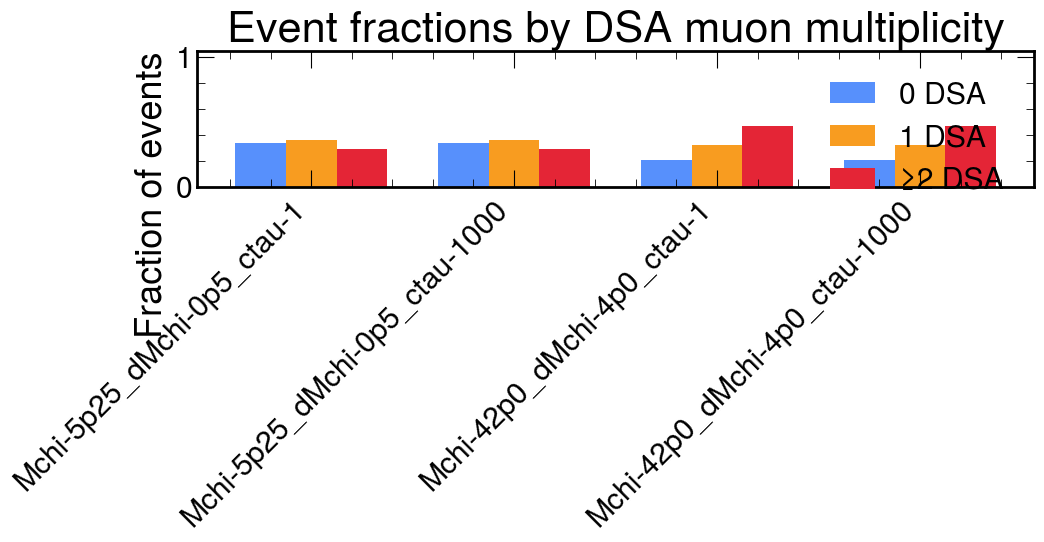

Saved: outputs/muonReco_dsaID_checks_selectedSamples_linear/plots/selectedSamples_eventFractions_0_1_ge2_DSA_linear.png
Saved: outputs/muonReco_dsaID_checks_selectedSamples_linear/plots/selectedSamples_eventFractions_0_1_ge2_DSA_linear.pdf


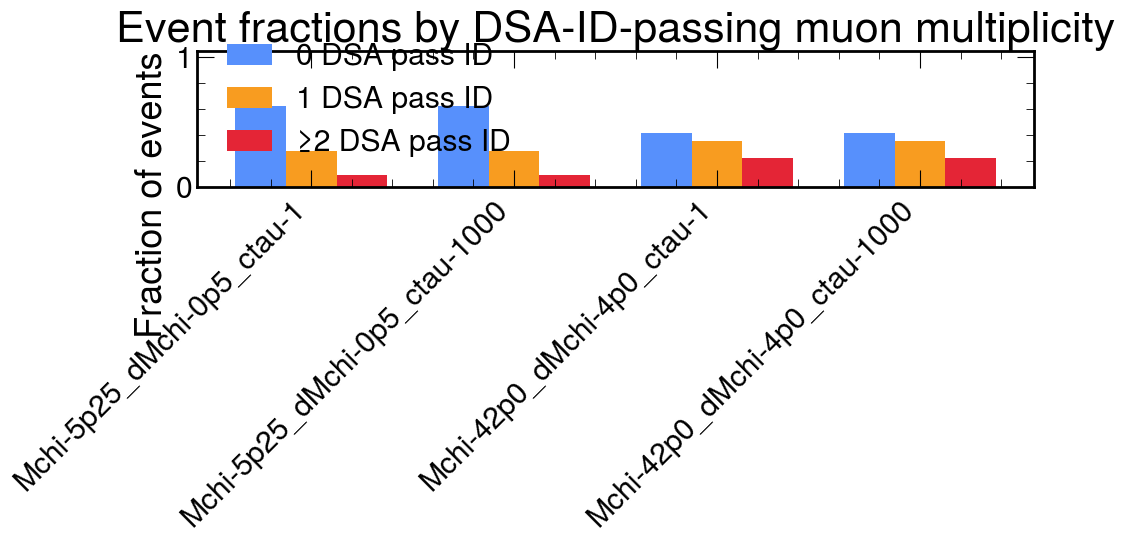

Saved: outputs/muonReco_dsaID_checks_selectedSamples_linear/plots/selectedSamples_eventFractions_0_1_ge2_DSA_passDisplacedID_linear.png
Saved: outputs/muonReco_dsaID_checks_selectedSamples_linear/plots/selectedSamples_eventFractions_0_1_ge2_DSA_passDisplacedID_linear.pdf

Done
Summary CSV: outputs/muonReco_dsaID_checks_selectedSamples_linear/csv/selectedSamples_dsaID_summary.csv
pT CSV:      outputs/muonReco_dsaID_checks_selectedSamples_linear/csv/selectedSamples_dsaMuon_pt_fail_vs_pass_displacedID_bins.csv
Plots:       outputs/muonReco_dsaID_checks_selectedSamples_linear/plots


In [6]:
# ============================================================
# Selected sample DSA reco diagnostics for Tova meeting
#
# Produces linear-scale plots:
#   1) nDSAMuon per event, x-axis 0 to 10
#   2) nDSAMuon passing displaced ID per event, x-axis 0 to 10
#   3) DSA pT distribution, fail vs pass displaced ID
#   4) Object-level DSA ID pass fraction
#   5) Event-level DSA ID pass fraction
#   6) 0/1/≥2 DSA event fractions
#   7) 0/1/≥2 DSA-ID event fractions
#
# Also exports CSVs.
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import coffea.util as util

try:
    import mplhep as hep
    hep.style.use("CMS")
    HAS_MPLHEP = True
except Exception:
    HAS_MPLHEP = False

# -----------------------------
# Load histos if not already loaded
# -----------------------------
if "histos" not in globals():
    coffea_file = "outputs/muonReco_dsaID_checks_allSamples_allEvents/muonReco_dsaID_checks_allSamples_allEvents.coffea"
    print(f"histos not found in memory. Loading: {coffea_file}")
    histos = util.load(coffea_file)

# -----------------------------
# Output directories
# -----------------------------
outdir = "outputs/muonReco_dsaID_checks_selectedSamples_linear"
plotdir = f"{outdir}/plots"
csvdir = f"{outdir}/csv"

os.makedirs(plotdir, exist_ok=True)
os.makedirs(csvdir, exist_ok=True)

# -----------------------------
# Target samples requested
# -----------------------------
target_sample_keys = [
    "Mchi-5p25_dMchi-0p5_ctau-1",
    "Mchi-5p25_dMchi-0p5_ctau-1000",
    "Mchi-42p0_dMchi-4p0_ctau-1",
    "Mchi-42p0_dMchi-4p0_ctau-1000",
]

# -----------------------------
# Helpers
# -----------------------------
def sanitize_name(x):
    return str(x).replace("/", "_").replace(" ", "_").replace(".", "p")


def savefig(path):
    plt.tight_layout()
    plt.savefig(path, dpi=200)
    plt.savefig(path.replace(".png", ".pdf"))
    plt.show()
    print(f"Saved: {path}")
    print(f"Saved: {path.replace('.png', '.pdf')}")


def get_samp_axis(h):
    axis_names = [ax.name for ax in h.axes]
    if "samp" in axis_names:
        return "samp"
    if "sample" in axis_names:
        return "sample"
    raise RuntimeError(f"Could not find sample axis. Axes are: {axis_names}")


def get_values_edges_errors(h1d):
    values = np.asarray(h1d.values())
    variances = h1d.variances()

    if variances is not None:
        errors = np.sqrt(variances)
    else:
        errors = np.sqrt(values)

    errors = np.asarray(errors)

    # Do not draw error bars for empty bins
    errors = np.where(values > 0, errors, 0.0)

    edges = np.asarray(h1d.axes[0].edges)
    centers = 0.5 * (edges[:-1] + edges[1:])

    return values, errors, edges, centers


def match_requested_samples(available_samples, target_keys):
    matched = {}

    for key in target_keys:
        hits = [s for s in available_samples if key in str(s)]

        # Fallback for possible decimal-style names
        if len(hits) == 0:
            alt = (
                key.replace("5p25", "5.25")
                   .replace("0p5", "0.5")
                   .replace("42p0", "42.0")
                   .replace("4p0", "4.0")
            )
            hits = [s for s in available_samples if alt in str(s)]

        if len(hits) == 0:
            print(f"[WARNING] No sample matched requested key: {key}")
            matched[key] = None
        elif len(hits) > 1:
            print(f"[WARNING] Multiple samples matched {key}; using first:")
            for h in hits:
                print(f"  {h}")
            matched[key] = hits[0]
        else:
            matched[key] = hits[0]

    return matched


def histplot_linear_nozero_errors(h_s, label=None, max_x=None):
    values, errors, edges, centers = get_values_edges_errors(h_s)

    if max_x is not None:
        keep = edges[:-1] < max_x
        values_plot = values[keep]
        errors_plot = errors[keep]
        centers_plot = centers[keep]

        # Need edges up to the upper edge of the last kept bin
        n_keep = np.sum(keep)
        edges_plot = edges[:n_keep + 1]
    else:
        values_plot = values
        errors_plot = errors
        centers_plot = centers
        edges_plot = edges

    if HAS_MPLHEP:
        hep.histplot(
            values_plot,
            edges_plot,
            label=label,
            yerr=np.where(values_plot > 0, errors_plot, 0.0),
        )
    else:
        plt.step(edges_plot[:-1], values_plot, where="post", label=label)
        nonzero = values_plot > 0
        plt.errorbar(
            centers_plot[nonzero],
            values_plot[nonzero],
            yerr=errors_plot[nonzero],
            fmt="none",
        )


# -----------------------------
# Basic histogram checks
# -----------------------------
required_hists = [
    "muon_reco_counts",
    "n_dsa_muons",
    "n_dsa_muons_pass_id",
    "dsa_muon_pt_pass_id",
]

missing = [h for h in required_hists if h not in histos]
if missing:
    raise RuntimeError(f"Missing required histograms: {missing}")

counts_h = histos["muon_reco_counts"]
counts_samp_axis = get_samp_axis(counts_h)
quantity_axis = "quantity"

available_samples = list(counts_h.axes[counts_samp_axis])
matched_samples = match_requested_samples(available_samples, target_sample_keys)

print("=" * 100)
print("Requested sample matching")
print("=" * 100)
for key, samp in matched_samples.items():
    print(f"{key:40s} -> {samp}")

selected_pairs = [(key, samp) for key, samp in matched_samples.items() if samp is not None]

if len(selected_pairs) == 0:
    raise RuntimeError("None of the requested samples were found in histos.")

# -----------------------------
# Build summary table
# -----------------------------
summary_rows = []

for key, samp in selected_pairs:
    vals = {}

    for q in counts_h.axes[quantity_axis]:
        vals[q] = float(counts_h[{counts_samp_axis: samp, quantity_axis: q}].value)

    n_events = vals.get("n_events", 0.0)

    n_dsa = vals.get("n_dsa_reco_muons", 0.0)
    n_dsa_pass = vals.get("n_dsa_reco_muons_pass_id", 0.0)

    n_events_with_dsa = vals.get("n_events_with_dsa", 0.0)
    n_events_with_dsa_pass_id = vals.get("n_events_with_dsa_pass_id", 0.0)

    row = {
        "requested_sample": key,
        "actual_sample": samp,
        "n_events": n_events,

        "n_dsa_reco_muons": n_dsa,
        "n_dsa_reco_muons_pass_id": n_dsa_pass,
        "object_level_dsa_id_pass_fraction": n_dsa_pass / n_dsa if n_dsa > 0 else np.nan,

        "n_events_with_dsa": n_events_with_dsa,
        "n_events_with_dsa_pass_id": n_events_with_dsa_pass_id,
        "event_level_dsa_id_pass_fraction": n_events_with_dsa_pass_id / n_events_with_dsa if n_events_with_dsa > 0 else np.nan,

        "n_events_0_dsa": vals.get("n_events_0_dsa", np.nan),
        "n_events_1_dsa": vals.get("n_events_1_dsa", np.nan),
        "n_events_ge2_dsa": vals.get("n_events_ge2_dsa", np.nan),

        "n_events_0_dsa_pass_id": vals.get("n_events_0_dsa_pass_id", np.nan),
        "n_events_1_dsa_pass_id": vals.get("n_events_1_dsa_pass_id", np.nan),
        "n_events_ge2_dsa_pass_id": vals.get("n_events_ge2_dsa_pass_id", np.nan),

        "frac_events_0_dsa": vals.get("n_events_0_dsa", 0.0) / n_events if n_events > 0 else np.nan,
        "frac_events_1_dsa": vals.get("n_events_1_dsa", 0.0) / n_events if n_events > 0 else np.nan,
        "frac_events_ge2_dsa": vals.get("n_events_ge2_dsa", 0.0) / n_events if n_events > 0 else np.nan,

        "frac_events_0_dsa_pass_id": vals.get("n_events_0_dsa_pass_id", 0.0) / n_events if n_events > 0 else np.nan,
        "frac_events_1_dsa_pass_id": vals.get("n_events_1_dsa_pass_id", 0.0) / n_events if n_events > 0 else np.nan,
        "frac_events_ge2_dsa_pass_id": vals.get("n_events_ge2_dsa_pass_id", 0.0) / n_events if n_events > 0 else np.nan,
    }

    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)

summary_csv = f"{csvdir}/selectedSamples_dsaID_summary.csv"
summary_df.to_csv(summary_csv, index=False)

print("\n" + "=" * 100)
print("Selected-sample DSA-ID summary")
print("=" * 100)
print(summary_df.to_string(index=False))
print(f"\nSaved summary CSV: {summary_csv}")

# -----------------------------
# Plot 1: nDSAMuon per event
# Linear scale, x-axis 0 to 10
# -----------------------------
h_n_dsa = histos["n_dsa_muons"]
h_n_dsa_samp_axis = get_samp_axis(h_n_dsa)

plt.figure(figsize=(9, 7))

for key, samp in selected_pairs:
    h_s = h_n_dsa[{h_n_dsa_samp_axis: samp}]
    histplot_linear_nozero_errors(h_s, label=key, max_x=10)

plt.xlim(0, 10)
plt.xlabel("Number of DSA reco muons per event")
plt.ylabel("Events")
plt.title("nDSAMuon per event")
plt.legend(fontsize=8)
savefig(f"{plotdir}/selectedSamples_nDSAMuon_per_event_linear_x0to10.png")

# -----------------------------
# Plot 2: nDSAMuon passing displaced ID per event
# Linear scale, x-axis 0 to 10
# -----------------------------
h_n_dsa_pass = histos["n_dsa_muons_pass_id"]
h_n_dsa_pass_samp_axis = get_samp_axis(h_n_dsa_pass)

plt.figure(figsize=(9, 7))

for key, samp in selected_pairs:
    h_s = h_n_dsa_pass[{h_n_dsa_pass_samp_axis: samp}]
    histplot_linear_nozero_errors(h_s, label=key, max_x=10)

plt.xlim(0, 10)
plt.xlabel("Number of DSA reco muons passing displaced ID per event")
plt.ylabel("Events")
plt.title("nDSAMuon passing displaced ID per event")
plt.legend(fontsize=8)
savefig(f"{plotdir}/selectedSamples_nDSAMuon_passDisplacedID_per_event_linear_x0to10.png")

# -----------------------------
# Plot 3: DSA pT distribution, fail vs pass displaced ID
# One plot per selected sample, linear scale
# -----------------------------
h_pt = histos["dsa_muon_pt_pass_id"]
h_pt_samp_axis = get_samp_axis(h_pt)

pt_rows = []

for key, samp in selected_pairs:
    safe_key = sanitize_name(key)

    h_fail = h_pt[{h_pt_samp_axis: samp, "pass_id": 0}]
    h_pass = h_pt[{h_pt_samp_axis: samp, "pass_id": 1}]

    plt.figure(figsize=(8, 6))

    histplot_linear_nozero_errors(h_fail, label="fail displaced ID", max_x=None)
    histplot_linear_nozero_errors(h_pass, label="pass displaced ID", max_x=None)

    plt.xlabel("DSA reco muon pT [GeV]")
    plt.ylabel("DSA reco muons")
    plt.title(key)
    plt.legend()
    savefig(f"{plotdir}/{safe_key}_dsaMuon_pt_fail_vs_pass_displacedID_linear.png")

    # Export per-bin pT CSV content
    for pass_id, h_s in [(0, h_fail), (1, h_pass)]:
        values, errors, edges, centers = get_values_edges_errors(h_s)

        for i in range(len(values)):
            pt_rows.append({
                "requested_sample": key,
                "actual_sample": samp,
                "pass_id": pass_id,
                "pass_label": "pass displaced ID" if pass_id == 1 else "fail displaced ID",
                "bin": i,
                "pt_low": edges[i],
                "pt_high": edges[i + 1],
                "pt_center": centers[i],
                "value": values[i],
                "error": errors[i],
            })

pt_df = pd.DataFrame(pt_rows)
pt_csv = f"{csvdir}/selectedSamples_dsaMuon_pt_fail_vs_pass_displacedID_bins.csv"
pt_df.to_csv(pt_csv, index=False)
print(f"Saved pT histogram CSV: {pt_csv}")

# -----------------------------
# Plot 4: object-level DSA ID pass fraction
# -----------------------------
plt.figure(figsize=(10, 6))

x = np.arange(len(summary_df))
y = summary_df["object_level_dsa_id_pass_fraction"].values

plt.bar(x, y)
plt.xticks(x, summary_df["requested_sample"].values, rotation=45, ha="right")
plt.ylim(0, 1.05)
plt.ylabel("N(DSA passing ID) / N(all DSA)")
plt.title("Object-level DSA displaced-ID pass fraction")
savefig(f"{plotdir}/selectedSamples_objectLevel_dsaID_passFraction_linear.png")

# -----------------------------
# Plot 5: event-level DSA ID pass fraction
# -----------------------------
plt.figure(figsize=(10, 6))

x = np.arange(len(summary_df))
y = summary_df["event_level_dsa_id_pass_fraction"].values

plt.bar(x, y)
plt.xticks(x, summary_df["requested_sample"].values, rotation=45, ha="right")
plt.ylim(0, 1.05)
plt.ylabel("N(events with ≥1 ID-passing DSA) / N(events with ≥1 DSA)")
plt.title("Event-level DSA displaced-ID pass fraction")
savefig(f"{plotdir}/selectedSamples_eventLevel_dsaID_passFraction_linear.png")

# -----------------------------
# Plot 6: 0/1/≥2 DSA muon event fractions
# -----------------------------
frac_cols = ["frac_events_0_dsa", "frac_events_1_dsa", "frac_events_ge2_dsa"]
labels = ["0 DSA", "1 DSA", "≥2 DSA"]

x = np.arange(len(summary_df))
width = 0.25

plt.figure(figsize=(11, 6))

for i, (col, lab) in enumerate(zip(frac_cols, labels)):
    plt.bar(x + (i - 1) * width, summary_df[col].values, width=width, label=lab)

plt.xticks(x, summary_df["requested_sample"].values, rotation=45, ha="right")
plt.ylim(0, 1.05)
plt.ylabel("Fraction of events")
plt.title("Event fractions by DSA muon multiplicity")
plt.legend()
savefig(f"{plotdir}/selectedSamples_eventFractions_0_1_ge2_DSA_linear.png")

# -----------------------------
# Plot 7: 0/1/≥2 DSA-ID-passing muon event fractions
# -----------------------------
frac_cols = ["frac_events_0_dsa_pass_id", "frac_events_1_dsa_pass_id", "frac_events_ge2_dsa_pass_id"]
labels = ["0 DSA pass ID", "1 DSA pass ID", "≥2 DSA pass ID"]

x = np.arange(len(summary_df))
width = 0.25

plt.figure(figsize=(11, 6))

for i, (col, lab) in enumerate(zip(frac_cols, labels)):
    plt.bar(x + (i - 1) * width, summary_df[col].values, width=width, label=lab)

plt.xticks(x, summary_df["requested_sample"].values, rotation=45, ha="right")
plt.ylim(0, 1.05)
plt.ylabel("Fraction of events")
plt.title("Event fractions by DSA-ID-passing muon multiplicity")
plt.legend()
savefig(f"{plotdir}/selectedSamples_eventFractions_0_1_ge2_DSA_passDisplacedID_linear.png")

print("\n" + "=" * 100)
print("Done")
print("=" * 100)
print(f"Summary CSV: {summary_csv}")
print(f"pT CSV:      {pt_csv}")
print(f"Plots:       {plotdir}")
print("=" * 100)

[WARNING] Multiple samples matched Mchi-5p25_dMchi-0p5_ctau-1; using first:
  sig_2022EE_Mchi-5p25_dMchi-0p5_ctau-1000
  sig_2022EE_Mchi-5p25_dMchi-0p5_ctau-100
  sig_2022EE_Mchi-5p25_dMchi-0p5_ctau-10
  sig_2022EE_Mchi-5p25_dMchi-0p5_ctau-1
[WARNING] Multiple samples matched Mchi-42p0_dMchi-4p0_ctau-1; using first:
  sig_2022EE_Mchi-42p0_dMchi-4p0_ctau-1000
  sig_2022EE_Mchi-42p0_dMchi-4p0_ctau-100
  sig_2022EE_Mchi-42p0_dMchi-4p0_ctau-10
  sig_2022EE_Mchi-42p0_dMchi-4p0_ctau-1
Requested sample matching
Mchi-5p25_dMchi-0p5_ctau-1               -> sig_2022EE_Mchi-5p25_dMchi-0p5_ctau-1000
Mchi-5p25_dMchi-0p5_ctau-1000            -> sig_2022EE_Mchi-5p25_dMchi-0p5_ctau-1000
Mchi-42p0_dMchi-4p0_ctau-1               -> sig_2022EE_Mchi-42p0_dMchi-4p0_ctau-1000
Mchi-42p0_dMchi-4p0_ctau-1000            -> sig_2022EE_Mchi-42p0_dMchi-4p0_ctau-1000

Selected-sample DSA-ID summary
            label  n_events  n_dsa_reco_muons  n_dsa_reco_muons_pass_id  object_level_dsa_id_pass_fraction  n_events_w

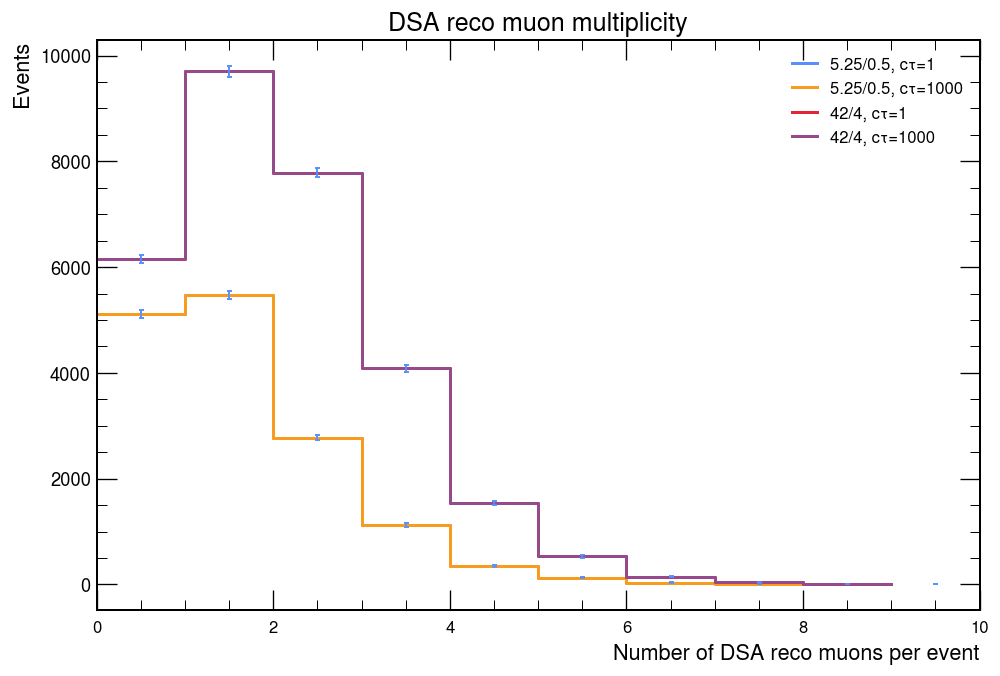

Saved: outputs/muonReco_dsaID_checks_selectedSamples_presentable/plots/presentable_nDSAMuon_per_event.png
Saved: outputs/muonReco_dsaID_checks_selectedSamples_presentable/plots/presentable_nDSAMuon_per_event.pdf


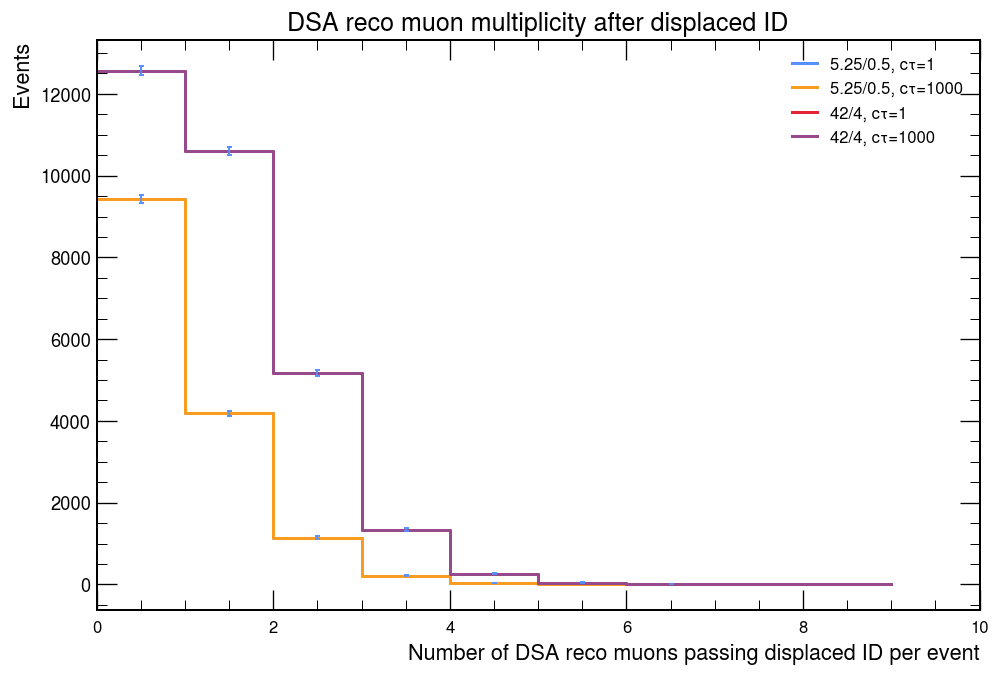

Saved: outputs/muonReco_dsaID_checks_selectedSamples_presentable/plots/presentable_nDSAMuon_passDisplacedID_per_event.png
Saved: outputs/muonReco_dsaID_checks_selectedSamples_presentable/plots/presentable_nDSAMuon_passDisplacedID_per_event.pdf


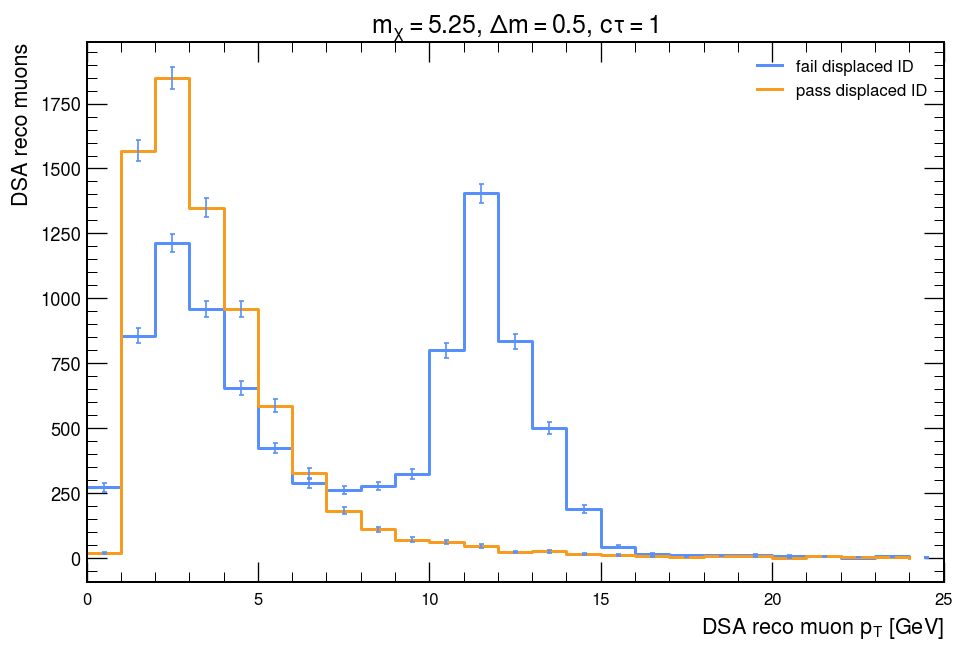

Saved: outputs/muonReco_dsaID_checks_selectedSamples_presentable/plots/presentable_Mchi-5p25_dMchi-0p5_ctau-1_dsaMuon_pt_fail_vs_pass_displacedID.png
Saved: outputs/muonReco_dsaID_checks_selectedSamples_presentable/plots/presentable_Mchi-5p25_dMchi-0p5_ctau-1_dsaMuon_pt_fail_vs_pass_displacedID.pdf


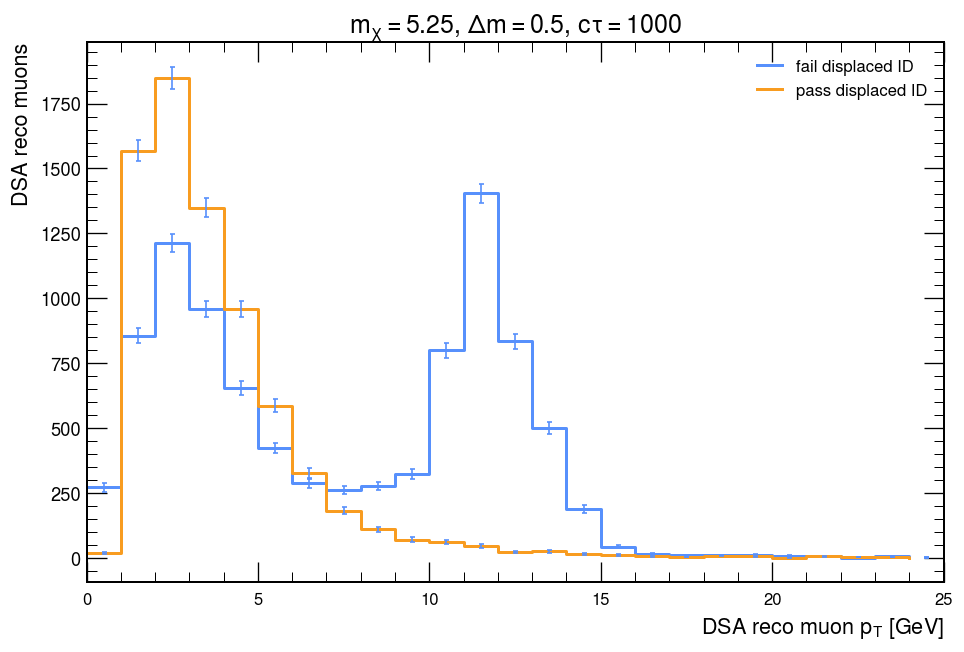

Saved: outputs/muonReco_dsaID_checks_selectedSamples_presentable/plots/presentable_Mchi-5p25_dMchi-0p5_ctau-1000_dsaMuon_pt_fail_vs_pass_displacedID.png
Saved: outputs/muonReco_dsaID_checks_selectedSamples_presentable/plots/presentable_Mchi-5p25_dMchi-0p5_ctau-1000_dsaMuon_pt_fail_vs_pass_displacedID.pdf


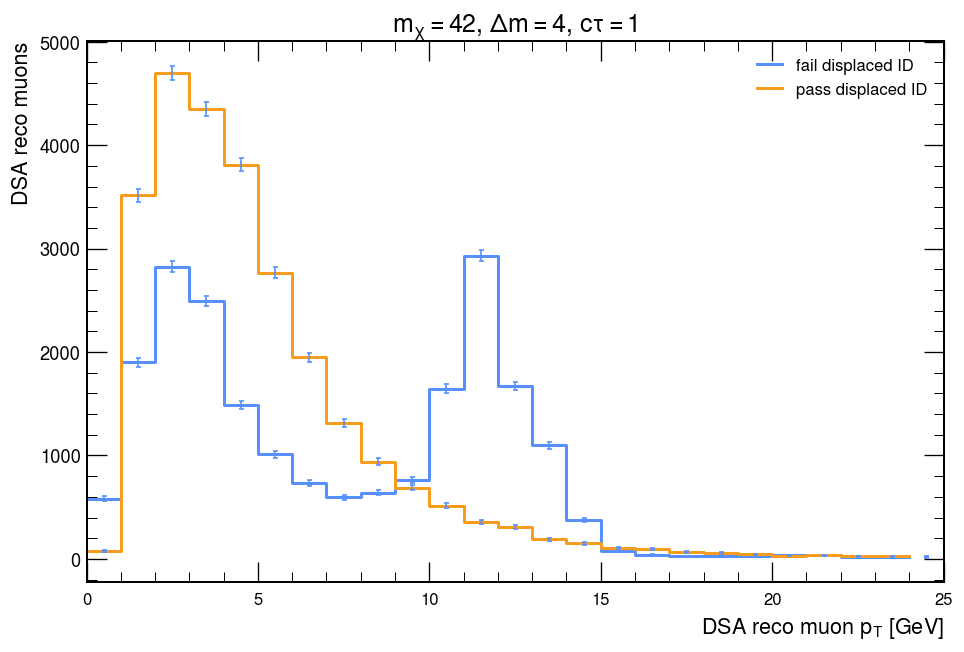

Saved: outputs/muonReco_dsaID_checks_selectedSamples_presentable/plots/presentable_Mchi-42p0_dMchi-4p0_ctau-1_dsaMuon_pt_fail_vs_pass_displacedID.png
Saved: outputs/muonReco_dsaID_checks_selectedSamples_presentable/plots/presentable_Mchi-42p0_dMchi-4p0_ctau-1_dsaMuon_pt_fail_vs_pass_displacedID.pdf


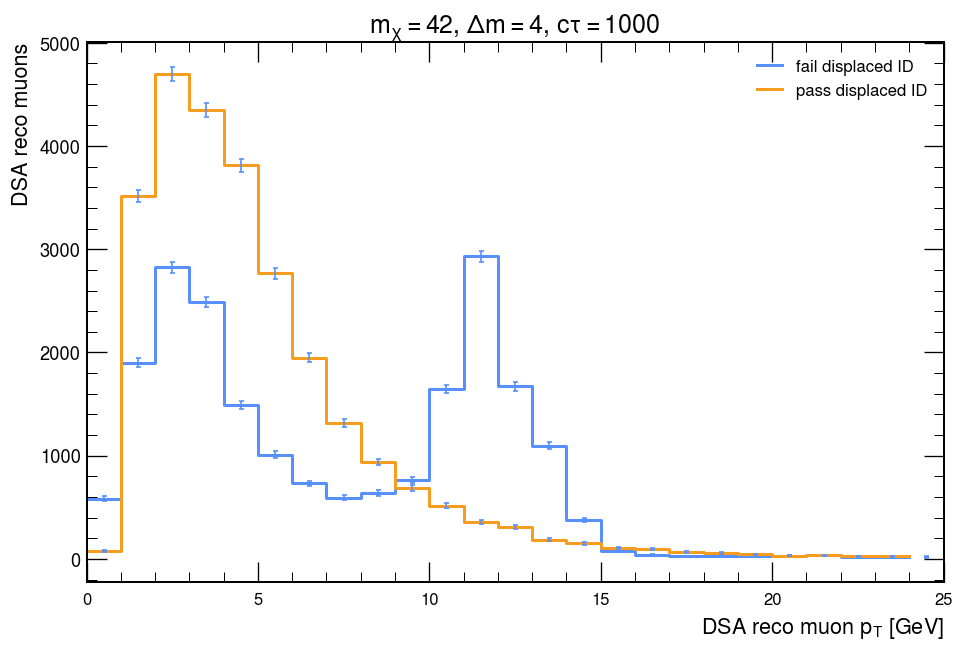

Saved: outputs/muonReco_dsaID_checks_selectedSamples_presentable/plots/presentable_Mchi-42p0_dMchi-4p0_ctau-1000_dsaMuon_pt_fail_vs_pass_displacedID.png
Saved: outputs/muonReco_dsaID_checks_selectedSamples_presentable/plots/presentable_Mchi-42p0_dMchi-4p0_ctau-1000_dsaMuon_pt_fail_vs_pass_displacedID.pdf
Saved pT histogram CSV: outputs/muonReco_dsaID_checks_selectedSamples_presentable/csv/selectedSamples_dsaMuon_pt_fail_vs_pass_displacedID_bins_presentable.csv


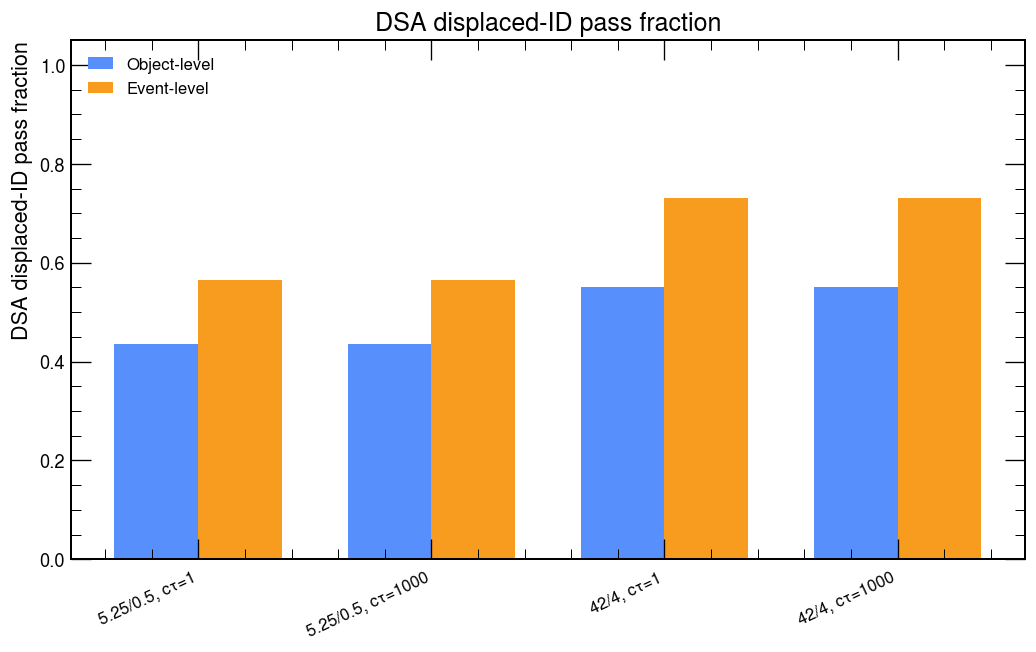

Saved: outputs/muonReco_dsaID_checks_selectedSamples_presentable/plots/presentable_dsaID_object_event_passFraction.png
Saved: outputs/muonReco_dsaID_checks_selectedSamples_presentable/plots/presentable_dsaID_object_event_passFraction.pdf


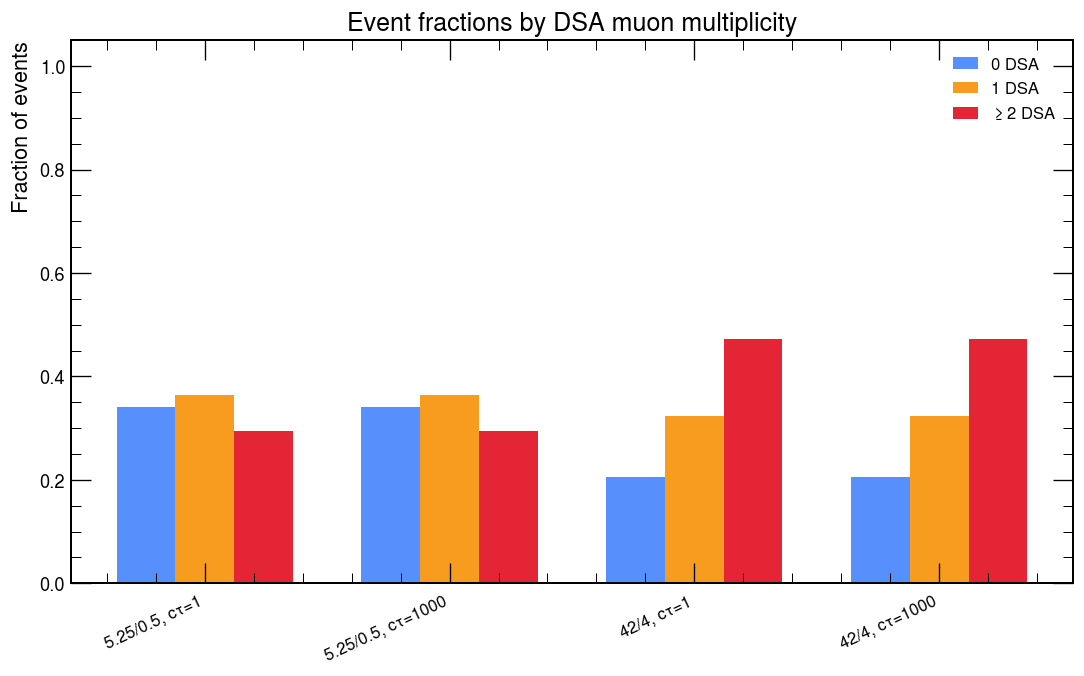

Saved: outputs/muonReco_dsaID_checks_selectedSamples_presentable/plots/presentable_eventFractions_0_1_ge2_DSA.png
Saved: outputs/muonReco_dsaID_checks_selectedSamples_presentable/plots/presentable_eventFractions_0_1_ge2_DSA.pdf


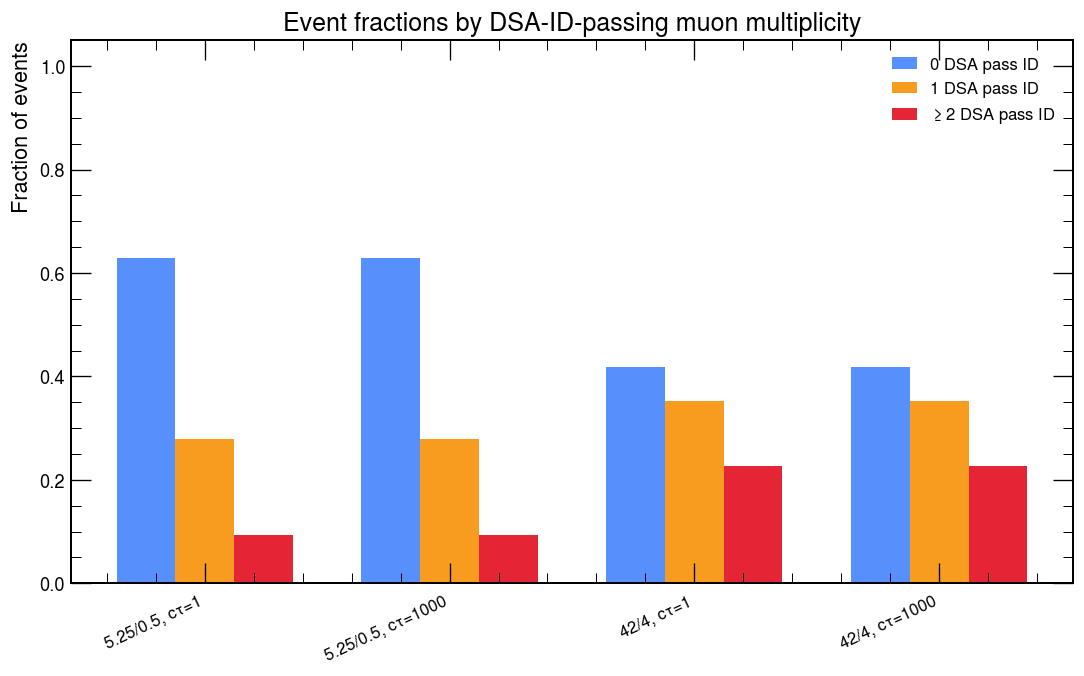

Saved: outputs/muonReco_dsaID_checks_selectedSamples_presentable/plots/presentable_eventFractions_0_1_ge2_DSA_passDisplacedID.png
Saved: outputs/muonReco_dsaID_checks_selectedSamples_presentable/plots/presentable_eventFractions_0_1_ge2_DSA_passDisplacedID.pdf

Done: presentation-quality plots
Summary CSV: outputs/muonReco_dsaID_checks_selectedSamples_presentable/csv/selectedSamples_dsaID_summary_presentable.csv
pT CSV:      outputs/muonReco_dsaID_checks_selectedSamples_presentable/csv/selectedSamples_dsaMuon_pt_fail_vs_pass_displacedID_bins_presentable.csv
Plots:       outputs/muonReco_dsaID_checks_selectedSamples_presentable/plots


In [7]:
# ============================================================
# Presentation-quality selected-sample DSA reco diagnostics
# Cleaner plots for meeting
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import coffea.util as util

# DO NOT use hep.style.use("CMS") here; it makes fonts too large for these plots.
try:
    import mplhep as hep
    HAS_MPLHEP = True
except Exception:
    HAS_MPLHEP = False

# -----------------------------
# Load histos if needed
# -----------------------------
if "histos" not in globals():
    coffea_file = "outputs/muonReco_dsaID_checks_allSamples_allEvents/muonReco_dsaID_checks_allSamples_allEvents.coffea"
    print(f"histos not found in memory. Loading: {coffea_file}")
    histos = util.load(coffea_file)

# -----------------------------
# Output directories
# -----------------------------
outdir = "outputs/muonReco_dsaID_checks_selectedSamples_presentable"
plotdir = f"{outdir}/plots"
csvdir = f"{outdir}/csv"

os.makedirs(plotdir, exist_ok=True)
os.makedirs(csvdir, exist_ok=True)

# -----------------------------
# Plot style
# -----------------------------
plt.rcParams.update({
    "figure.figsize": (8, 5.5),
    "figure.dpi": 120,
    "savefig.dpi": 250,
    "font.size": 12,
    "axes.titlesize": 15,
    "axes.labelsize": 13,
    "xtick.labelsize": 10,
    "ytick.labelsize": 11,
    "legend.fontsize": 10,
    "axes.linewidth": 1.2,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
})

# -----------------------------
# Target samples
# -----------------------------
target_sample_keys = [
    "Mchi-5p25_dMchi-0p5_ctau-1",
    "Mchi-5p25_dMchi-0p5_ctau-1000",
    "Mchi-42p0_dMchi-4p0_ctau-1",
    "Mchi-42p0_dMchi-4p0_ctau-1000",
]

pretty_label = {
    "Mchi-5p25_dMchi-0p5_ctau-1": r"$m_\chi=5.25$, $\Delta m=0.5$, $c\tau=1$",
    "Mchi-5p25_dMchi-0p5_ctau-1000": r"$m_\chi=5.25$, $\Delta m=0.5$, $c\tau=1000$",
    "Mchi-42p0_dMchi-4p0_ctau-1": r"$m_\chi=42$, $\Delta m=4$, $c\tau=1$",
    "Mchi-42p0_dMchi-4p0_ctau-1000": r"$m_\chi=42$, $\Delta m=4$, $c\tau=1000$",
}

short_label = {
    "Mchi-5p25_dMchi-0p5_ctau-1": "5.25/0.5, cτ=1",
    "Mchi-5p25_dMchi-0p5_ctau-1000": "5.25/0.5, cτ=1000",
    "Mchi-42p0_dMchi-4p0_ctau-1": "42/4, cτ=1",
    "Mchi-42p0_dMchi-4p0_ctau-1000": "42/4, cτ=1000",
}

# -----------------------------
# Helpers
# -----------------------------
def sanitize_name(x):
    return str(x).replace("/", "_").replace(" ", "_").replace(".", "p").replace("$", "")


def savefig(path):
    plt.tight_layout()
    plt.savefig(path, bbox_inches="tight")
    plt.savefig(path.replace(".png", ".pdf"), bbox_inches="tight")
    plt.show()
    print(f"Saved: {path}")
    print(f"Saved: {path.replace('.png', '.pdf')}")


def get_samp_axis(h):
    axis_names = [ax.name for ax in h.axes]
    if "samp" in axis_names:
        return "samp"
    if "sample" in axis_names:
        return "sample"
    raise RuntimeError(f"Could not find sample axis. Axes are: {axis_names}")


def get_values_edges_errors(h1d):
    values = np.asarray(h1d.values())
    variances = h1d.variances()

    if variances is not None:
        errors = np.sqrt(variances)
    else:
        errors = np.sqrt(values)

    errors = np.asarray(errors)
    errors = np.where(values > 0, errors, 0.0)

    edges = np.asarray(h1d.axes[0].edges)
    centers = 0.5 * (edges[:-1] + edges[1:])

    return values, errors, edges, centers


def match_requested_samples(available_samples, target_keys):
    matched = {}

    for key in target_keys:
        hits = [s for s in available_samples if key in str(s)]

        if len(hits) == 0:
            alt = (
                key.replace("5p25", "5.25")
                   .replace("0p5", "0.5")
                   .replace("42p0", "42.0")
                   .replace("4p0", "4.0")
            )
            hits = [s for s in available_samples if alt in str(s)]

        if len(hits) == 0:
            print(f"[WARNING] No sample matched requested key: {key}")
            matched[key] = None
        elif len(hits) > 1:
            print(f"[WARNING] Multiple samples matched {key}; using first:")
            for h in hits:
                print(f"  {h}")
            matched[key] = hits[0]
        else:
            matched[key] = hits[0]

    return matched


def plot_step_with_errors(h_s, label, max_x=None):
    values, errors, edges, centers = get_values_edges_errors(h_s)

    if max_x is not None:
        keep = edges[:-1] < max_x
        n_keep = np.sum(keep)

        values = values[:n_keep]
        errors = errors[:n_keep]
        centers = centers[:n_keep]
        edges = edges[:n_keep + 1]

    plt.step(edges[:-1], values, where="post", label=label, linewidth=1.8)

    nonzero = values > 0
    if np.any(nonzero):
        plt.errorbar(
            centers[nonzero],
            values[nonzero],
            yerr=errors[nonzero],
            fmt="none",
            linewidth=1.0,
            capsize=1.5,
        )


# -----------------------------
# Required histogram checks
# -----------------------------
required_hists = [
    "muon_reco_counts",
    "n_dsa_muons",
    "n_dsa_muons_pass_id",
    "dsa_muon_pt_pass_id",
]

missing = [h for h in required_hists if h not in histos]
if missing:
    raise RuntimeError(f"Missing required histograms: {missing}")

counts_h = histos["muon_reco_counts"]
counts_samp_axis = get_samp_axis(counts_h)
quantity_axis = "quantity"

available_samples = list(counts_h.axes[counts_samp_axis])
matched_samples = match_requested_samples(available_samples, target_sample_keys)

print("=" * 100)
print("Requested sample matching")
print("=" * 100)
for key, samp in matched_samples.items():
    print(f"{key:40s} -> {samp}")

selected_pairs = [(key, samp) for key, samp in matched_samples.items() if samp is not None]

if len(selected_pairs) == 0:
    raise RuntimeError("None of the requested samples were found in histos.")

# -----------------------------
# Build summary table
# -----------------------------
summary_rows = []

for key, samp in selected_pairs:
    vals = {}

    for q in counts_h.axes[quantity_axis]:
        vals[q] = float(counts_h[{counts_samp_axis: samp, quantity_axis: q}].value)

    n_events = vals.get("n_events", 0.0)

    n_dsa = vals.get("n_dsa_reco_muons", 0.0)
    n_dsa_pass = vals.get("n_dsa_reco_muons_pass_id", 0.0)

    n_events_with_dsa = vals.get("n_events_with_dsa", 0.0)
    n_events_with_dsa_pass_id = vals.get("n_events_with_dsa_pass_id", 0.0)

    row = {
        "sample_key": key,
        "label": short_label[key],
        "actual_sample": samp,
        "n_events": n_events,

        "n_dsa_reco_muons": n_dsa,
        "n_dsa_reco_muons_pass_id": n_dsa_pass,
        "object_level_dsa_id_pass_fraction": n_dsa_pass / n_dsa if n_dsa > 0 else np.nan,

        "n_events_with_dsa": n_events_with_dsa,
        "n_events_with_dsa_pass_id": n_events_with_dsa_pass_id,
        "event_level_dsa_id_pass_fraction": n_events_with_dsa_pass_id / n_events_with_dsa if n_events_with_dsa > 0 else np.nan,

        "n_events_0_dsa": vals.get("n_events_0_dsa", np.nan),
        "n_events_1_dsa": vals.get("n_events_1_dsa", np.nan),
        "n_events_ge2_dsa": vals.get("n_events_ge2_dsa", np.nan),

        "n_events_0_dsa_pass_id": vals.get("n_events_0_dsa_pass_id", np.nan),
        "n_events_1_dsa_pass_id": vals.get("n_events_1_dsa_pass_id", np.nan),
        "n_events_ge2_dsa_pass_id": vals.get("n_events_ge2_dsa_pass_id", np.nan),

        "frac_events_0_dsa": vals.get("n_events_0_dsa", 0.0) / n_events if n_events > 0 else np.nan,
        "frac_events_1_dsa": vals.get("n_events_1_dsa", 0.0) / n_events if n_events > 0 else np.nan,
        "frac_events_ge2_dsa": vals.get("n_events_ge2_dsa", 0.0) / n_events if n_events > 0 else np.nan,

        "frac_events_0_dsa_pass_id": vals.get("n_events_0_dsa_pass_id", 0.0) / n_events if n_events > 0 else np.nan,
        "frac_events_1_dsa_pass_id": vals.get("n_events_1_dsa_pass_id", 0.0) / n_events if n_events > 0 else np.nan,
        "frac_events_ge2_dsa_pass_id": vals.get("n_events_ge2_dsa_pass_id", 0.0) / n_events if n_events > 0 else np.nan,
    }

    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
summary_csv = f"{csvdir}/selectedSamples_dsaID_summary_presentable.csv"
summary_df.to_csv(summary_csv, index=False)

print("\n" + "=" * 100)
print("Selected-sample DSA-ID summary")
print("=" * 100)
display_cols = [
    "label",
    "n_events",
    "n_dsa_reco_muons",
    "n_dsa_reco_muons_pass_id",
    "object_level_dsa_id_pass_fraction",
    "n_events_with_dsa",
    "n_events_with_dsa_pass_id",
    "event_level_dsa_id_pass_fraction",
    "frac_events_0_dsa",
    "frac_events_1_dsa",
    "frac_events_ge2_dsa",
    "frac_events_0_dsa_pass_id",
    "frac_events_1_dsa_pass_id",
    "frac_events_ge2_dsa_pass_id",
]
print(summary_df[display_cols].to_string(index=False))
print(f"\nSaved summary CSV: {summary_csv}")

# ============================================================
# Plot A: nDSAMuon per event
# ============================================================
h_n_dsa = histos["n_dsa_muons"]
h_n_dsa_samp_axis = get_samp_axis(h_n_dsa)

plt.figure(figsize=(8.5, 5.8))

for key, samp in selected_pairs:
    h_s = h_n_dsa[{h_n_dsa_samp_axis: samp}]
    plot_step_with_errors(h_s, label=short_label[key], max_x=10)

plt.xlim(0, 10)
plt.xlabel("Number of DSA reco muons per event")
plt.ylabel("Events")
plt.title("DSA reco muon multiplicity")
plt.legend(frameon=False, loc="upper right")
savefig(f"{plotdir}/presentable_nDSAMuon_per_event.png")

# ============================================================
# Plot B: nDSAMuon passing displaced ID per event
# ============================================================
h_n_dsa_pass = histos["n_dsa_muons_pass_id"]
h_n_dsa_pass_samp_axis = get_samp_axis(h_n_dsa_pass)

plt.figure(figsize=(8.5, 5.8))

for key, samp in selected_pairs:
    h_s = h_n_dsa_pass[{h_n_dsa_pass_samp_axis: samp}]
    plot_step_with_errors(h_s, label=short_label[key], max_x=10)

plt.xlim(0, 10)
plt.xlabel("Number of DSA reco muons passing displaced ID per event")
plt.ylabel("Events")
plt.title("DSA reco muon multiplicity after displaced ID")
plt.legend(frameon=False, loc="upper right")
savefig(f"{plotdir}/presentable_nDSAMuon_passDisplacedID_per_event.png")

# ============================================================
# Plot C: DSA pT fail/pass ID, one plot per sample
# Better zoom: 0 to 25 GeV
# ============================================================
h_pt = histos["dsa_muon_pt_pass_id"]
h_pt_samp_axis = get_samp_axis(h_pt)

pt_rows = []

for key, samp in selected_pairs:
    safe_key = sanitize_name(key)

    h_fail = h_pt[{h_pt_samp_axis: samp, "pass_id": 0}]
    h_pass = h_pt[{h_pt_samp_axis: samp, "pass_id": 1}]

    plt.figure(figsize=(8.2, 5.6))

    plot_step_with_errors(h_fail, label="fail displaced ID", max_x=25)
    plot_step_with_errors(h_pass, label="pass displaced ID", max_x=25)

    plt.xlim(0, 25)
    plt.xlabel("DSA reco muon $p_T$ [GeV]")
    plt.ylabel("DSA reco muons")
    plt.title(pretty_label[key])
    plt.legend(frameon=False, loc="upper right")
    savefig(f"{plotdir}/presentable_{safe_key}_dsaMuon_pt_fail_vs_pass_displacedID.png")

    for pass_id, h_s in [(0, h_fail), (1, h_pass)]:
        values, errors, edges, centers = get_values_edges_errors(h_s)

        for i in range(len(values)):
            pt_rows.append({
                "sample_key": key,
                "label": short_label[key],
                "actual_sample": samp,
                "pass_id": pass_id,
                "pass_label": "pass displaced ID" if pass_id == 1 else "fail displaced ID",
                "bin": i,
                "pt_low": edges[i],
                "pt_high": edges[i + 1],
                "pt_center": centers[i],
                "value": values[i],
                "error": errors[i],
            })

pt_df = pd.DataFrame(pt_rows)
pt_csv = f"{csvdir}/selectedSamples_dsaMuon_pt_fail_vs_pass_displacedID_bins_presentable.csv"
pt_df.to_csv(pt_csv, index=False)
print(f"Saved pT histogram CSV: {pt_csv}")

# ============================================================
# Plot D: object/event-level ID pass fractions in one clean plot
# ============================================================
x = np.arange(len(summary_df))
width = 0.36

plt.figure(figsize=(8.8, 5.6))

plt.bar(
    x - width / 2,
    summary_df["object_level_dsa_id_pass_fraction"].values,
    width=width,
    label="Object-level",
)

plt.bar(
    x + width / 2,
    summary_df["event_level_dsa_id_pass_fraction"].values,
    width=width,
    label="Event-level",
)

plt.xticks(x, summary_df["label"].values, rotation=25, ha="right")
plt.ylim(0, 1.05)
plt.ylabel("DSA displaced-ID pass fraction")
plt.title("DSA displaced-ID pass fraction")
plt.legend(frameon=False, loc="upper left")
savefig(f"{plotdir}/presentable_dsaID_object_event_passFraction.png")

# ============================================================
# Plot E: event fractions by DSA multiplicity
# ============================================================
x = np.arange(len(summary_df))
width = 0.24

plt.figure(figsize=(9.2, 5.8))

plt.bar(x - width, summary_df["frac_events_0_dsa"].values, width=width, label="0 DSA")
plt.bar(x, summary_df["frac_events_1_dsa"].values, width=width, label="1 DSA")
plt.bar(x + width, summary_df["frac_events_ge2_dsa"].values, width=width, label=r"$\geq 2$ DSA")

plt.xticks(x, summary_df["label"].values, rotation=25, ha="right")
plt.ylim(0, 1.05)
plt.ylabel("Fraction of events")
plt.title("Event fractions by DSA muon multiplicity")
plt.legend(frameon=False, loc="upper right")
savefig(f"{plotdir}/presentable_eventFractions_0_1_ge2_DSA.png")

# ============================================================
# Plot F: event fractions by DSA-ID multiplicity
# ============================================================
x = np.arange(len(summary_df))
width = 0.24

plt.figure(figsize=(9.2, 5.8))

plt.bar(x - width, summary_df["frac_events_0_dsa_pass_id"].values, width=width, label="0 DSA pass ID")
plt.bar(x, summary_df["frac_events_1_dsa_pass_id"].values, width=width, label="1 DSA pass ID")
plt.bar(x + width, summary_df["frac_events_ge2_dsa_pass_id"].values, width=width, label=r"$\geq 2$ DSA pass ID")

plt.xticks(x, summary_df["label"].values, rotation=25, ha="right")
plt.ylim(0, 1.05)
plt.ylabel("Fraction of events")
plt.title("Event fractions by DSA-ID-passing muon multiplicity")
plt.legend(frameon=False, loc="upper right")
savefig(f"{plotdir}/presentable_eventFractions_0_1_ge2_DSA_passDisplacedID.png")

print("\n" + "=" * 100)
print("Done: presentation-quality plots")
print("=" * 100)
print(f"Summary CSV: {summary_csv}")
print(f"pT CSV:      {pt_csv}")
print(f"Plots:       {plotdir}")
print("=" * 100)

Available selected sample check
sig_2022EE_Mchi-5p25_dMchi-0p5_ctau-100                 -> sig_2022EE_Mchi-5p25_dMchi-0p5_ctau-100
sig_2022EE_Mchi-42p0_dMchi-4p0_ctau-1                   -> sig_2022EE_Mchi-42p0_dMchi-4p0_ctau-1

Two-point DSA-ID summary
           label  n_events  n_dsa_reco_muons  n_dsa_reco_muons_pass_id  object_level_dsa_id_pass_fraction  n_events_with_dsa  n_events_with_dsa_pass_id  event_level_dsa_id_pass_fraction  frac_events_0_dsa  frac_events_1_dsa  frac_events_ge2_dsa  frac_events_0_dsa_pass_id  frac_events_1_dsa_pass_id  frac_events_ge2_dsa_pass_id
5.25/0.5, cτ=100   30000.0           42021.0                   22341.0                           0.531663            22232.0                    15207.0                          0.684014           0.258933           0.332133             0.408933                     0.4931                   0.320167                     0.186733
      42/4, cτ=1   20000.0           32911.0                   19580.0                    

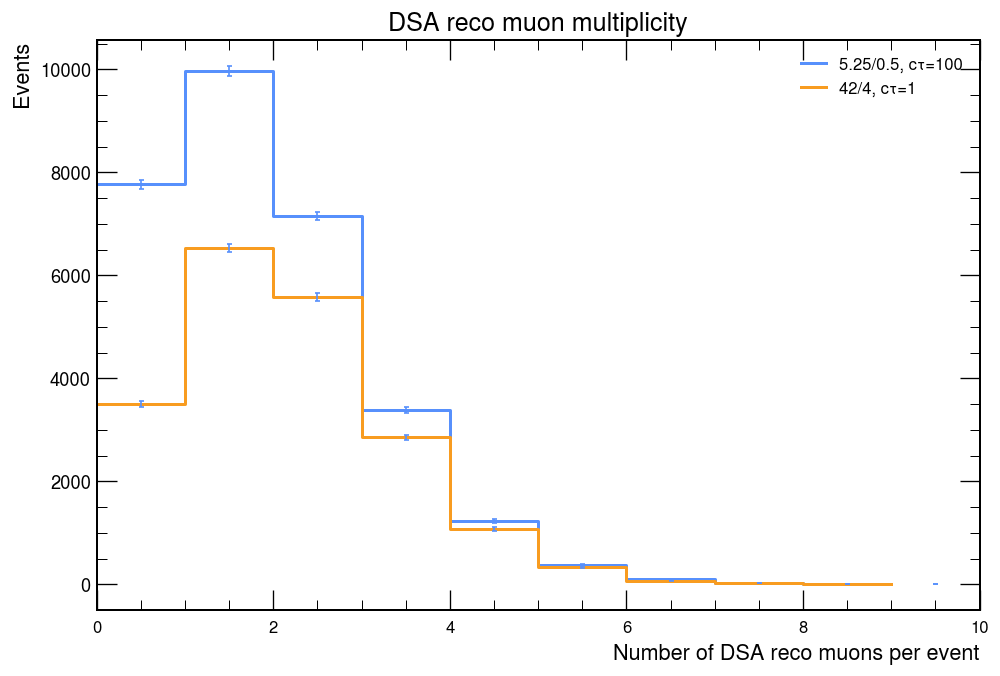

Saved: outputs/muonReco_dsaID_checks_twoPoints_presentable/plots/twoPoints_nDSAMuon_per_event.png
Saved: outputs/muonReco_dsaID_checks_twoPoints_presentable/plots/twoPoints_nDSAMuon_per_event.pdf


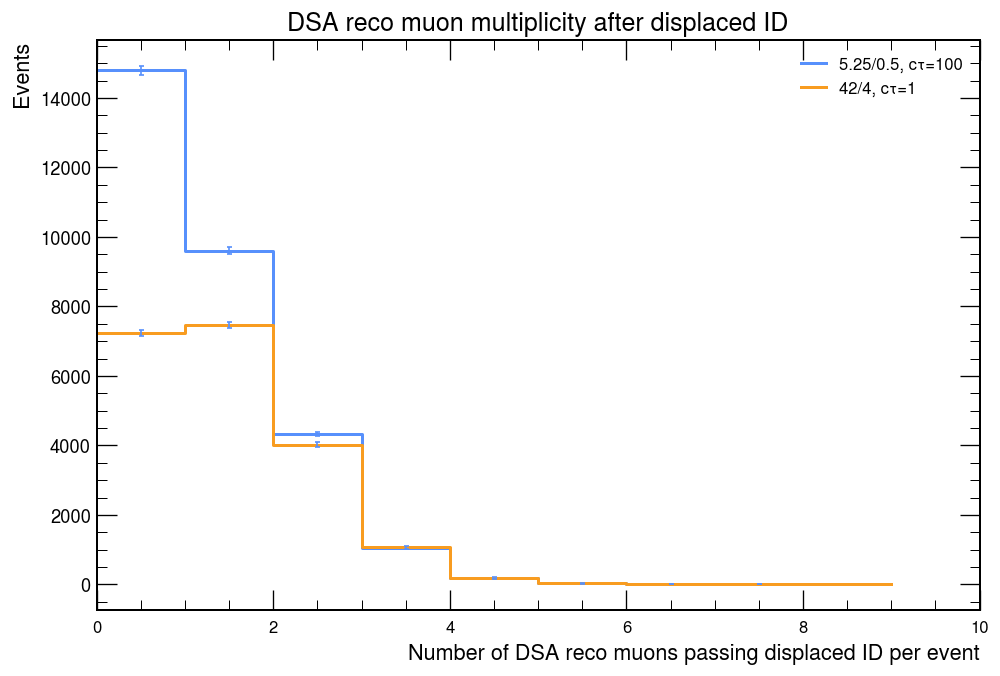

Saved: outputs/muonReco_dsaID_checks_twoPoints_presentable/plots/twoPoints_nDSAMuon_passDisplacedID_per_event.png
Saved: outputs/muonReco_dsaID_checks_twoPoints_presentable/plots/twoPoints_nDSAMuon_passDisplacedID_per_event.pdf


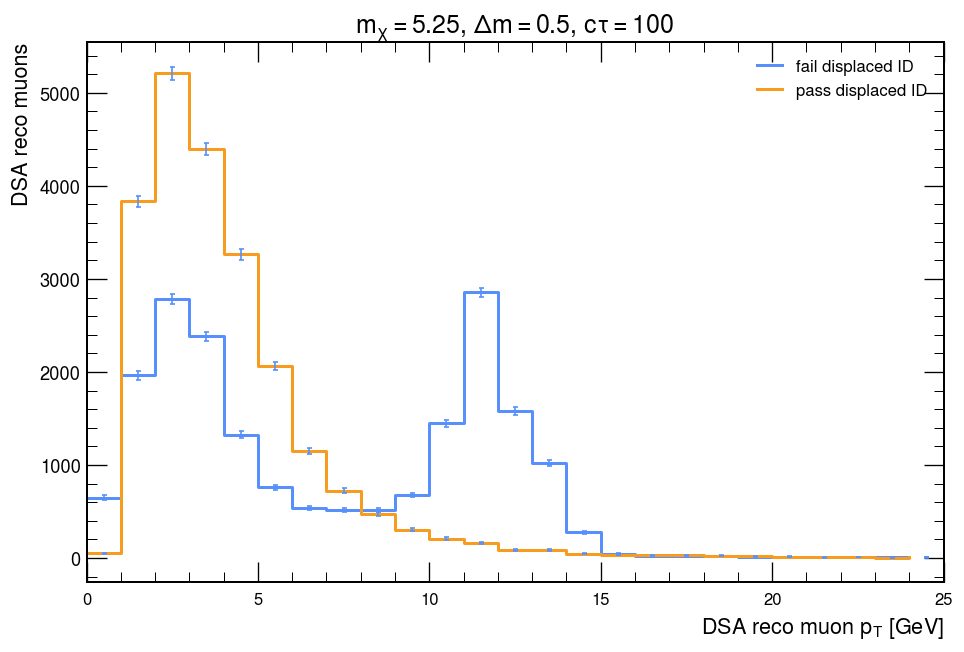

Saved: outputs/muonReco_dsaID_checks_twoPoints_presentable/plots/twoPoints_sig_2022EE_Mchi-5p25_dMchi-0p5_ctau-100_dsaMuon_pt_fail_vs_pass_displacedID.png
Saved: outputs/muonReco_dsaID_checks_twoPoints_presentable/plots/twoPoints_sig_2022EE_Mchi-5p25_dMchi-0p5_ctau-100_dsaMuon_pt_fail_vs_pass_displacedID.pdf


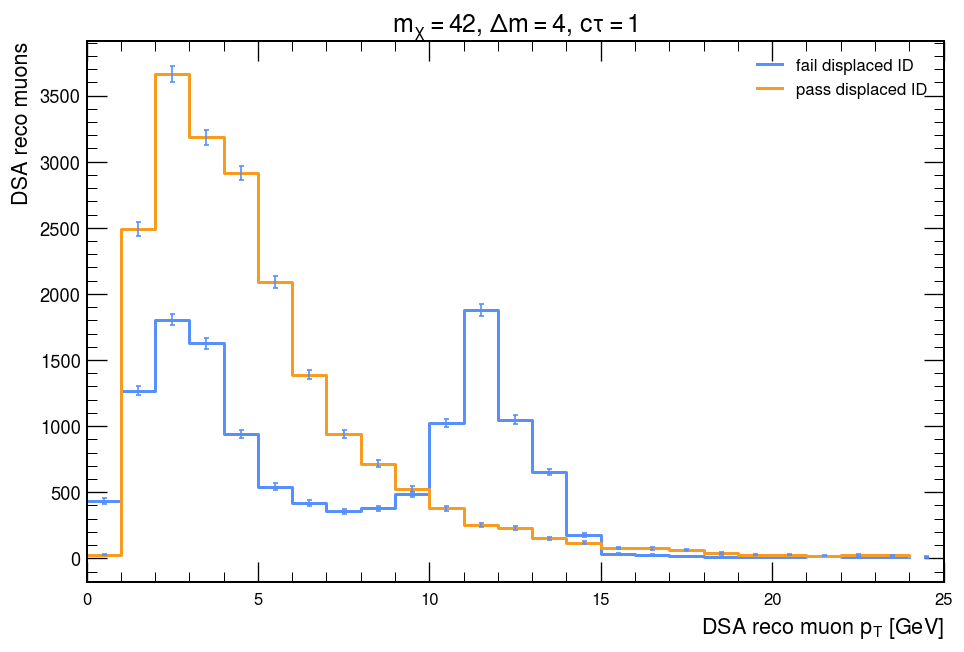

Saved: outputs/muonReco_dsaID_checks_twoPoints_presentable/plots/twoPoints_sig_2022EE_Mchi-42p0_dMchi-4p0_ctau-1_dsaMuon_pt_fail_vs_pass_displacedID.png
Saved: outputs/muonReco_dsaID_checks_twoPoints_presentable/plots/twoPoints_sig_2022EE_Mchi-42p0_dMchi-4p0_ctau-1_dsaMuon_pt_fail_vs_pass_displacedID.pdf
Saved pT histogram CSV: outputs/muonReco_dsaID_checks_twoPoints_presentable/csv/twoPoints_dsaMuon_pt_fail_vs_pass_displacedID_bins_presentable.csv


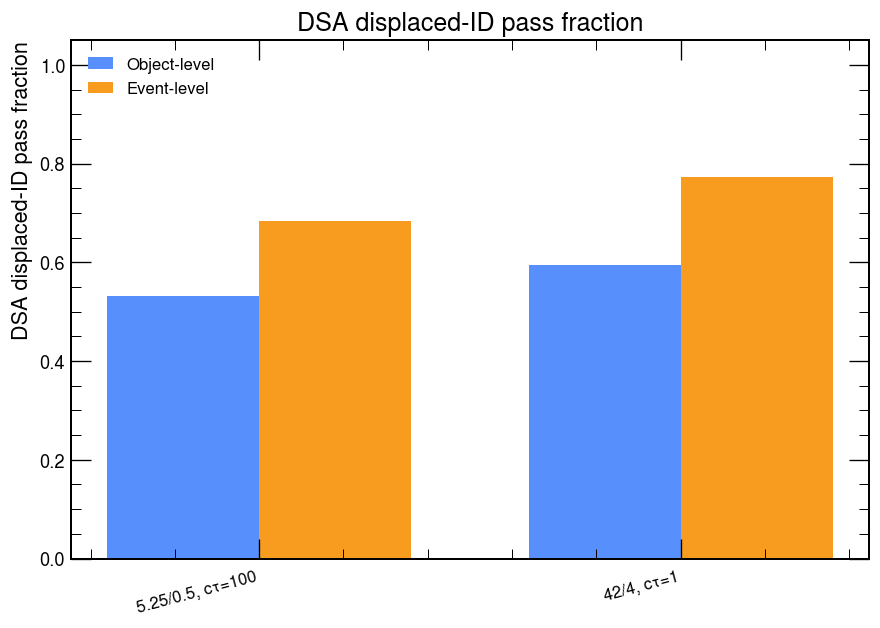

Saved: outputs/muonReco_dsaID_checks_twoPoints_presentable/plots/twoPoints_dsaID_object_event_passFraction.png
Saved: outputs/muonReco_dsaID_checks_twoPoints_presentable/plots/twoPoints_dsaID_object_event_passFraction.pdf


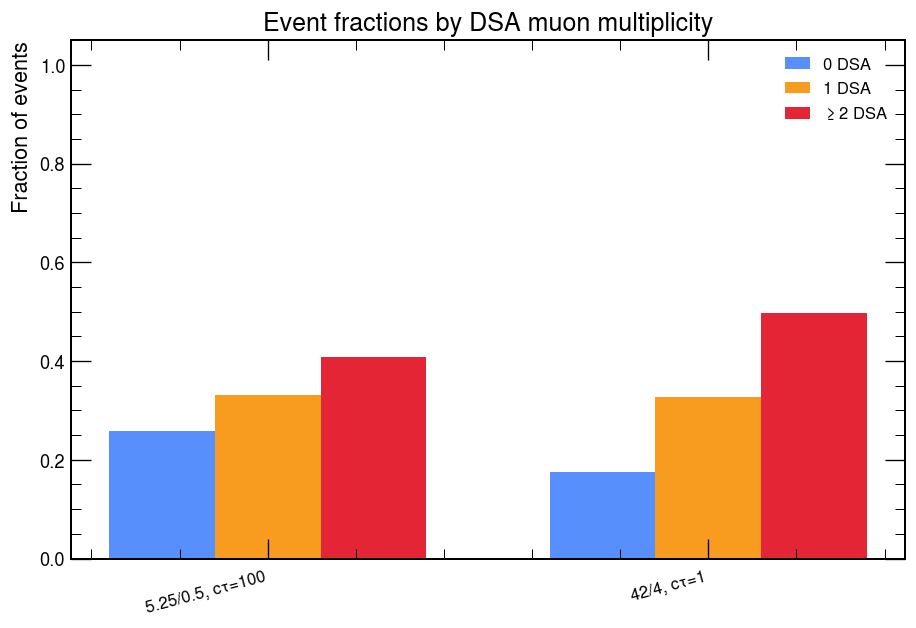

Saved: outputs/muonReco_dsaID_checks_twoPoints_presentable/plots/twoPoints_eventFractions_0_1_ge2_DSA.png
Saved: outputs/muonReco_dsaID_checks_twoPoints_presentable/plots/twoPoints_eventFractions_0_1_ge2_DSA.pdf


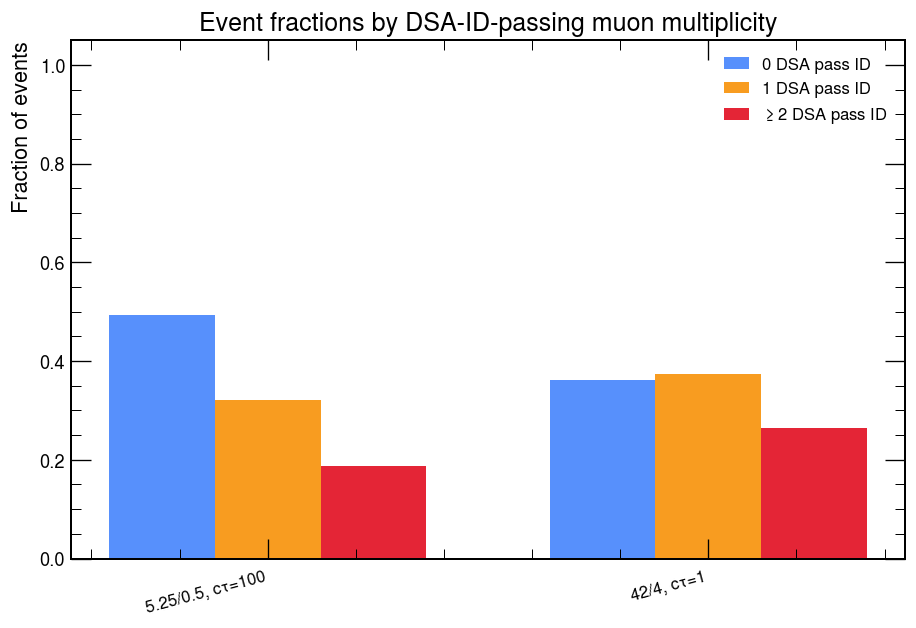

Saved: outputs/muonReco_dsaID_checks_twoPoints_presentable/plots/twoPoints_eventFractions_0_1_ge2_DSA_passDisplacedID.png
Saved: outputs/muonReco_dsaID_checks_twoPoints_presentable/plots/twoPoints_eventFractions_0_1_ge2_DSA_passDisplacedID.pdf

Done: two-point presentation-quality plots
Summary CSV: outputs/muonReco_dsaID_checks_twoPoints_presentable/csv/twoPoints_dsaID_summary_presentable.csv
pT CSV:      outputs/muonReco_dsaID_checks_twoPoints_presentable/csv/twoPoints_dsaMuon_pt_fail_vs_pass_displacedID_bins_presentable.csv
Plots:       outputs/muonReco_dsaID_checks_twoPoints_presentable/plots


In [8]:
# ============================================================
# Presentation-quality DSA reco diagnostics: TWO selected points only
#
# Points:
#   Mchi-5p25_dMchi-0p5_ctau-100
#   Mchi-42p0_dMchi-4p0_ctau-1
#
# Fixes the ctau-1 vs ctau-1000 substring bug by exact matching.
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import coffea.util as util

# Do not use hep.style.use("CMS") here; it makes these plots ugly/oversized.
try:
    import mplhep as hep
    HAS_MPLHEP = True
except Exception:
    HAS_MPLHEP = False

# -----------------------------
# Load histos if needed
# -----------------------------
if "histos" not in globals():
    coffea_file = "outputs/muonReco_dsaID_checks_allSamples_allEvents/muonReco_dsaID_checks_allSamples_allEvents.coffea"
    print(f"histos not found in memory. Loading: {coffea_file}")
    histos = util.load(coffea_file)

# -----------------------------
# Output directories
# -----------------------------
outdir = "outputs/muonReco_dsaID_checks_twoPoints_presentable"
plotdir = f"{outdir}/plots"
csvdir = f"{outdir}/csv"

os.makedirs(plotdir, exist_ok=True)
os.makedirs(csvdir, exist_ok=True)

# -----------------------------
# Plot style
# -----------------------------
plt.rcParams.update({
    "figure.figsize": (8, 5.5),
    "figure.dpi": 120,
    "savefig.dpi": 250,
    "font.size": 12,
    "axes.titlesize": 15,
    "axes.labelsize": 13,
    "xtick.labelsize": 10,
    "ytick.labelsize": 11,
    "legend.fontsize": 10,
    "axes.linewidth": 1.2,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
})

# -----------------------------
# Exact target samples
# -----------------------------
target_sample_names = [
    "sig_2022EE_Mchi-5p25_dMchi-0p5_ctau-100",
    "sig_2022EE_Mchi-42p0_dMchi-4p0_ctau-1",
]

pretty_label = {
    "sig_2022EE_Mchi-5p25_dMchi-0p5_ctau-100": r"$m_\chi=5.25$, $\Delta m=0.5$, $c\tau=100$",
    "sig_2022EE_Mchi-42p0_dMchi-4p0_ctau-1": r"$m_\chi=42$, $\Delta m=4$, $c\tau=1$",
}

short_label = {
    "sig_2022EE_Mchi-5p25_dMchi-0p5_ctau-100": "5.25/0.5, cτ=100",
    "sig_2022EE_Mchi-42p0_dMchi-4p0_ctau-1": "42/4, cτ=1",
}

# -----------------------------
# Helpers
# -----------------------------
def sanitize_name(x):
    return str(x).replace("/", "_").replace(" ", "_").replace(".", "p").replace("$", "")


def savefig(path):
    plt.tight_layout()
    plt.savefig(path, bbox_inches="tight")
    plt.savefig(path.replace(".png", ".pdf"), bbox_inches="tight")
    plt.show()
    print(f"Saved: {path}")
    print(f"Saved: {path.replace('.png', '.pdf')}")


def get_samp_axis(h):
    axis_names = [ax.name for ax in h.axes]
    if "samp" in axis_names:
        return "samp"
    if "sample" in axis_names:
        return "sample"
    raise RuntimeError(f"Could not find sample axis. Axes are: {axis_names}")


def get_values_edges_errors(h1d):
    values = np.asarray(h1d.values())
    variances = h1d.variances()

    if variances is not None:
        errors = np.sqrt(variances)
    else:
        errors = np.sqrt(values)

    errors = np.asarray(errors)
    errors = np.where(values > 0, errors, 0.0)

    edges = np.asarray(h1d.axes[0].edges)
    centers = 0.5 * (edges[:-1] + edges[1:])

    return values, errors, edges, centers


def plot_step_with_errors(h_s, label, max_x=None):
    values, errors, edges, centers = get_values_edges_errors(h_s)

    if max_x is not None:
        keep = edges[:-1] < max_x
        n_keep = np.sum(keep)

        values = values[:n_keep]
        errors = errors[:n_keep]
        centers = centers[:n_keep]
        edges = edges[:n_keep + 1]

    plt.step(edges[:-1], values, where="post", label=label, linewidth=1.8)

    nonzero = values > 0
    if np.any(nonzero):
        plt.errorbar(
            centers[nonzero],
            values[nonzero],
            yerr=errors[nonzero],
            fmt="none",
            linewidth=1.0,
            capsize=1.5,
        )


# -----------------------------
# Required histogram checks
# -----------------------------
required_hists = [
    "muon_reco_counts",
    "n_dsa_muons",
    "n_dsa_muons_pass_id",
    "dsa_muon_pt_pass_id",
]

missing = [h for h in required_hists if h not in histos]
if missing:
    raise RuntimeError(f"Missing required histograms: {missing}")

counts_h = histos["muon_reco_counts"]
counts_samp_axis = get_samp_axis(counts_h)
quantity_axis = "quantity"

available_samples = [str(s) for s in list(counts_h.axes[counts_samp_axis])]

print("=" * 100)
print("Available selected sample check")
print("=" * 100)

selected_pairs = []

for target in target_sample_names:
    if target not in available_samples:
        print(f"[ERROR] Target not found exactly: {target}")
        close = [s for s in available_samples if target.replace("sig_2022EE_", "") in s]
        if close:
            print("Close matches:")
            for c in close:
                print(f"  {c}")
        raise RuntimeError(f"Exact sample not found: {target}")

    selected_pairs.append((target, target))
    print(f"{target:55s} -> {target}")

# -----------------------------
# Build summary table
# -----------------------------
summary_rows = []

for key, samp in selected_pairs:
    vals = {}

    for q in counts_h.axes[quantity_axis]:
        vals[q] = float(counts_h[{counts_samp_axis: samp, quantity_axis: q}].value)

    n_events = vals.get("n_events", 0.0)

    n_dsa = vals.get("n_dsa_reco_muons", 0.0)
    n_dsa_pass = vals.get("n_dsa_reco_muons_pass_id", 0.0)

    n_events_with_dsa = vals.get("n_events_with_dsa", 0.0)
    n_events_with_dsa_pass_id = vals.get("n_events_with_dsa_pass_id", 0.0)

    row = {
        "sample": key,
        "label": short_label[key],
        "n_events": n_events,

        "n_dsa_reco_muons": n_dsa,
        "n_dsa_reco_muons_pass_id": n_dsa_pass,
        "object_level_dsa_id_pass_fraction": n_dsa_pass / n_dsa if n_dsa > 0 else np.nan,

        "n_events_with_dsa": n_events_with_dsa,
        "n_events_with_dsa_pass_id": n_events_with_dsa_pass_id,
        "event_level_dsa_id_pass_fraction": n_events_with_dsa_pass_id / n_events_with_dsa if n_events_with_dsa > 0 else np.nan,

        "n_events_0_dsa": vals.get("n_events_0_dsa", np.nan),
        "n_events_1_dsa": vals.get("n_events_1_dsa", np.nan),
        "n_events_ge2_dsa": vals.get("n_events_ge2_dsa", np.nan),

        "n_events_0_dsa_pass_id": vals.get("n_events_0_dsa_pass_id", np.nan),
        "n_events_1_dsa_pass_id": vals.get("n_events_1_dsa_pass_id", np.nan),
        "n_events_ge2_dsa_pass_id": vals.get("n_events_ge2_dsa_pass_id", np.nan),

        "frac_events_0_dsa": vals.get("n_events_0_dsa", 0.0) / n_events if n_events > 0 else np.nan,
        "frac_events_1_dsa": vals.get("n_events_1_dsa", 0.0) / n_events if n_events > 0 else np.nan,
        "frac_events_ge2_dsa": vals.get("n_events_ge2_dsa", 0.0) / n_events if n_events > 0 else np.nan,

        "frac_events_0_dsa_pass_id": vals.get("n_events_0_dsa_pass_id", 0.0) / n_events if n_events > 0 else np.nan,
        "frac_events_1_dsa_pass_id": vals.get("n_events_1_dsa_pass_id", 0.0) / n_events if n_events > 0 else np.nan,
        "frac_events_ge2_dsa_pass_id": vals.get("n_events_ge2_dsa_pass_id", 0.0) / n_events if n_events > 0 else np.nan,
    }

    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)

summary_csv = f"{csvdir}/twoPoints_dsaID_summary_presentable.csv"
summary_df.to_csv(summary_csv, index=False)

print("\n" + "=" * 100)
print("Two-point DSA-ID summary")
print("=" * 100)

display_cols = [
    "label",
    "n_events",
    "n_dsa_reco_muons",
    "n_dsa_reco_muons_pass_id",
    "object_level_dsa_id_pass_fraction",
    "n_events_with_dsa",
    "n_events_with_dsa_pass_id",
    "event_level_dsa_id_pass_fraction",
    "frac_events_0_dsa",
    "frac_events_1_dsa",
    "frac_events_ge2_dsa",
    "frac_events_0_dsa_pass_id",
    "frac_events_1_dsa_pass_id",
    "frac_events_ge2_dsa_pass_id",
]

print(summary_df[display_cols].to_string(index=False))
print(f"\nSaved summary CSV: {summary_csv}")

# ============================================================
# Plot A: nDSAMuon per event
# ============================================================
h_n_dsa = histos["n_dsa_muons"]
h_n_dsa_samp_axis = get_samp_axis(h_n_dsa)

plt.figure(figsize=(8.5, 5.8))

for key, samp in selected_pairs:
    h_s = h_n_dsa[{h_n_dsa_samp_axis: samp}]
    plot_step_with_errors(h_s, label=short_label[key], max_x=10)

plt.xlim(0, 10)
plt.xlabel("Number of DSA reco muons per event")
plt.ylabel("Events")
plt.title("DSA reco muon multiplicity")
plt.legend(frameon=False, loc="upper right")
savefig(f"{plotdir}/twoPoints_nDSAMuon_per_event.png")

# ============================================================
# Plot B: nDSAMuon passing displaced ID per event
# ============================================================
h_n_dsa_pass = histos["n_dsa_muons_pass_id"]
h_n_dsa_pass_samp_axis = get_samp_axis(h_n_dsa_pass)

plt.figure(figsize=(8.5, 5.8))

for key, samp in selected_pairs:
    h_s = h_n_dsa_pass[{h_n_dsa_pass_samp_axis: samp}]
    plot_step_with_errors(h_s, label=short_label[key], max_x=10)

plt.xlim(0, 10)
plt.xlabel("Number of DSA reco muons passing displaced ID per event")
plt.ylabel("Events")
plt.title("DSA reco muon multiplicity after displaced ID")
plt.legend(frameon=False, loc="upper right")
savefig(f"{plotdir}/twoPoints_nDSAMuon_passDisplacedID_per_event.png")

# ============================================================
# Plot C: DSA pT fail/pass ID, one plot per sample
# x-axis zoom: 0 to 25 GeV
# ============================================================
h_pt = histos["dsa_muon_pt_pass_id"]
h_pt_samp_axis = get_samp_axis(h_pt)

pt_rows = []

for key, samp in selected_pairs:
    safe_key = sanitize_name(key)

    h_fail = h_pt[{h_pt_samp_axis: samp, "pass_id": 0}]
    h_pass = h_pt[{h_pt_samp_axis: samp, "pass_id": 1}]

    plt.figure(figsize=(8.2, 5.6))

    plot_step_with_errors(h_fail, label="fail displaced ID", max_x=25)
    plot_step_with_errors(h_pass, label="pass displaced ID", max_x=25)

    plt.xlim(0, 25)
    plt.xlabel("DSA reco muon $p_T$ [GeV]")
    plt.ylabel("DSA reco muons")
    plt.title(pretty_label[key])
    plt.legend(frameon=False, loc="upper right")
    savefig(f"{plotdir}/twoPoints_{safe_key}_dsaMuon_pt_fail_vs_pass_displacedID.png")

    for pass_id, h_s in [(0, h_fail), (1, h_pass)]:
        values, errors, edges, centers = get_values_edges_errors(h_s)

        for i in range(len(values)):
            pt_rows.append({
                "sample": key,
                "label": short_label[key],
                "pass_id": pass_id,
                "pass_label": "pass displaced ID" if pass_id == 1 else "fail displaced ID",
                "bin": i,
                "pt_low": edges[i],
                "pt_high": edges[i + 1],
                "pt_center": centers[i],
                "value": values[i],
                "error": errors[i],
            })

pt_df = pd.DataFrame(pt_rows)
pt_csv = f"{csvdir}/twoPoints_dsaMuon_pt_fail_vs_pass_displacedID_bins_presentable.csv"
pt_df.to_csv(pt_csv, index=False)
print(f"Saved pT histogram CSV: {pt_csv}")

# ============================================================
# Plot D: object/event-level ID pass fractions
# ============================================================
x = np.arange(len(summary_df))
width = 0.36

plt.figure(figsize=(7.5, 5.4))

plt.bar(
    x - width / 2,
    summary_df["object_level_dsa_id_pass_fraction"].values,
    width=width,
    label="Object-level",
)

plt.bar(
    x + width / 2,
    summary_df["event_level_dsa_id_pass_fraction"].values,
    width=width,
    label="Event-level",
)

plt.xticks(x, summary_df["label"].values, rotation=15, ha="right")
plt.ylim(0, 1.05)
plt.ylabel("DSA displaced-ID pass fraction")
plt.title("DSA displaced-ID pass fraction")
plt.legend(frameon=False, loc="upper left")
savefig(f"{plotdir}/twoPoints_dsaID_object_event_passFraction.png")

# ============================================================
# Plot E: event fractions by DSA multiplicity
# ============================================================
x = np.arange(len(summary_df))
width = 0.24

plt.figure(figsize=(7.8, 5.4))

plt.bar(x - width, summary_df["frac_events_0_dsa"].values, width=width, label="0 DSA")
plt.bar(x, summary_df["frac_events_1_dsa"].values, width=width, label="1 DSA")
plt.bar(x + width, summary_df["frac_events_ge2_dsa"].values, width=width, label=r"$\geq 2$ DSA")

plt.xticks(x, summary_df["label"].values, rotation=15, ha="right")
plt.ylim(0, 1.05)
plt.ylabel("Fraction of events")
plt.title("Event fractions by DSA muon multiplicity")
plt.legend(frameon=False, loc="upper right")
savefig(f"{plotdir}/twoPoints_eventFractions_0_1_ge2_DSA.png")

# ============================================================
# Plot F: event fractions by DSA-ID multiplicity
# ============================================================
x = np.arange(len(summary_df))
width = 0.24

plt.figure(figsize=(7.8, 5.4))

plt.bar(x - width, summary_df["frac_events_0_dsa_pass_id"].values, width=width, label="0 DSA pass ID")
plt.bar(x, summary_df["frac_events_1_dsa_pass_id"].values, width=width, label="1 DSA pass ID")
plt.bar(x + width, summary_df["frac_events_ge2_dsa_pass_id"].values, width=width, label=r"$\geq 2$ DSA pass ID")

plt.xticks(x, summary_df["label"].values, rotation=15, ha="right")
plt.ylim(0, 1.05)
plt.ylabel("Fraction of events")
plt.title("Event fractions by DSA-ID-passing muon multiplicity")
plt.legend(frameon=False, loc="upper right")
savefig(f"{plotdir}/twoPoints_eventFractions_0_1_ge2_DSA_passDisplacedID.png")

print("\n" + "=" * 100)
print("Done: two-point presentation-quality plots")
print("=" * 100)
print(f"Summary CSV: {summary_csv}")
print(f"pT CSV:      {pt_csv}")
print(f"Plots:       {plotdir}")
print("=" * 100)